In [1]:
#Load Libraries
library(Seurat)
library(SeuratWrappers)
library(glmGamPoi)
library(biomaRt)
library(data.table)
library(dplyr)
library(ggplot2)
library(patchwork)
library(Matrix)
library(future)

#Set Options
options(future.globals.maxSize = 400000 * 1024^2) #for 400GB max size
plan("sequential") #, workers = 4)

#Set working directory
setwd("/storage1/fs1/jmillman/Active/DigitalTwin")

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.3 but the current
version is 1.7.4; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following object is masked from ‘package:biomaRt’:

    select


The following object is masked from ‘package:glmGamPoi’:

    vars


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘ggplot2’


The following object is masked from ‘package:glmGamPoi’:

    vars




# Preprocess RNA Datasets

## Cao et al

In [2]:
#Load RNA data
counts <- readRDS("rawdata/RNA/fetal/Cao_fetal/Pancreas_gene_count.RDS")
cell.meta <- readRDS("rawdata/RNA/fetal/Cao_fetal/df_cell.RDS")
gene.meta <- readRDS("rawdata/RNA/fetal/Cao_fetal/df_gene.RDS")

gene.meta$gene_short_name <- as.factor(gene.meta$gene_short_name)
rownames(counts) <- gene.meta$gene_short_name
rownames(counts) <- make.unique(rownames(counts))
rownames(cell.meta) <- cell.meta$sample

# estimated fetal age in days available
#note: total number of embryo samples = 9

#Create Seurat object
cao.rna <- CreateSeuratObject(counts = counts, project = "Cao", meta.data = cell.meta, min.cells = 10, min.features = 200)
Idents(cao.rna) <- 'Fetus_id'

#Save
saveRDS(cao.rna, file='checkpoints/Fetal/Cao_RNA.rds')
rm(counts,cell.meta,gene.meta)

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”


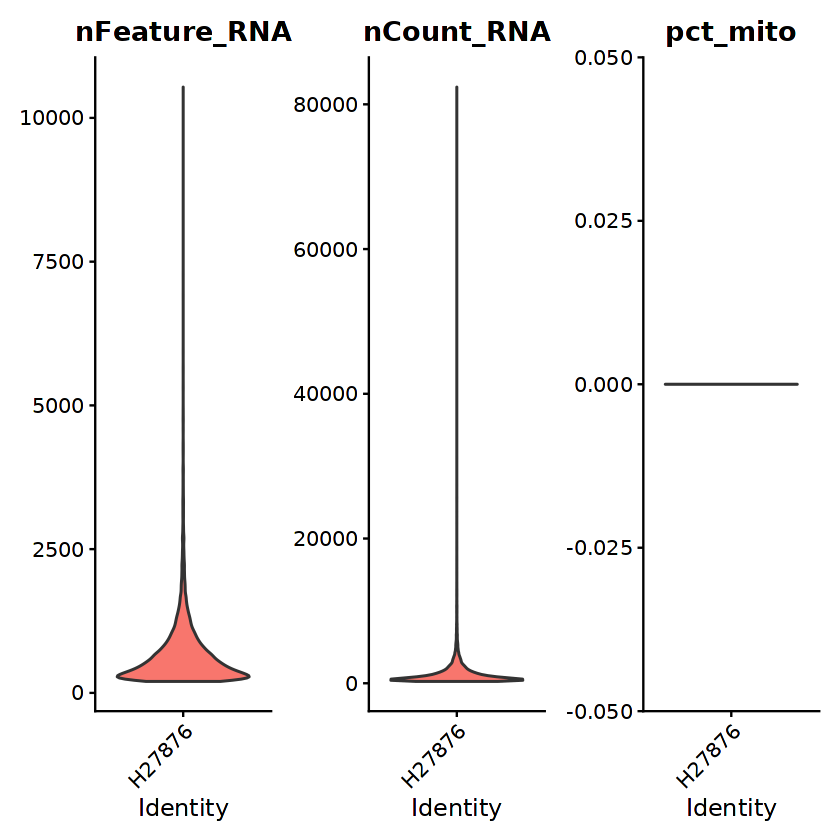

An object of class Seurat 
27957 features across 17794 samples within 1 assay 
Active assay: RNA (27957 features, 0 variable features)
 1 layer present: counts

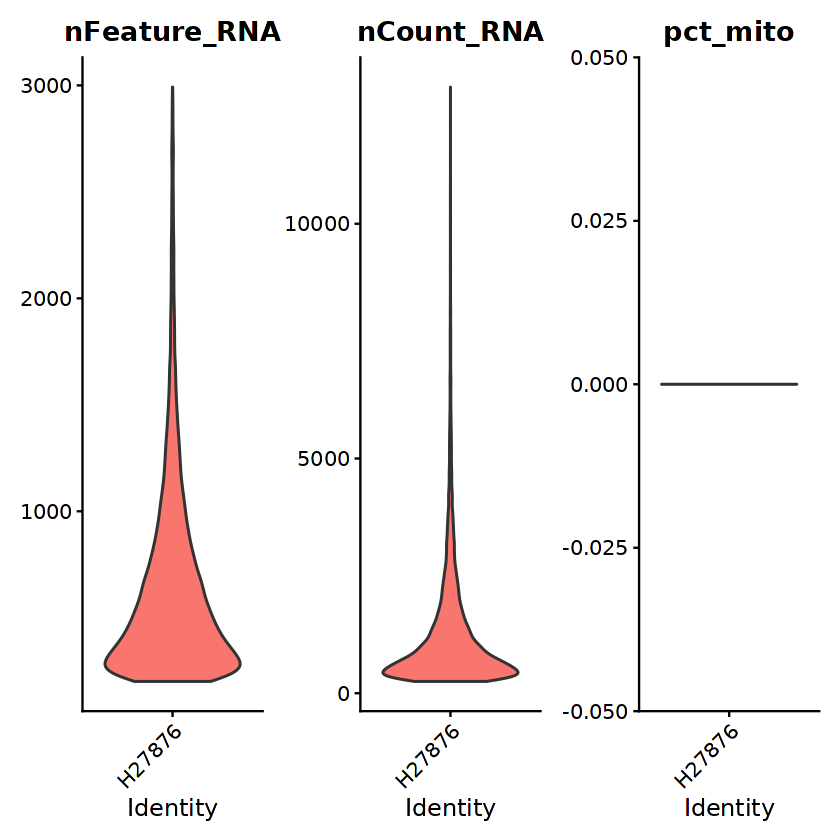

In [3]:
H27876 <- subset(cao.rna, idents = 'H27876')

#Add metadata
H27876 = RenameCells(H27876, add.cell.id = 'H27876')
H27876$modality = 'expression' 
H27876$dataset = 'cao_H27876'
H27876$pcw = '16'
H27876$cellsource = 'fetal'
H27876$gender = 'male'

#QC filtering
H27876[['pct_mito']] = PercentageFeatureSet(H27876, pattern = '^MT-')
VlnPlot(H27876, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

H27876 <- subset(H27876, subset = nFeature_RNA > 200 & nFeature_RNA < 3000 & pct_mito < 20)
VlnPlot(H27876, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(H27876)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
H27876 = subset(H27876, features = anti_mt_genes)

H27876

#Save Checkpoint
saveRDS(H27876, file='checkpoints/Fetal/RNA_datasets/cao_H27876.rds')
rm(H27876)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”


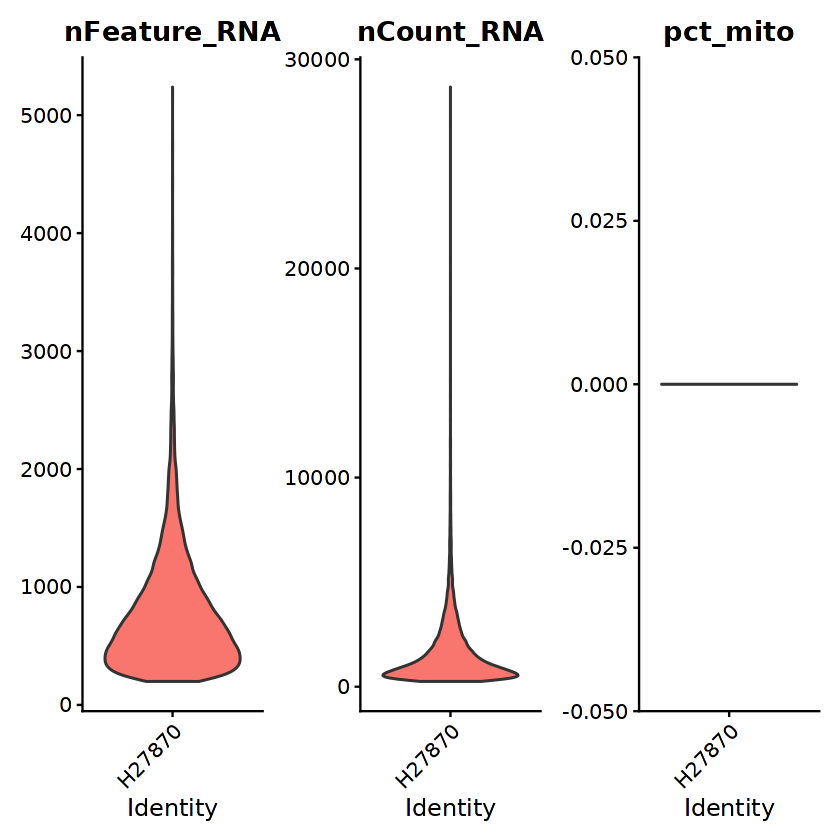

An object of class Seurat 
27957 features across 30667 samples within 1 assay 
Active assay: RNA (27957 features, 0 variable features)
 1 layer present: counts

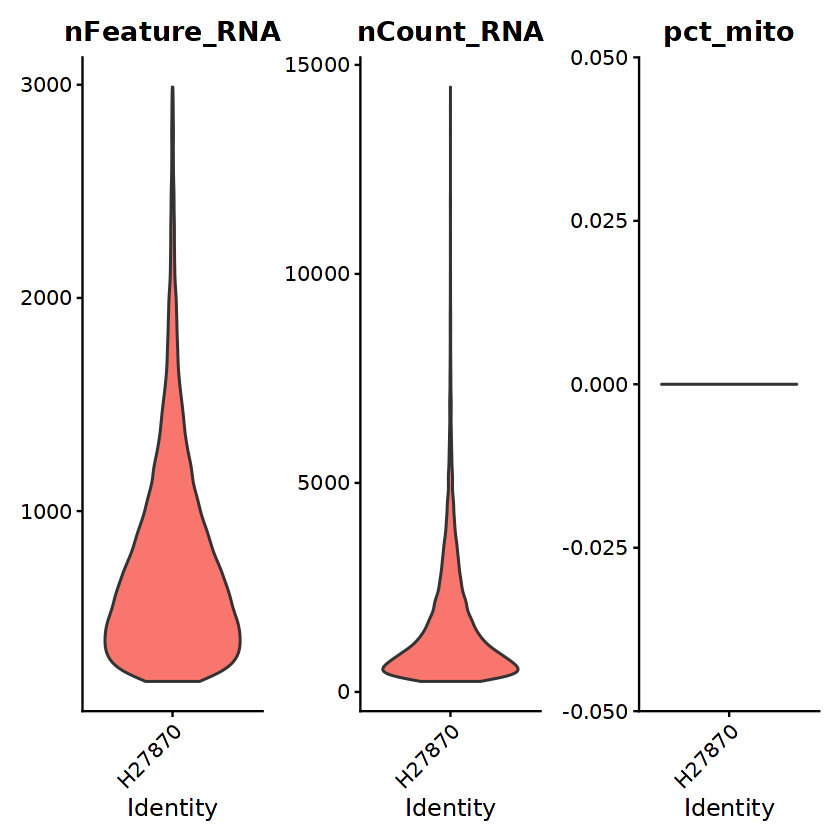

In [4]:
H27870 <- subset(cao.rna, idents = 'H27870')

#Add metadata
H27870 = RenameCells(H27870, add.cell.id = 'H27870')
H27870$modality = 'expression' 
H27870$dataset = 'cao_H27870'
H27870$pcw = '15'
H27870$cellsource = 'fetal'
H27870$gender = 'female'

#QC filtering
H27870[['pct_mito']] = PercentageFeatureSet(H27870, pattern = '^MT-')
VlnPlot(H27870, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

H27870 <- subset(H27870, subset = nFeature_RNA > 200 & nFeature_RNA < 3000 & pct_mito < 20)
VlnPlot(H27870, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(H27870)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
H27876 = subset(H27870, features = anti_mt_genes)

H27870

#Save Checkpoint
saveRDS(H27870, file='checkpoints/Fetal/RNA_datasets/cao_H27870.rds')
rm(H27870)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”


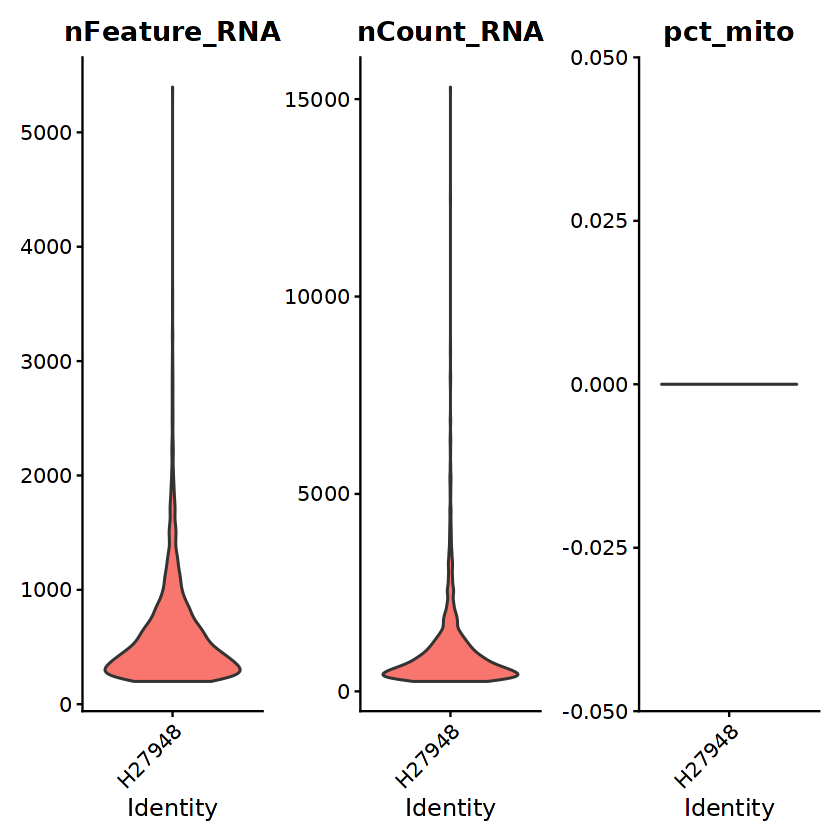

An object of class Seurat 
27957 features across 2812 samples within 1 assay 
Active assay: RNA (27957 features, 0 variable features)
 1 layer present: counts

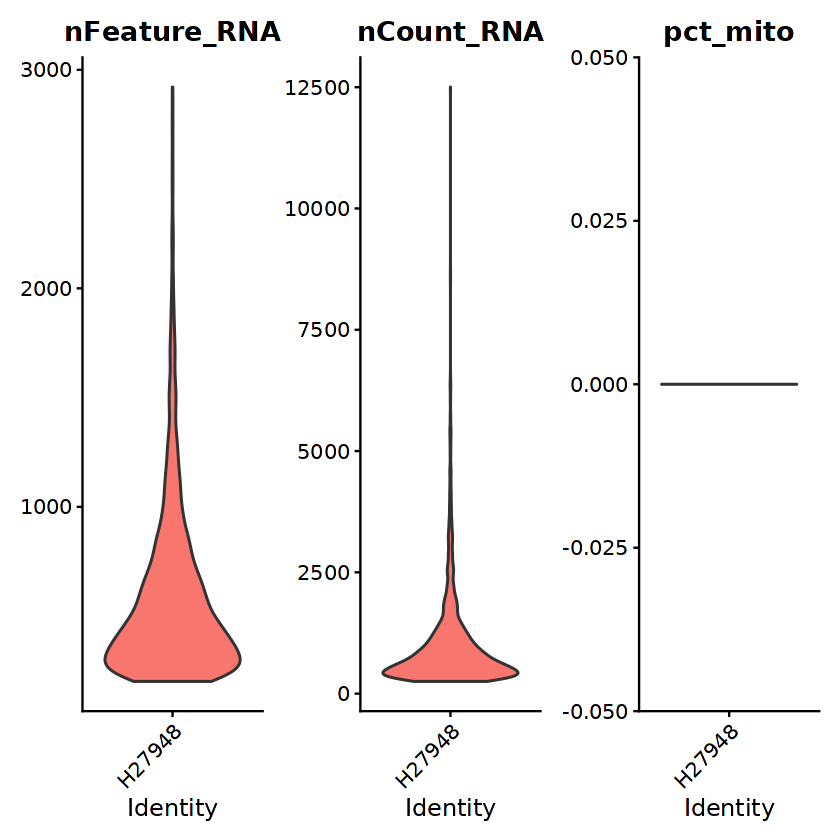

In [5]:
H27948 <- subset(cao.rna, idents = 'H27948')

#Add metadata
H27948 = RenameCells(H27948, add.cell.id = 'H27948')
H27948$modality = 'expression' 
H27948$dataset = 'cao_H27948'
H27948$pcw = '16'
H27948$cellsource = 'fetal'
H27948$gender = 'female'

#QC filtering
H27948[['pct_mito']] = PercentageFeatureSet(H27948, pattern = '^MT-')
VlnPlot(H27948, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

H27948 <- subset(H27948, subset = nFeature_RNA > 200 & nFeature_RNA < 3000 & pct_mito < 20)
VlnPlot(H27948, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(H27948)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
H27948 = subset(H27948, features = anti_mt_genes)

H27948

#Save Checkpoint
saveRDS(H27948, file='checkpoints/Fetal/RNA_datasets/cao_H27948.rds')
rm(H27948)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”


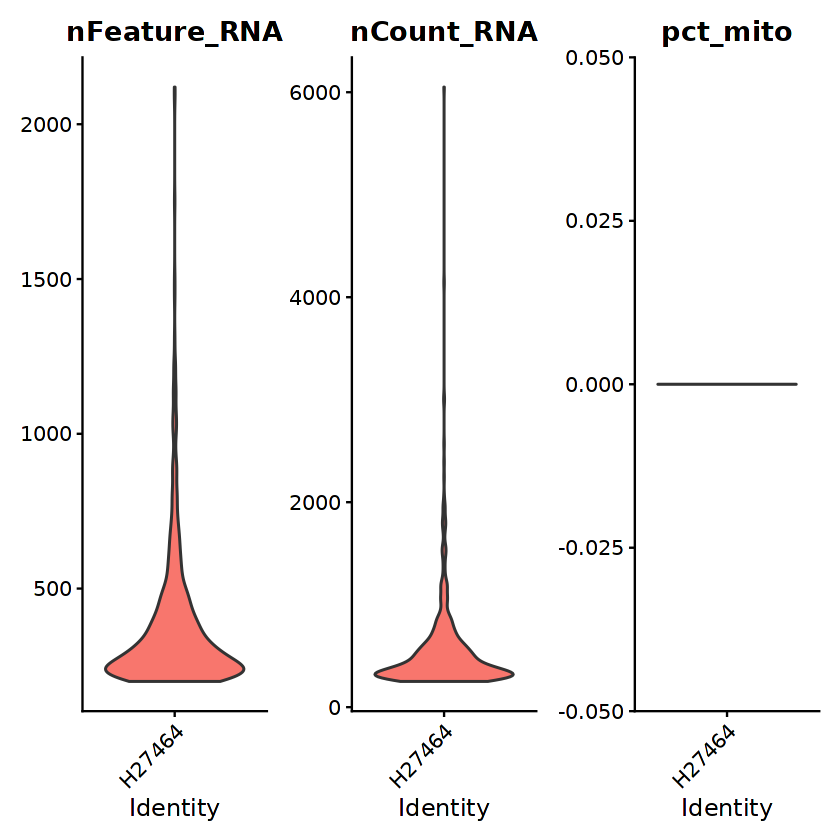

An object of class Seurat 
27957 features across 769 samples within 1 assay 
Active assay: RNA (27957 features, 0 variable features)
 1 layer present: counts

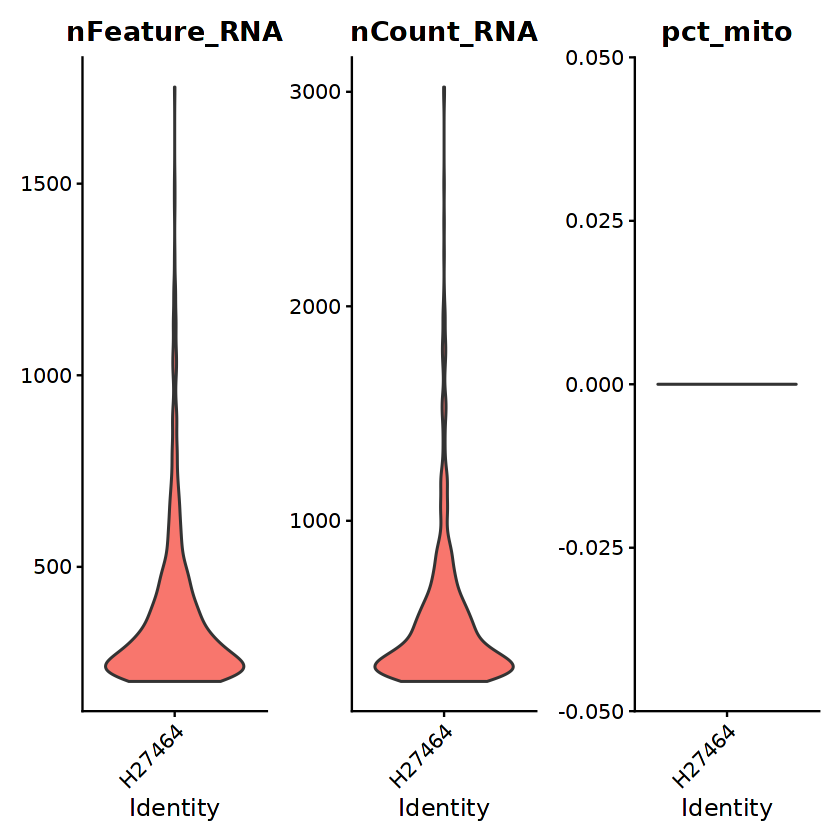

In [6]:
H27464 <- subset(cao.rna, idents = 'H27464')

#Add metadata
H27464 = RenameCells(H27464, add.cell.id = 'H27464')
H27464$modality = 'expression' 
H27464$dataset = 'cao_H27464'
H27464$pcw = '17'
H27464$cellsource = 'fetal'
H27464$gender = 'male'

#QC filtering
H27464[['pct_mito']] = PercentageFeatureSet(H27464, pattern = '^MT-')
VlnPlot(H27464, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

H27464 <- subset(H27464, subset = nFeature_RNA > 200 & nFeature_RNA < 2000 & pct_mito < 20)
VlnPlot(H27464, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(H27464)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
H27464 = subset(H27464, features = anti_mt_genes)

H27464

#Save Checkpoint
saveRDS(H27464, file='checkpoints/Fetal/RNA_datasets/cao_H27464.rds')
rm(H27464)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”


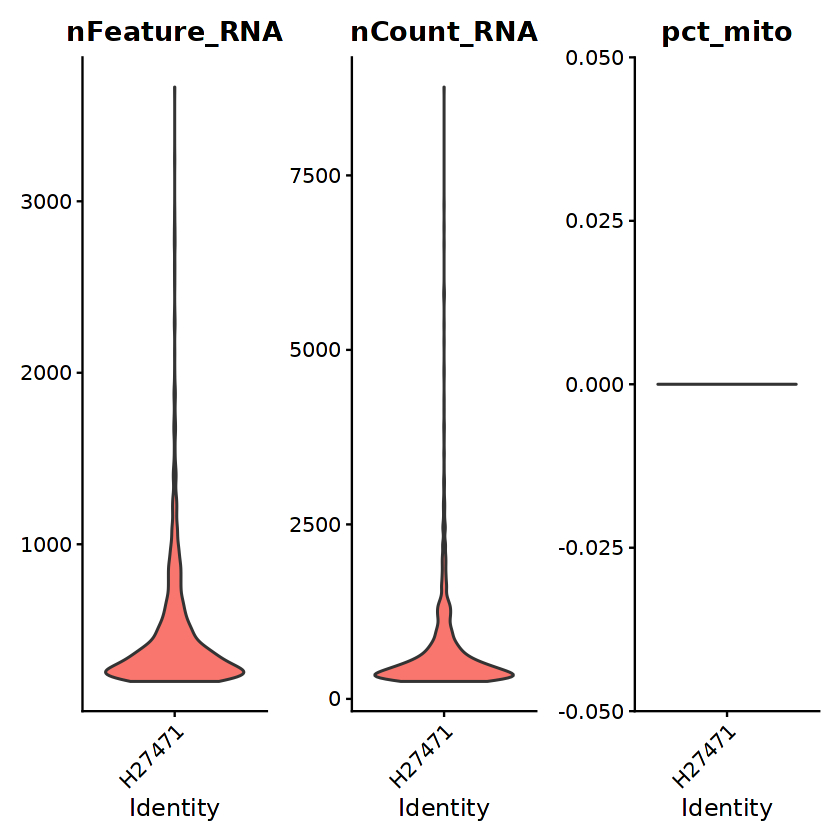

An object of class Seurat 
27957 features across 1629 samples within 1 assay 
Active assay: RNA (27957 features, 0 variable features)
 1 layer present: counts

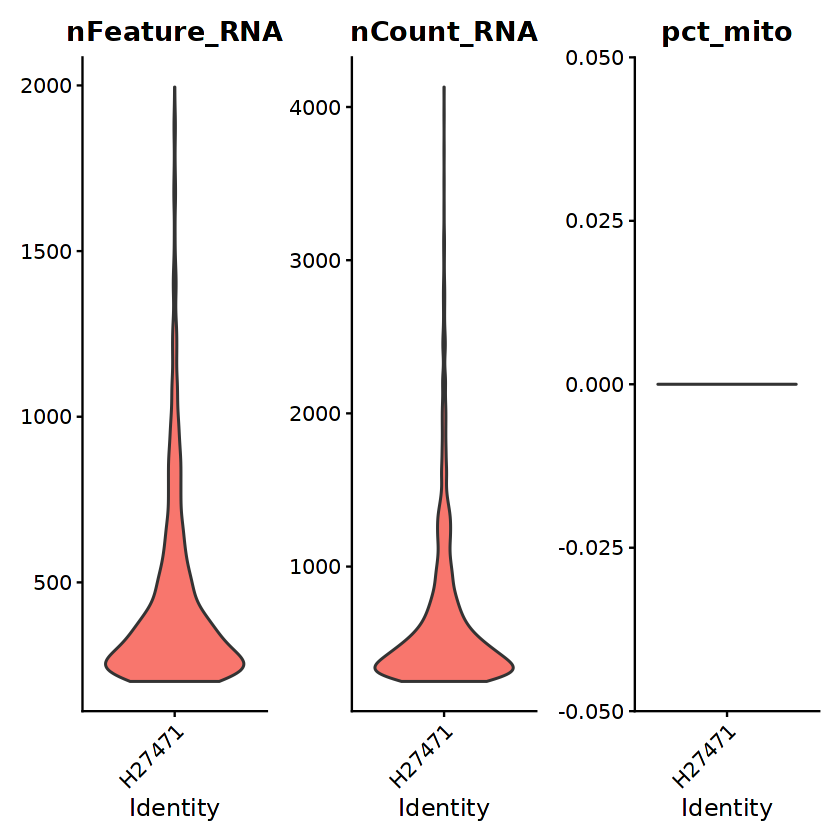

In [7]:
H27471 <- subset(cao.rna, idents = 'H27471')

#Add metadata
H27471 = RenameCells(H27471, add.cell.id = 'H27471')
H27471$modality = 'expression' 
H27471$dataset = 'cao_H27471'
H27471$pcw = '15'
H27471$cellsource = 'fetal'
H27471$gender = 'female'

#QC filtering
H27471[['pct_mito']] = PercentageFeatureSet(H27471, pattern = '^MT-')
VlnPlot(H27471, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

H27471 <- subset(H27471, subset = nFeature_RNA > 200 & nFeature_RNA < 2000 & pct_mito < 20)
VlnPlot(H27471, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(H27471)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
H27471 = subset(H27471, features = anti_mt_genes)

H27471

#Save Checkpoint
saveRDS(H27471, file='checkpoints/Fetal/RNA_datasets/cao_H27471.rds')
rm(H27471)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”


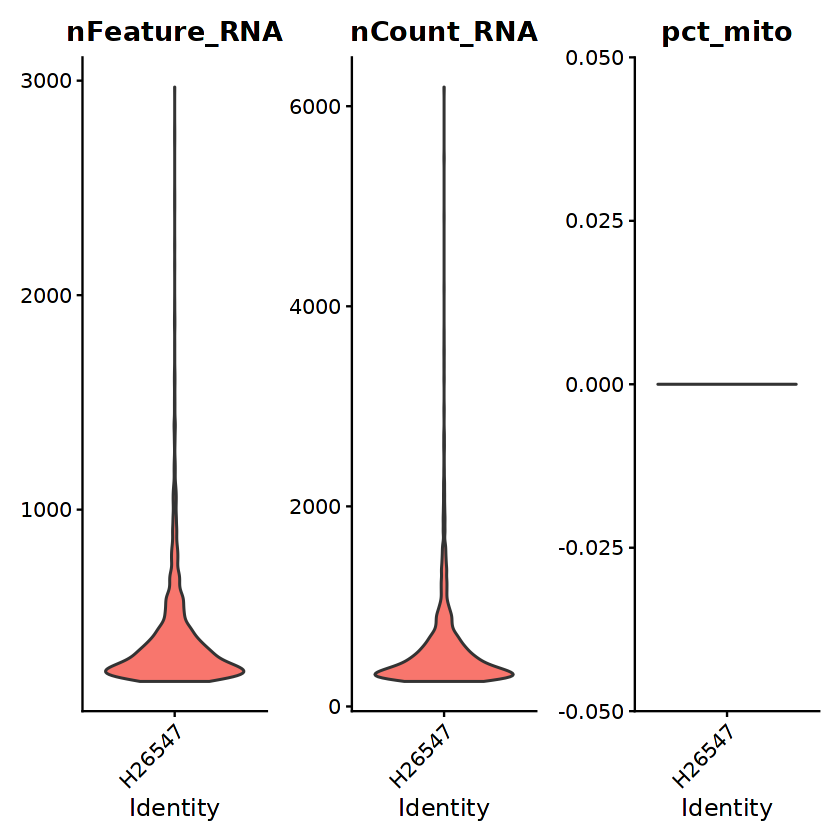

An object of class Seurat 
27957 features across 3051 samples within 1 assay 
Active assay: RNA (27957 features, 0 variable features)
 1 layer present: counts

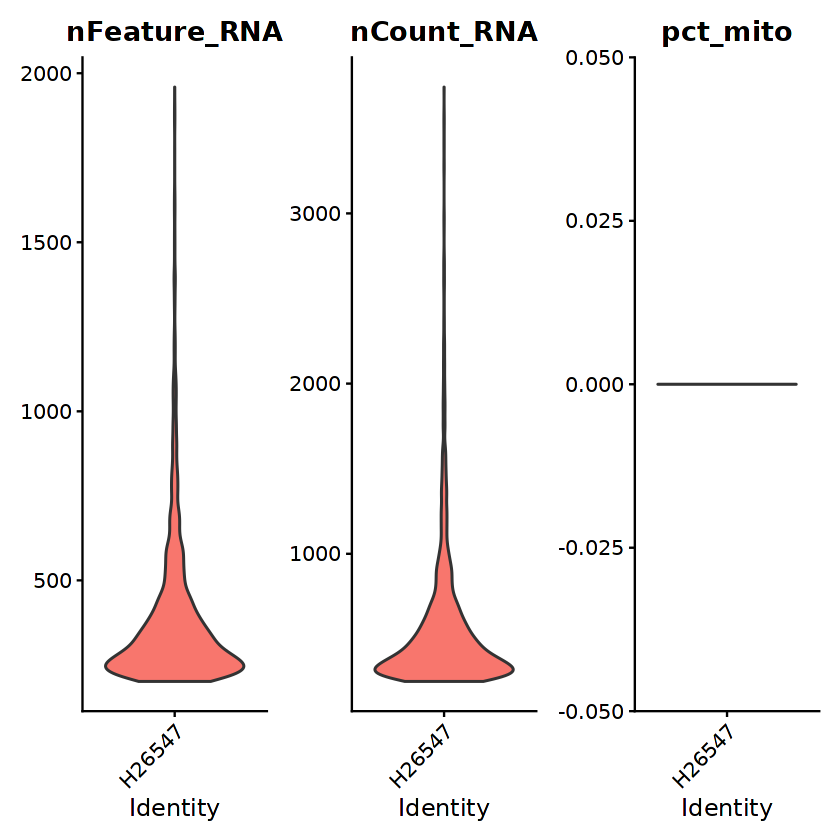

In [8]:
H26547 <- subset(cao.rna, idents = 'H26547')

#Add metadata
H26547 = RenameCells(H26547, add.cell.id = 'H26547')
H26547$modality = 'expression' 
H26547$dataset = 'cao_H26547'
H26547$pcw = '16'
H26547$cellsource = 'fetal'
H26547$gender = 'female'

#QC filtering
H26547[['pct_mito']] = PercentageFeatureSet(H26547, pattern = '^MT-')
VlnPlot(H26547, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

H26547 <- subset(H26547, subset = nFeature_RNA > 200 & nFeature_RNA < 2000 & pct_mito < 20)
VlnPlot(H26547, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(H26547)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
H26547 = subset(H26547, features = anti_mt_genes)

H26547

#Save Checkpoint
saveRDS(H26547, file='checkpoints/Fetal/RNA_datasets/cao_H26547.rds')
rm(H26547)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”


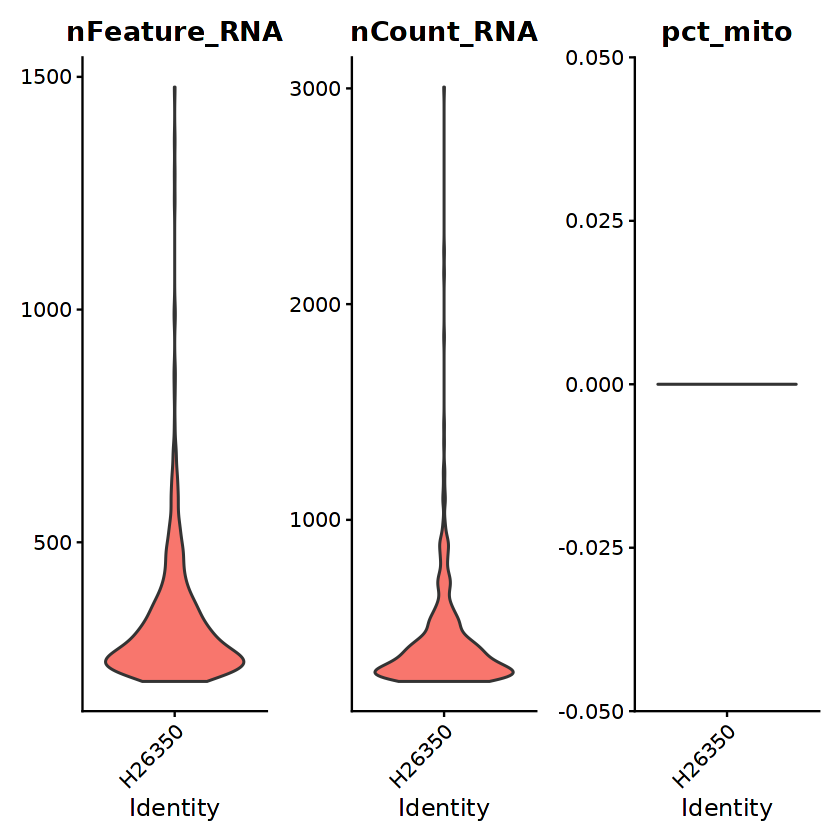

An object of class Seurat 
27957 features across 550 samples within 1 assay 
Active assay: RNA (27957 features, 0 variable features)
 1 layer present: counts

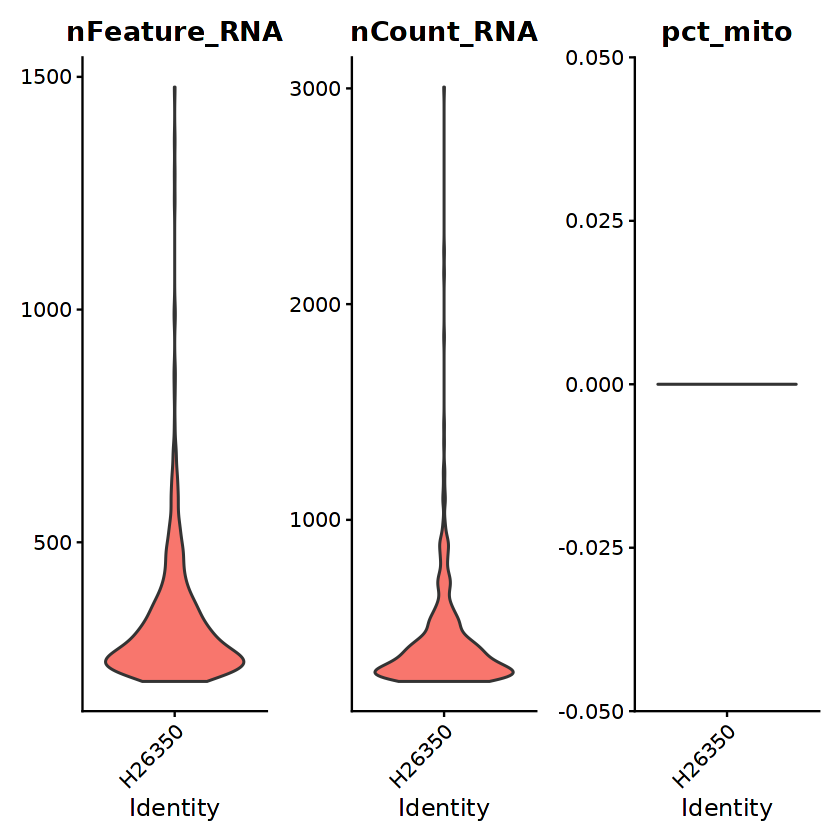

In [9]:
H26350 <- subset(cao.rna, idents = 'H26350')

#Add metadata
H26350 = RenameCells(H26350, add.cell.id = 'H26350')
H26350$modality = 'expression' 
H26350$dataset = 'cao_H26350'
H26350$pcw = '17'
H26350$cellsource = 'fetal'
H26350$gender = 'female'

#QC filtering
H26350[['pct_mito']] = PercentageFeatureSet(H26350, pattern = '^MT-')
VlnPlot(H26350, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

H26350 <- subset(H26350, subset = nFeature_RNA > 200 & nFeature_RNA < 2000 & pct_mito < 20)
VlnPlot(H26350, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(H26350)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
H26350 = subset(H26350, features = anti_mt_genes)

H26350

#Save Checkpoint
saveRDS(H26350, file='checkpoints/Fetal/RNA_datasets/cao_H26350.rds')
rm(H26350)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”


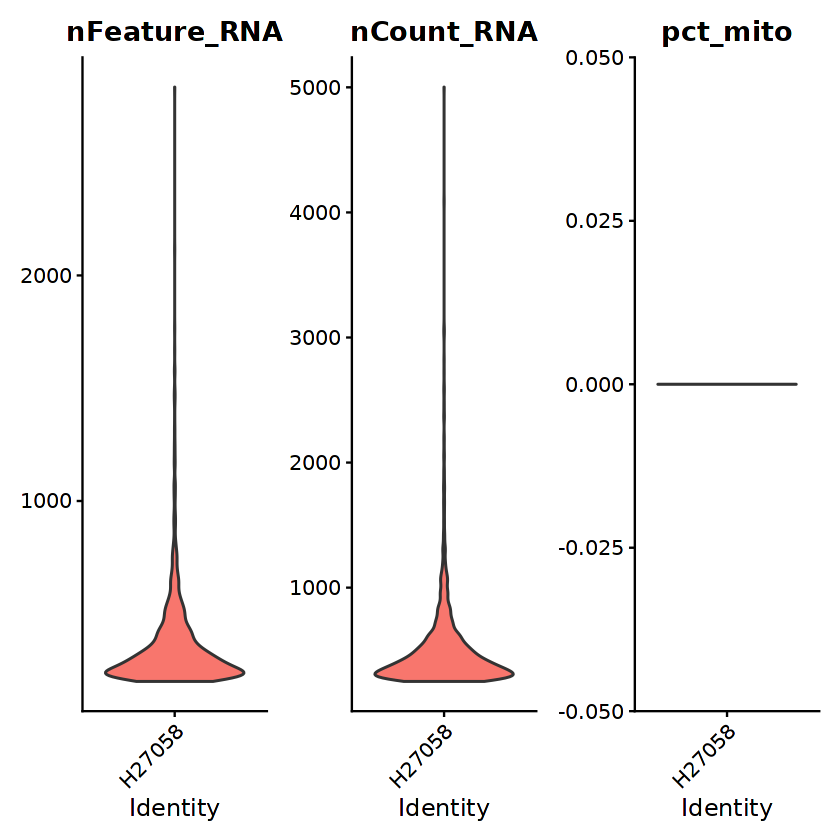

An object of class Seurat 
27957 features across 2095 samples within 1 assay 
Active assay: RNA (27957 features, 0 variable features)
 1 layer present: counts

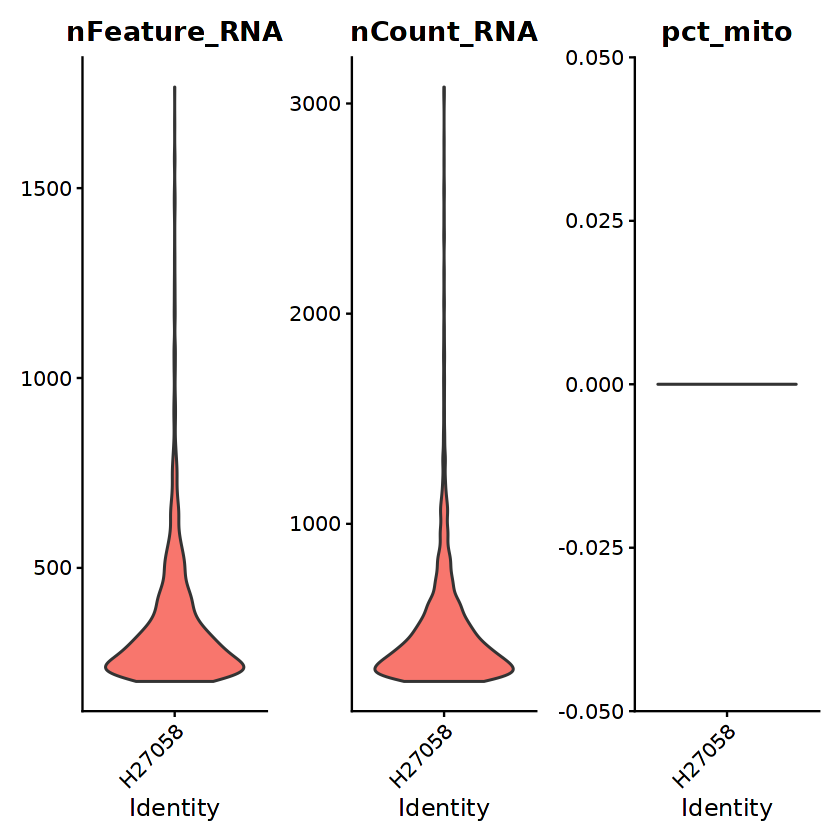

In [10]:
H27058 <- subset(cao.rna, idents = 'H27058')

#Add metadata
H27058 = RenameCells(H27058, add.cell.id = 'H27058')
H27058$modality = 'expression' 
H27058$dataset = 'cao_H27058'
H27058$pcw = '16'
H27058$cellsource = 'fetal'
H27058$gender = 'female'

#QC filtering
H27058[['pct_mito']] = PercentageFeatureSet(H27058, pattern = '^MT-')
VlnPlot(H27058, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

H27058 <- subset(H27058, subset = nFeature_RNA > 200 & nFeature_RNA < 2000 & pct_mito < 20)
VlnPlot(H27058, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(H27058)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
H27058 = subset(H27058, features = anti_mt_genes)

H27058

#Save Checkpoint
saveRDS(H27058, file='checkpoints/Fetal/RNA_datasets/cao_H27058.rds')
rm(H27058)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”


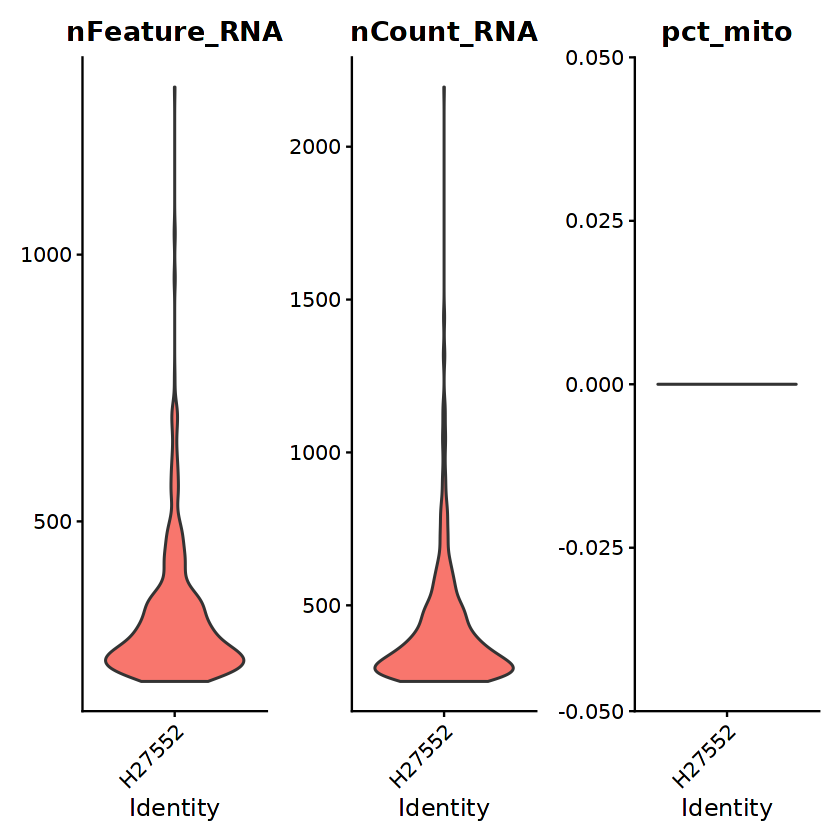

An object of class Seurat 
27957 features across 698 samples within 1 assay 
Active assay: RNA (27957 features, 0 variable features)
 1 layer present: counts

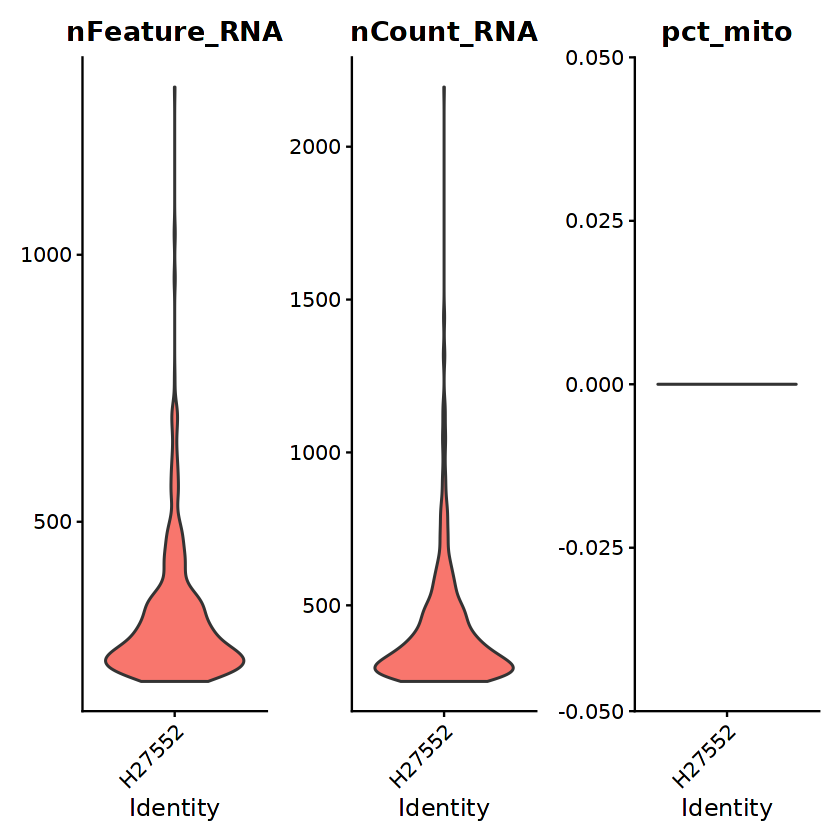

In [11]:
H27552 <- subset(cao.rna, idents = 'H27552')

#Add metadata
H27552 = RenameCells(H27552, add.cell.id = 'H27552')
H27552$modality = 'expression' 
H27552$dataset = 'cao_H27552'
H27552$pcw = '16'
H27552$cellsource = 'fetal'
H27552$gender = 'male'

#QC filtering
H27552[['pct_mito']] = PercentageFeatureSet(H27552, pattern = '^MT-')
VlnPlot(H27552, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

H27552 <- subset(H27552, subset = nFeature_RNA > 200 & nFeature_RNA < 2000 & pct_mito < 20)
VlnPlot(H27552, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(H27552)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
H27552 = subset(H27552, features = anti_mt_genes)

H27552

#Save Checkpoint
saveRDS(H27552, file='checkpoints/Fetal/RNA_datasets/cao_H27552.rds')
rm(H27552, cao.rna)

## Ma et al

In [12]:
#Load RNA data
counts.pcw7_11 <- as.matrix(fread('rawdata/RNA/fetal/Ma_fetal/OMIX001616-01.txt.gz'), rownames=1)
colnames(counts.pcw7_11) <- gsub('\\.','-', colnames(counts.pcw7_11))
counts.pcw7_11[counts.pcw7_11<0]<-0

counts.pcw4_6 <- as.matrix(fread('rawdata/RNA/fetal/Ma_fetal/OMIX001616-02.txt.gz'), rownames=1)
colnames(counts.pcw4_6) <- gsub('\\.','-', colnames(counts.pcw4_6))
counts.pcw4_6[counts.pcw4_6<0]<-0

#note: fetus age in days is available
#note: total number of embryo samples = 17

#Create SeuratObjects
pcw4_6 <- CreateSeuratObject(counts = counts.pcw4_6, names.field = 2, min.cells = 10, min.features = 200)
pcw7_11 <- CreateSeuratObject(counts = counts.pcw7_11, names.field = 2, min.cells = 10, min.features = 200)

saveRDS(pcw4_6, file='checkpoints/Fetal/Ma_RNA_pcw4-6.rds')
saveRDS(pcw7_11, file='checkpoints/Fetal/Ma_RNA_pcw7-11.rds')
rm(counts.pcw4_6, counts.pcw7_11)

Warning message in fread("rawdata/RNA/fetal/Ma_fetal/OMIX001616-01.txt.gz"):
“Detected 41727 column names but the data has 41728 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in fread("rawdata/RNA/fetal/Ma_fetal/OMIX001616-02.txt.gz"):
“Detected 35079 column names but the data has 35080 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”
Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


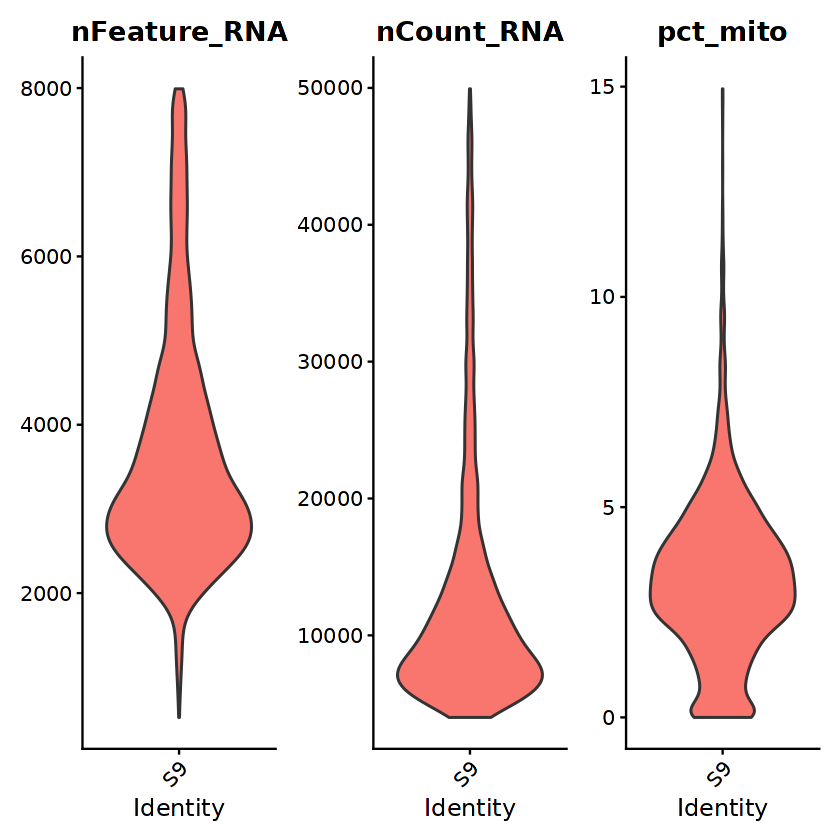

An object of class Seurat 
23650 features across 3837 samples within 1 assay 
Active assay: RNA (23650 features, 0 variable features)
 1 layer present: counts

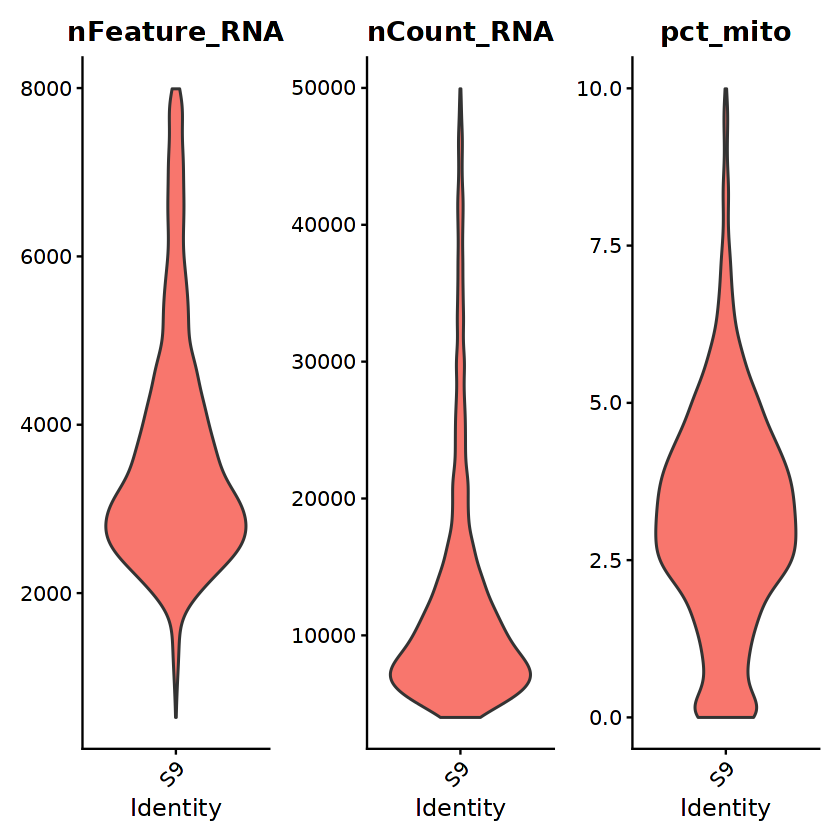

In [13]:
S9 <- subset(pcw7_11, idents = 'S9')

#Add metadata
S9 = RenameCells(S9, add.cell.id = 'S9')
S9$modality = 'expression' 
S9$dataset = 'ma_S9'
S9$pcw = '8'
S9$cellsource = 'fetal'
S9$gender = 'female'

#QC filtering
S9[['pct_mito']] = PercentageFeatureSet(S9, pattern = '^MT-')
VlnPlot(S9, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

S9 <- subset(S9, subset = nFeature_RNA > 200 & nFeature_RNA < 8000 & pct_mito < 10)
VlnPlot(S9, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(S9)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
S9 = subset(S9, features = anti_mt_genes)

S9

#Save Checkpoint
saveRDS(S9, file='checkpoints/Fetal/RNA_datasets/ma_S9.rds')
rm(S9)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


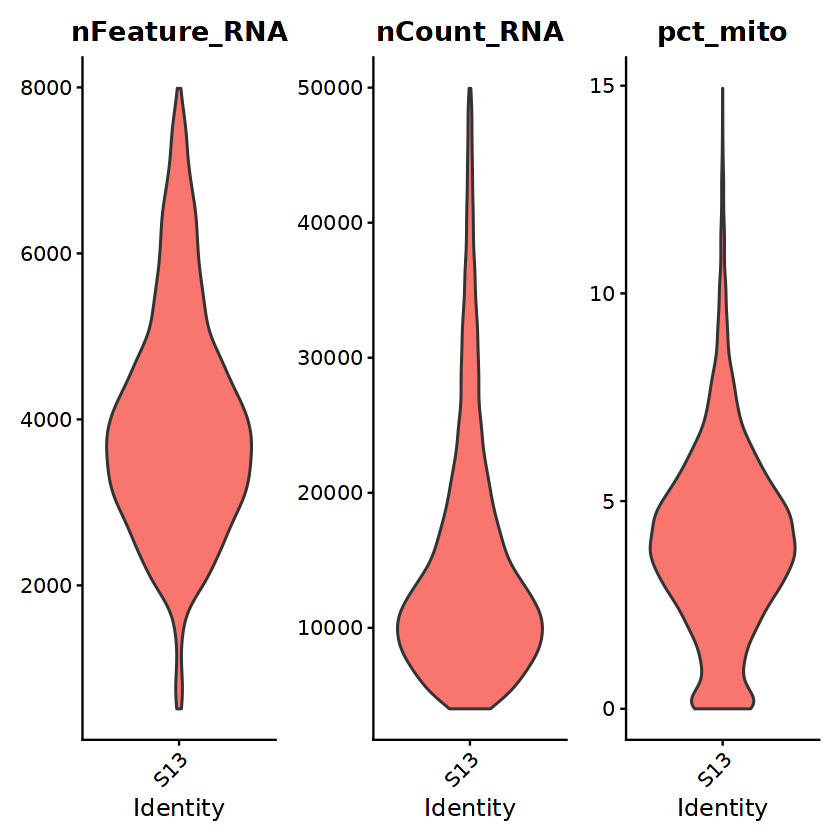

An object of class Seurat 
23650 features across 5101 samples within 1 assay 
Active assay: RNA (23650 features, 0 variable features)
 1 layer present: counts

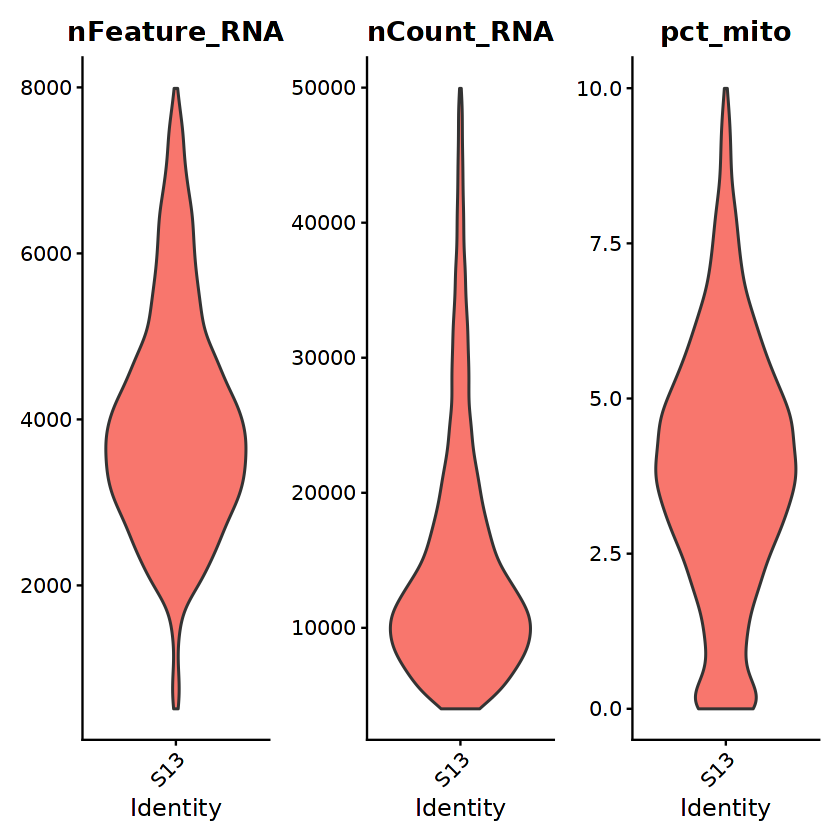

In [14]:
S13 <- subset(pcw7_11, idents = 'S13')

#Add metadata
S13 = RenameCells(S13, add.cell.id = 'S13')
S13$modality = 'expression' 
S13$dataset = 'ma_S13'
S13$pcw = '11'
S13$cellsource = 'fetal'
S13$gender = 'female'

#QC filtering
S13[['pct_mito']] = PercentageFeatureSet(S13, pattern = '^MT-')
VlnPlot(S13, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

S13 <- subset(S13, subset = nFeature_RNA > 200 & nFeature_RNA < 8000 & pct_mito < 10)
VlnPlot(S13, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(S13)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
S13 = subset(S13, features = anti_mt_genes)

S13

#Save Checkpoint
saveRDS(S13, file='checkpoints/Fetal/RNA_datasets/ma_S13.rds')
rm(S13)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


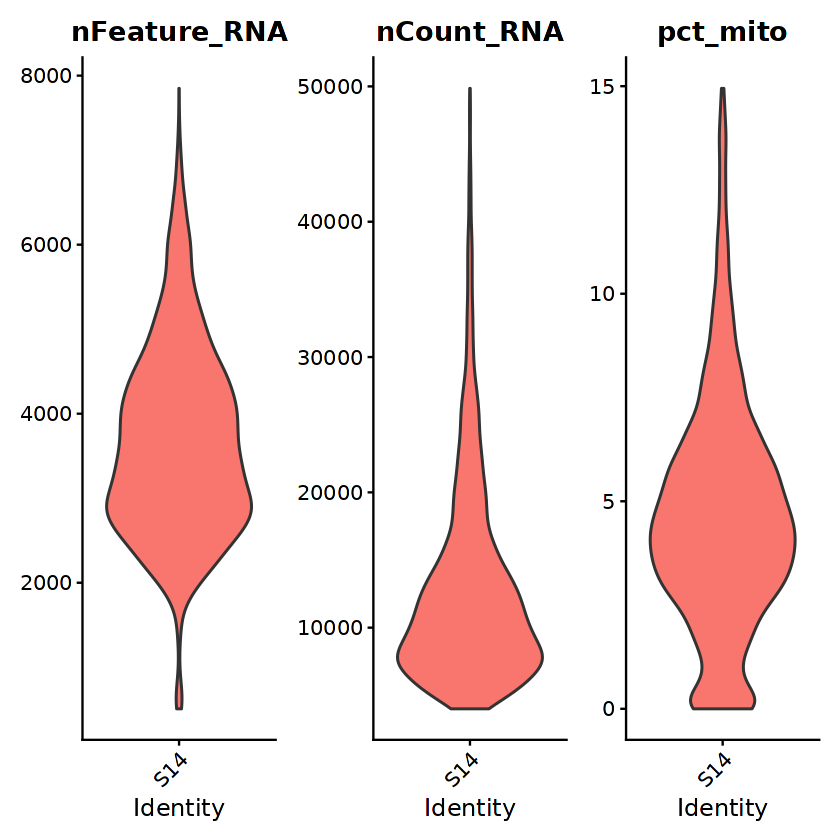

An object of class Seurat 
23650 features across 5090 samples within 1 assay 
Active assay: RNA (23650 features, 0 variable features)
 1 layer present: counts

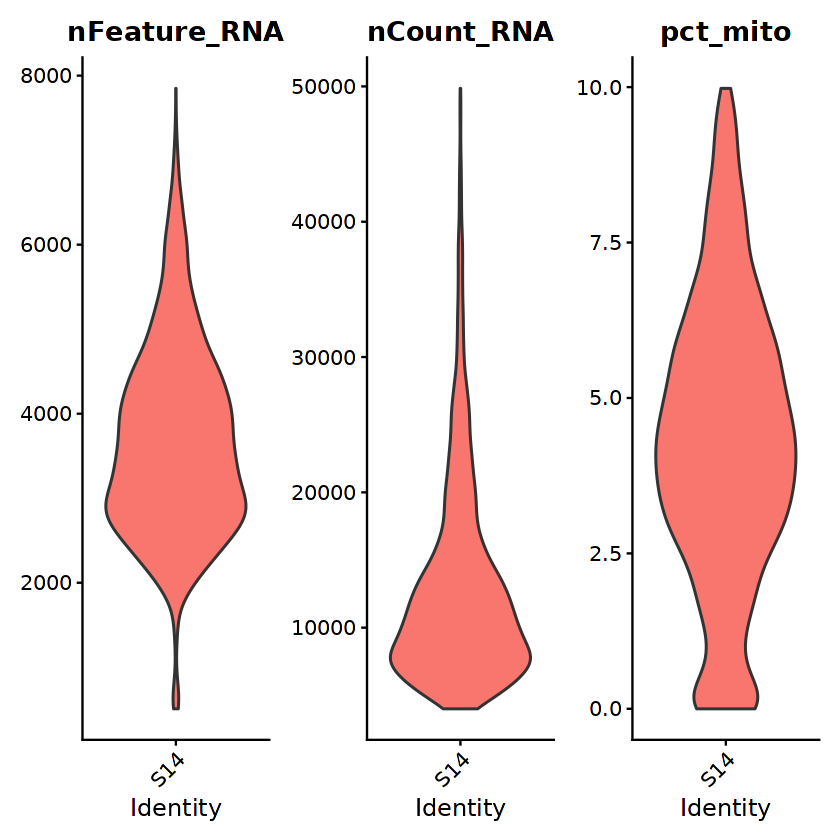

In [15]:
S14 <- subset(pcw7_11, idents = 'S14')

#Add metadata
S14 = RenameCells(S14, add.cell.id = 'S14')
S14$modality = 'expression' 
S14$dataset = 'ma_S14'
S14$pcw = '11'
S14$cellsource = 'fetal'
S14$gender = 'female'

#QC filtering
S14[['pct_mito']] = PercentageFeatureSet(S14, pattern = '^MT-')
VlnPlot(S14, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

S14 <- subset(S14, subset = nFeature_RNA > 200 & nFeature_RNA < 8000 & pct_mito < 10)
VlnPlot(S14, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(S14)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
S14 = subset(S14, features = anti_mt_genes)

S14

#Save Checkpoint
saveRDS(S14, file='checkpoints/Fetal/RNA_datasets/ma_S14.rds')
rm(S14)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


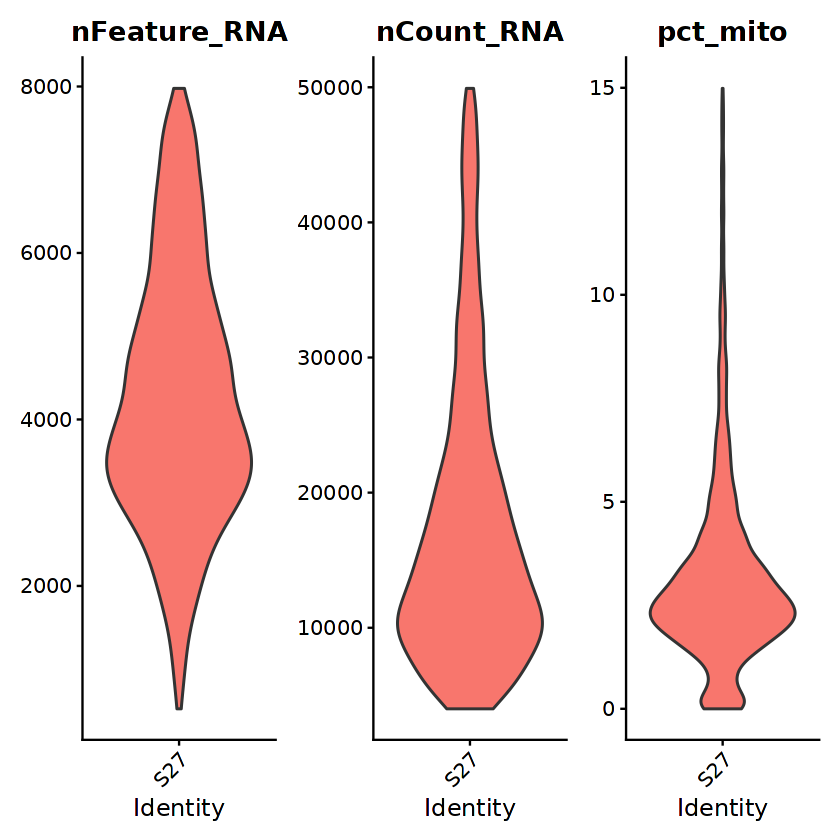

An object of class Seurat 
23650 features across 2665 samples within 1 assay 
Active assay: RNA (23650 features, 0 variable features)
 1 layer present: counts

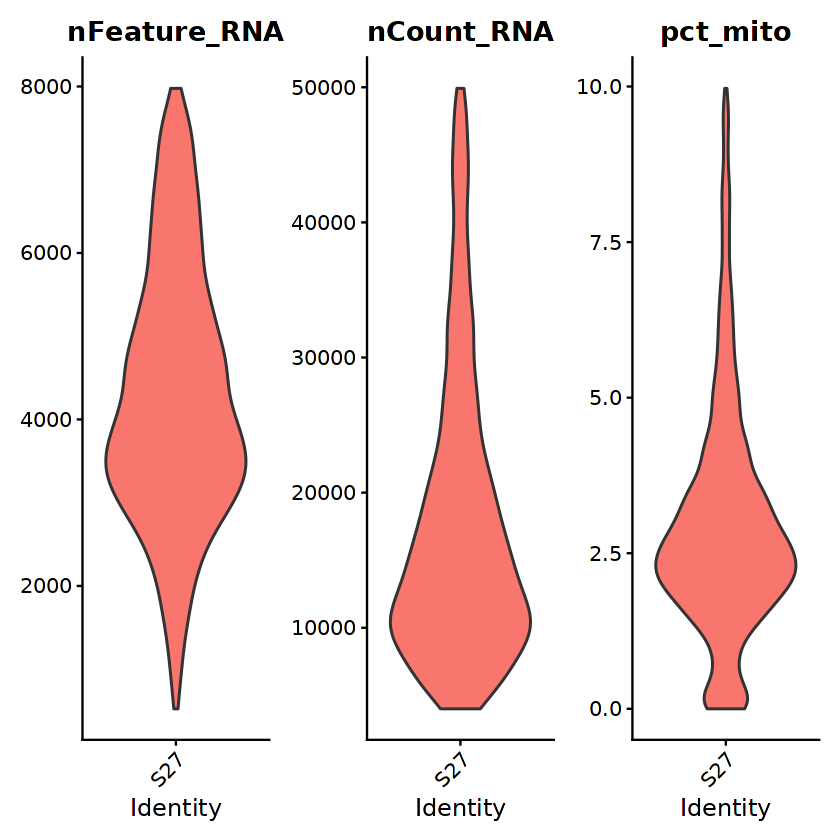

In [16]:
S27 <- subset(pcw7_11, idents = 'S27')

#Add metadata
S27 = RenameCells(S27, add.cell.id = 'S27')
S27$modality = 'expression' 
S27$dataset = 'ma_S27'
S27$pcw = '8'
S27$cellsource = 'fetal'
S27$gender = 'female'

#QC filtering
S27[['pct_mito']] = PercentageFeatureSet(S27, pattern = '^MT-')
VlnPlot(S27, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

S27 <- subset(S27, subset = nFeature_RNA > 200 & nFeature_RNA < 8000 & pct_mito < 10)
VlnPlot(S27, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(S27)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
S27 = subset(S27, features = anti_mt_genes)

S27

#Save Checkpoint
saveRDS(S27, file='checkpoints/Fetal/RNA_datasets/ma_S27.rds')
rm(S27)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


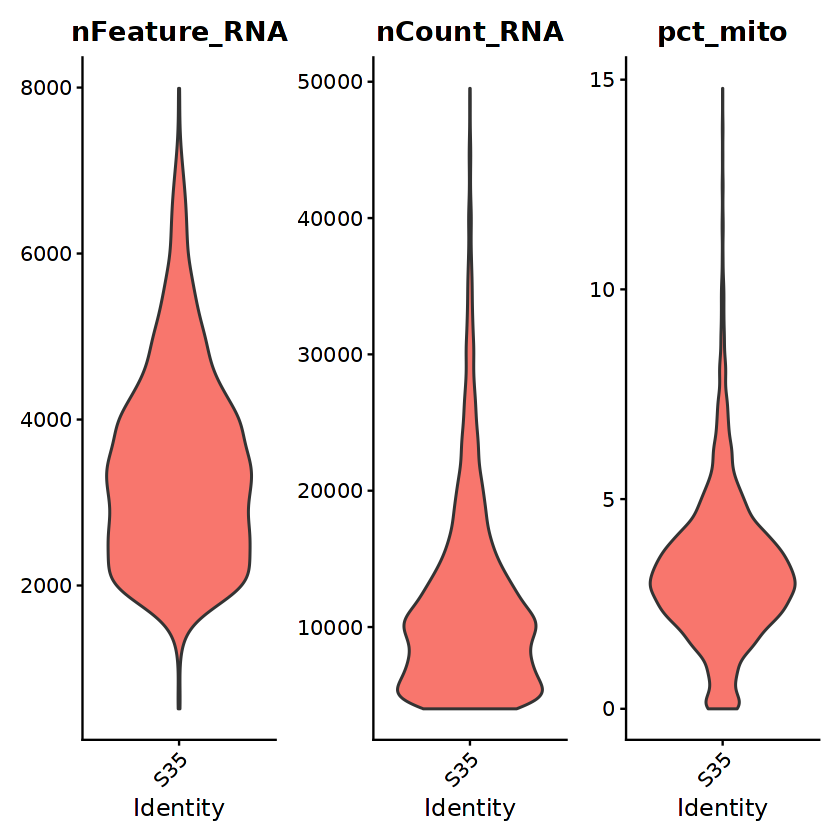

An object of class Seurat 
23650 features across 4726 samples within 1 assay 
Active assay: RNA (23650 features, 0 variable features)
 1 layer present: counts

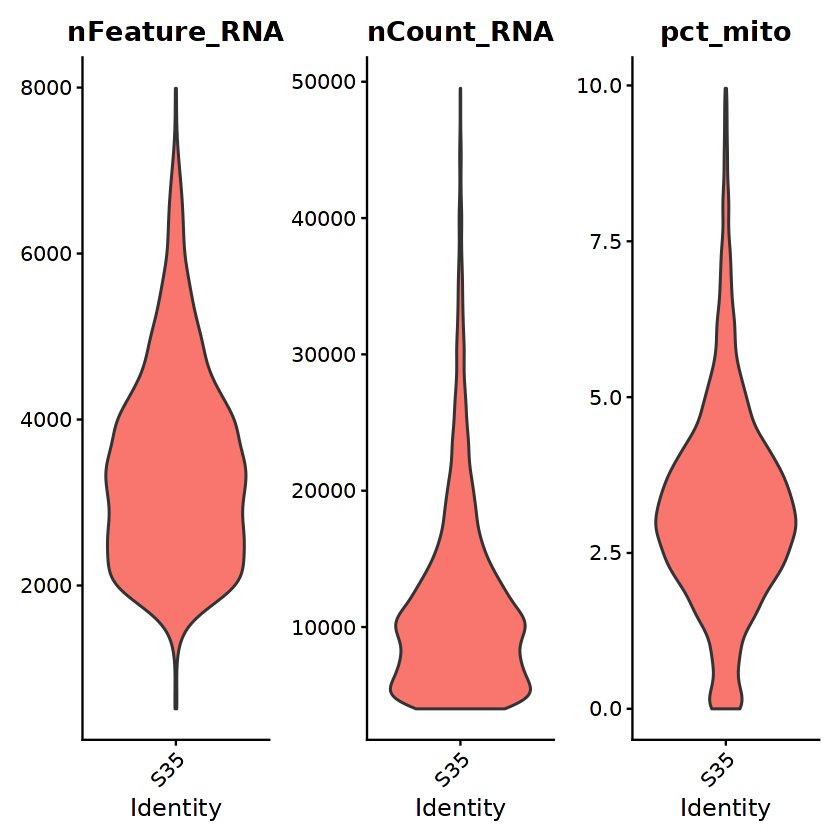

In [17]:
S35 <- subset(pcw7_11, idents = 'S35')

#Add metadata
S35 = RenameCells(S35, add.cell.id = 'S35')
S35$modality = 'expression' 
S35$dataset = 'ma_S35'
S35$pcw = '10'
S35$cellsource = 'fetal'
S35$gender = 'female'

#QC filtering
S35[['pct_mito']] = PercentageFeatureSet(S35, pattern = '^MT-')
VlnPlot(S35, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

S35 <- subset(S35, subset = nFeature_RNA > 200 & nFeature_RNA < 8000 & pct_mito < 10)
VlnPlot(S35, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(S35)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
S35 = subset(S35, features = anti_mt_genes)

S35

#Save Checkpoint
saveRDS(S35, file='checkpoints/Fetal/RNA_datasets/ma_S35.rds')
rm(S35)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


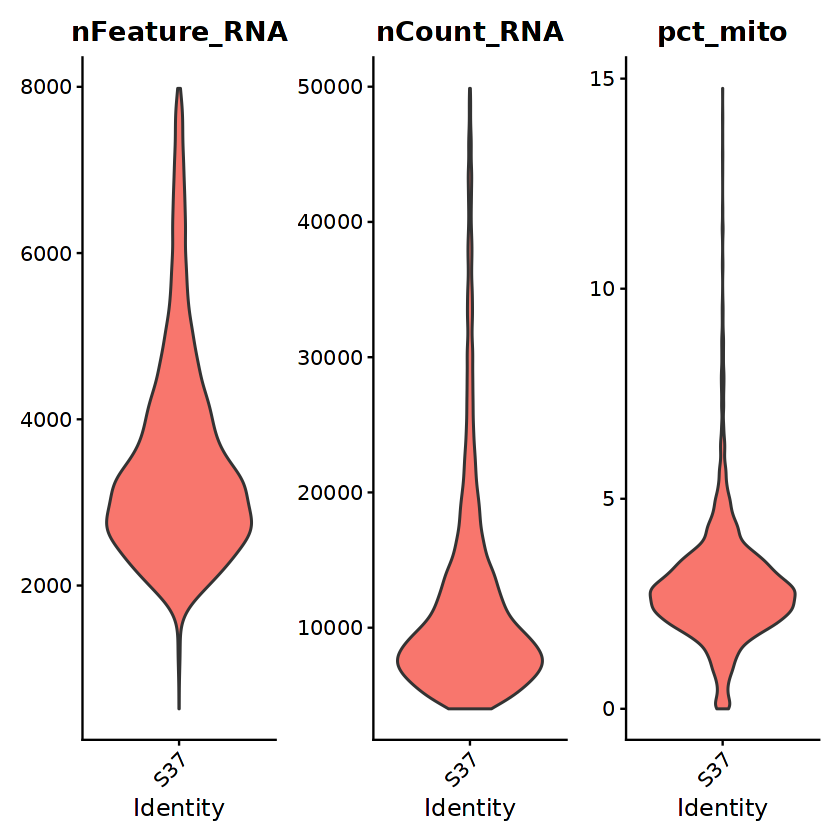

An object of class Seurat 
23080 features across 5152 samples within 1 assay 
Active assay: RNA (23080 features, 0 variable features)
 1 layer present: counts

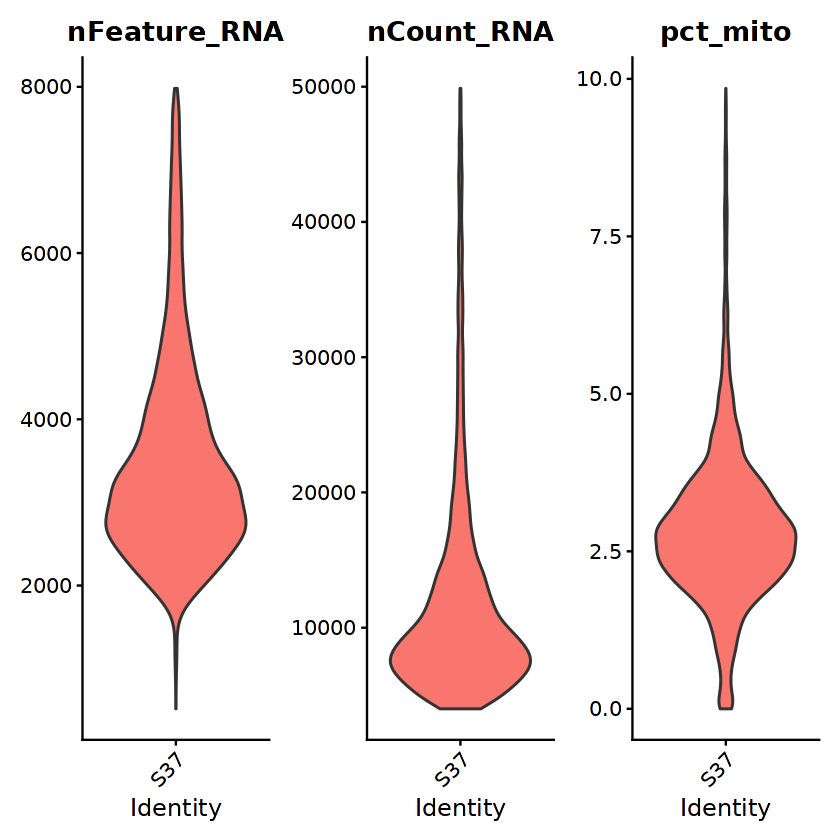

In [18]:
S37 <- subset(pcw4_6, idents = 'S37')

#Add metadata
S37 = RenameCells(S37, add.cell.id = 'S37')
S37$modality = 'expression' 
S37$dataset = 'ma_S37'
S37$pcw = '6'
S37$cellsource = 'fetal'
S37$gender = 'male'

#QC filtering
S37[['pct_mito']] = PercentageFeatureSet(S37, pattern = '^MT-')
VlnPlot(S37, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

S37 <- subset(S37, subset = nFeature_RNA > 200 & nFeature_RNA < 8000 & pct_mito < 10)
VlnPlot(S37, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(S37)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
S37 = subset(S37, features = anti_mt_genes)

S37

#Save Checkpoint
saveRDS(S37, file='checkpoints/Fetal/RNA_datasets/ma_S37.rds')
rm(S37)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


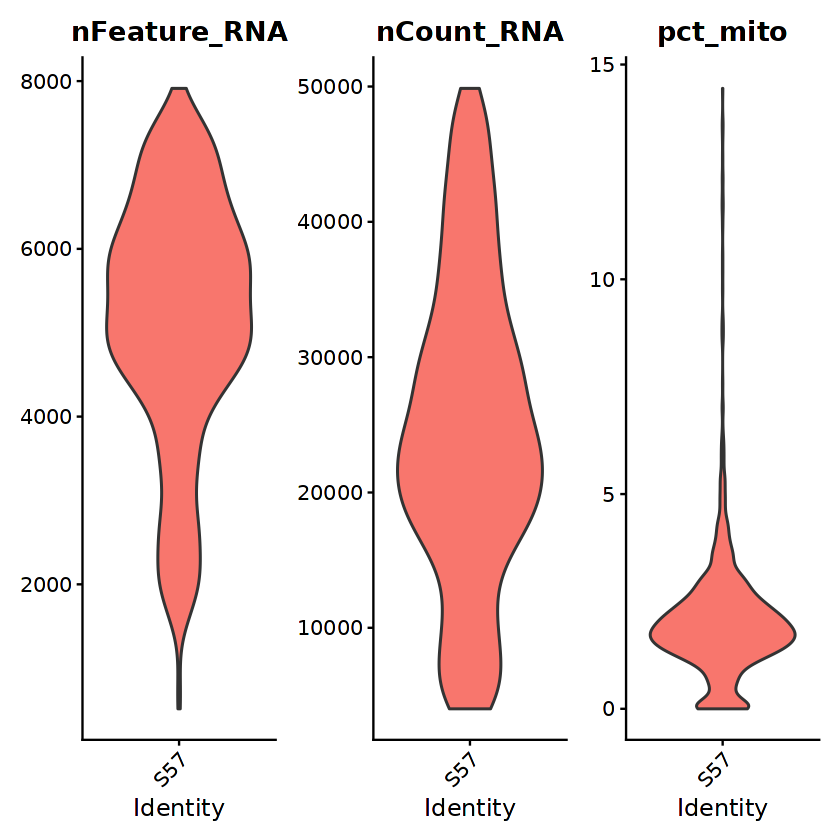

An object of class Seurat 
23080 features across 1735 samples within 1 assay 
Active assay: RNA (23080 features, 0 variable features)
 1 layer present: counts

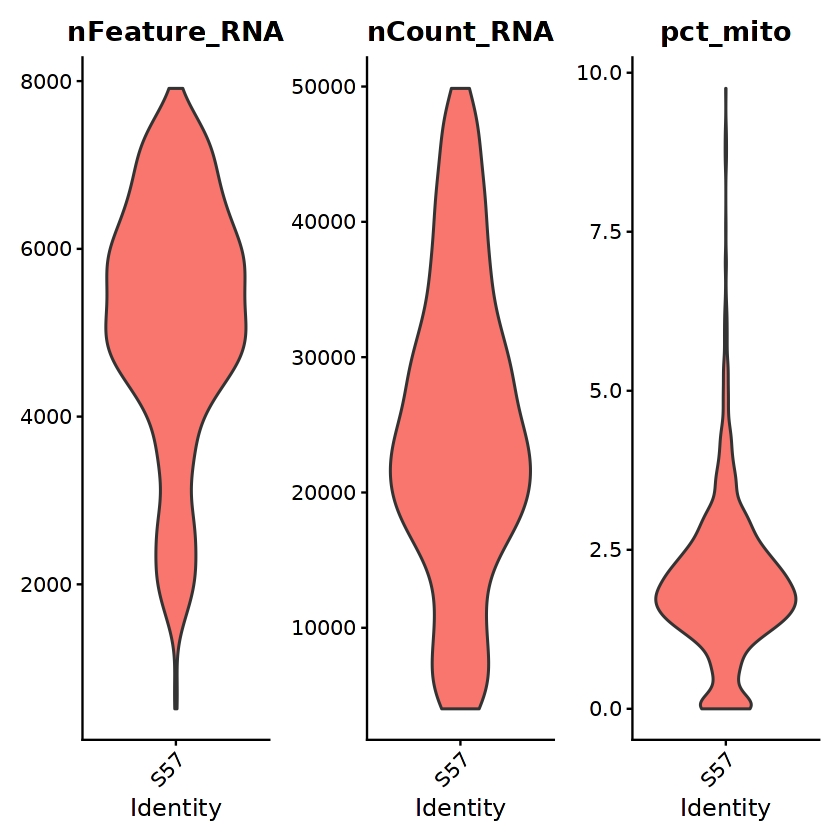

In [19]:
S57 <- subset(pcw4_6, idents = 'S57')

#Add metadata
S57 = RenameCells(S57, add.cell.id = 'S57')
S57$modality = 'expression' 
S57$dataset = 'ma_S57'
S57$pcw = '4'
S57$cellsource = 'fetal'
S57$gender = 'female'

#QC filtering
S57[['pct_mito']] = PercentageFeatureSet(S57, pattern = '^MT-')
VlnPlot(S57, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

S57 <- subset(S57, subset = nFeature_RNA > 200 & nFeature_RNA < 8000 & pct_mito < 10)
VlnPlot(S57, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(S57)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
S57 = subset(S57, features = anti_mt_genes)

S57

#Save Checkpoint
saveRDS(S57, file='checkpoints/Fetal/RNA_datasets/ma_S57.rds')
rm(S57)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


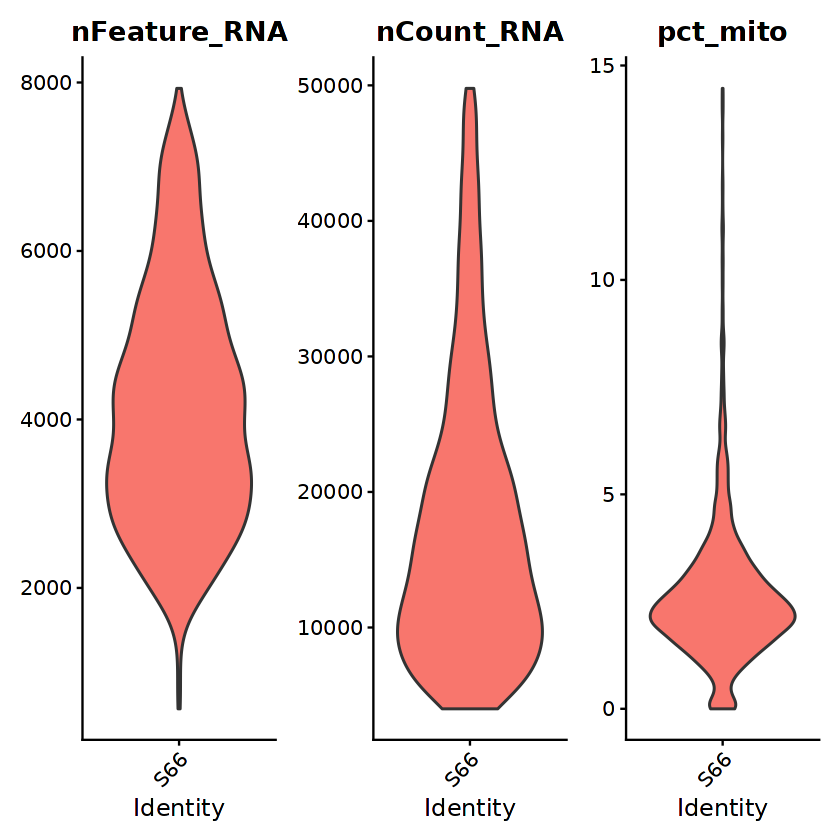

An object of class Seurat 
23650 features across 2639 samples within 1 assay 
Active assay: RNA (23650 features, 0 variable features)
 1 layer present: counts

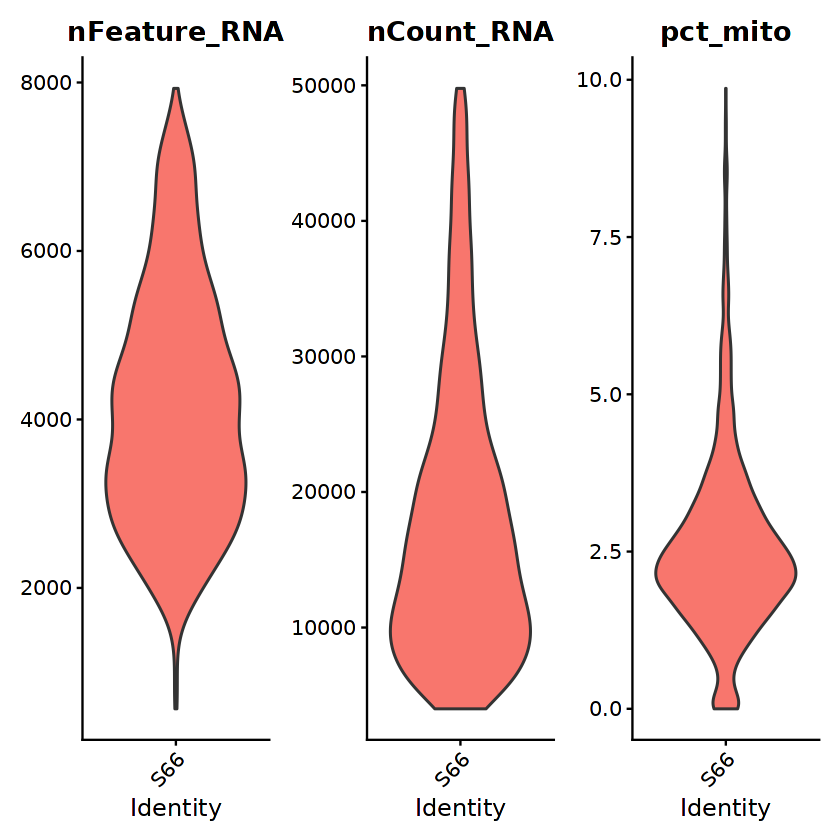

In [20]:
S66 <- subset(pcw7_11, idents = 'S66')

#Add metadata
S66 = RenameCells(S66, add.cell.id = 'S66')
S66$modality = 'expression' 
S66$dataset = 'ma_S66'
S66$pcw = '8'
S66$cellsource = 'fetal'
S66$gender = 'male'

#QC filtering
S66[['pct_mito']] = PercentageFeatureSet(S66, pattern = '^MT-')
VlnPlot(S66, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

S66 <- subset(S66, subset = nFeature_RNA > 200 & nFeature_RNA < 8000 & pct_mito < 10)
VlnPlot(S66, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(S66)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
S66 = subset(S66, features = anti_mt_genes)

S66

#Save Checkpoint
saveRDS(S66, file='checkpoints/Fetal/RNA_datasets/ma_S66.rds')
rm(S66)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


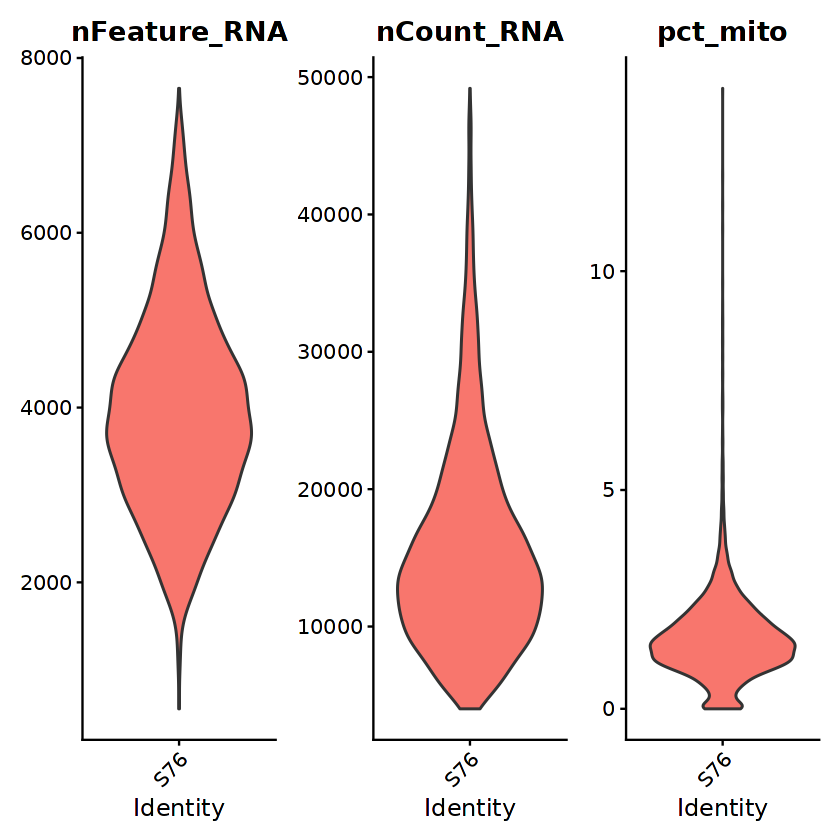

An object of class Seurat 
23080 features across 5992 samples within 1 assay 
Active assay: RNA (23080 features, 0 variable features)
 1 layer present: counts

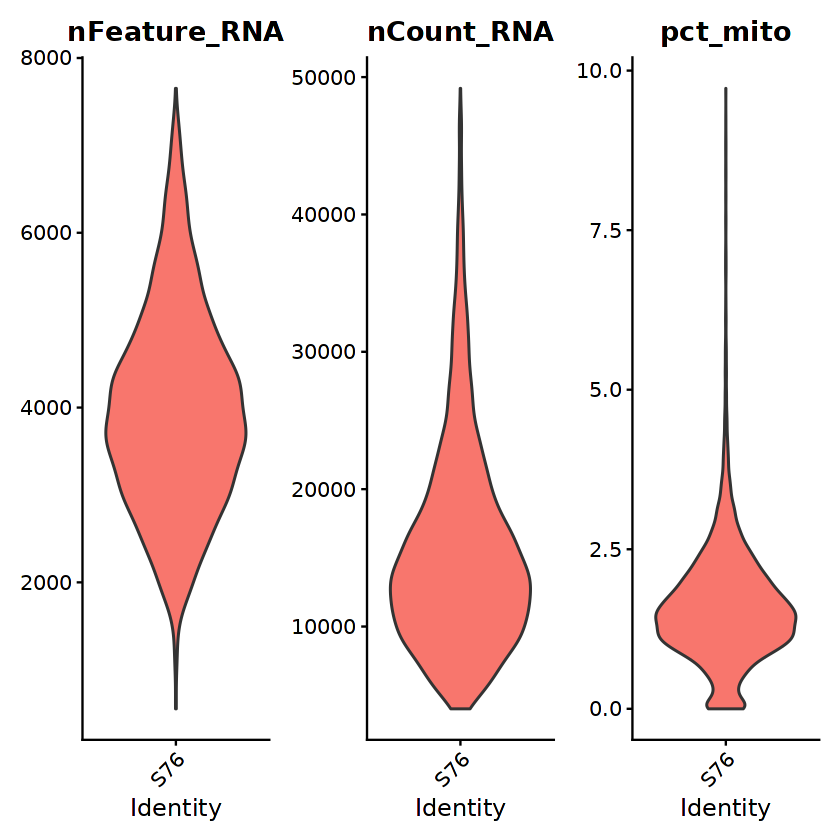

In [21]:
S76 <- subset(pcw4_6, idents = 'S76')

#Add metadata
S76 = RenameCells(S76, add.cell.id = 'S76')
S76$modality = 'expression' 
S76$dataset = 'ma_S76'
S76$pcw = '5'
S76$cellsource = 'fetal'
S76$gender = 'female'

#QC filtering
S76[['pct_mito']] = PercentageFeatureSet(S76, pattern = '^MT-')
VlnPlot(S76, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

S76 <- subset(S76, subset = nFeature_RNA > 200 & nFeature_RNA < 8000 & pct_mito < 10)
VlnPlot(S76, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(S76)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
S76 = subset(S76, features = anti_mt_genes)

S76

#Save Checkpoint
saveRDS(S76, file='checkpoints/Fetal/RNA_datasets/ma_S76.rds')
rm(S76)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


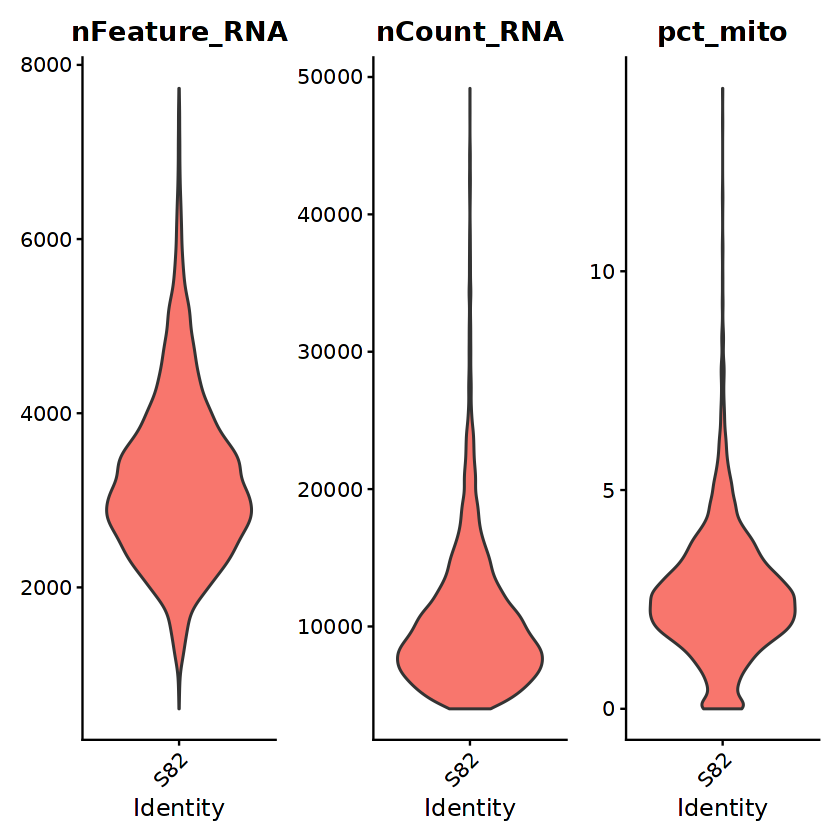

An object of class Seurat 
23080 features across 6294 samples within 1 assay 
Active assay: RNA (23080 features, 0 variable features)
 1 layer present: counts

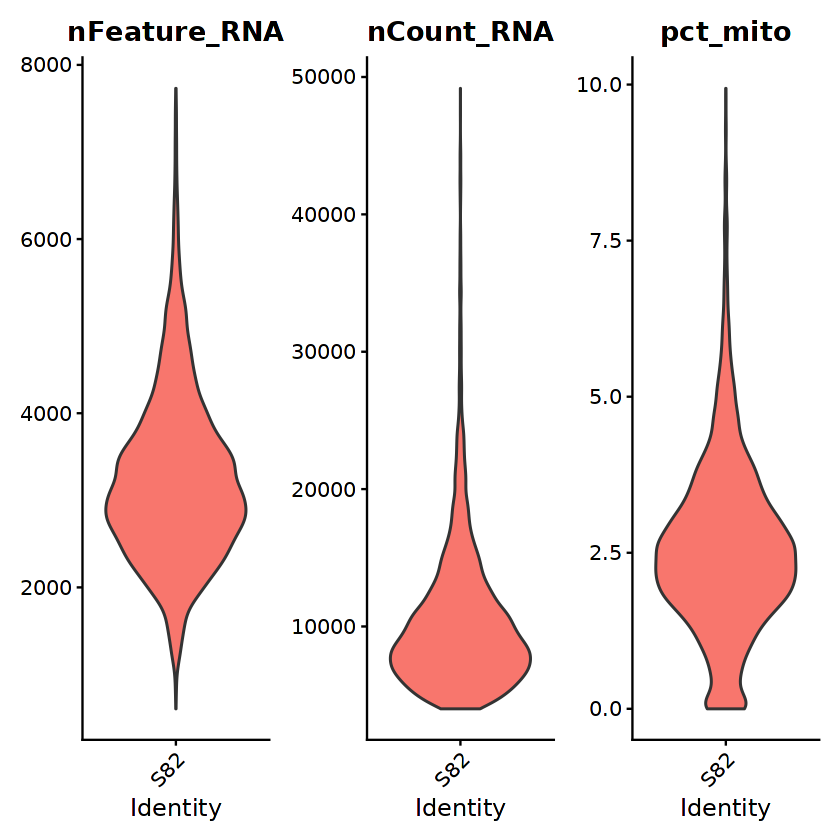

In [22]:
S82 <- subset(pcw4_6, idents = 'S82')

#Add metadata
S82 = RenameCells(S82, add.cell.id = 'S82')
S82$modality = 'expression' 
S82$dataset = 'ma_S82'
S82$pcw = '5'
S82$cellsource = 'fetal'
S82$gender = 'male'

#QC filtering
S82[['pct_mito']] = PercentageFeatureSet(S82, pattern = '^MT-')
VlnPlot(S82, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

S82 <- subset(S82, subset = nFeature_RNA > 200 & nFeature_RNA < 8000 & pct_mito < 10)
VlnPlot(S82, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(S82)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
S82 = subset(S82, features = anti_mt_genes)

S82

#Save Checkpoint
saveRDS(S82, file='checkpoints/Fetal/RNA_datasets/ma_S82.rds')
rm(S82)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


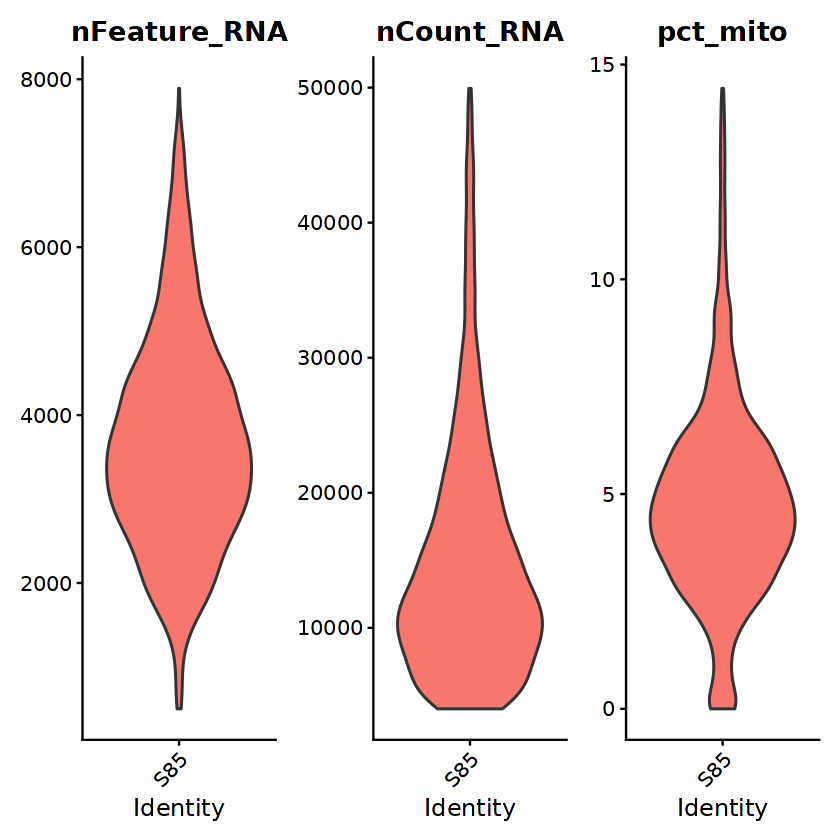

An object of class Seurat 
23650 features across 2418 samples within 1 assay 
Active assay: RNA (23650 features, 0 variable features)
 1 layer present: counts

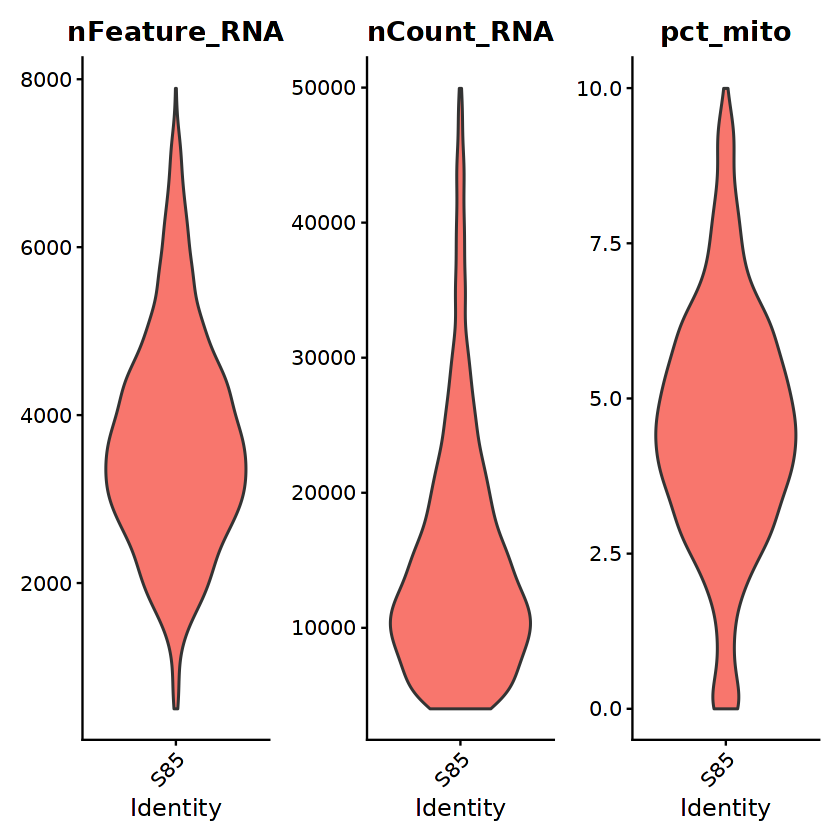

In [23]:
S85 <- subset(pcw7_11, idents = 'S85')

#Add metadata
S85 = RenameCells(S85, add.cell.id = 'S85')
S85$modality = 'expression' 
S85$dataset = 'ma_S85'
S85$pcw = '9'
S85$cellsource = 'fetal'
S85$gender = 'male'

#QC filtering
S85[['pct_mito']] = PercentageFeatureSet(S85, pattern = '^MT-')
VlnPlot(S85, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

S85 <- subset(S85, subset = nFeature_RNA > 200 & nFeature_RNA < 8000 & pct_mito < 10)
VlnPlot(S85, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(S85)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
S85 = subset(S85, features = anti_mt_genes)

S85

#Save Checkpoint
saveRDS(S85, file='checkpoints/Fetal/RNA_datasets/ma_S85.rds')
rm(S85)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


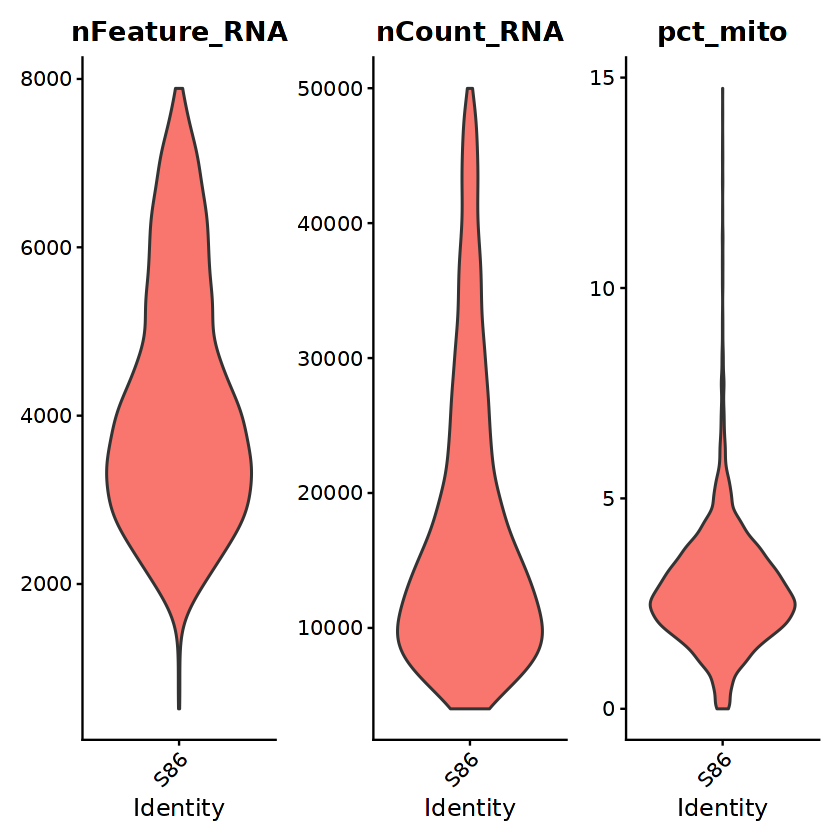

An object of class Seurat 
23650 features across 4463 samples within 1 assay 
Active assay: RNA (23650 features, 0 variable features)
 1 layer present: counts

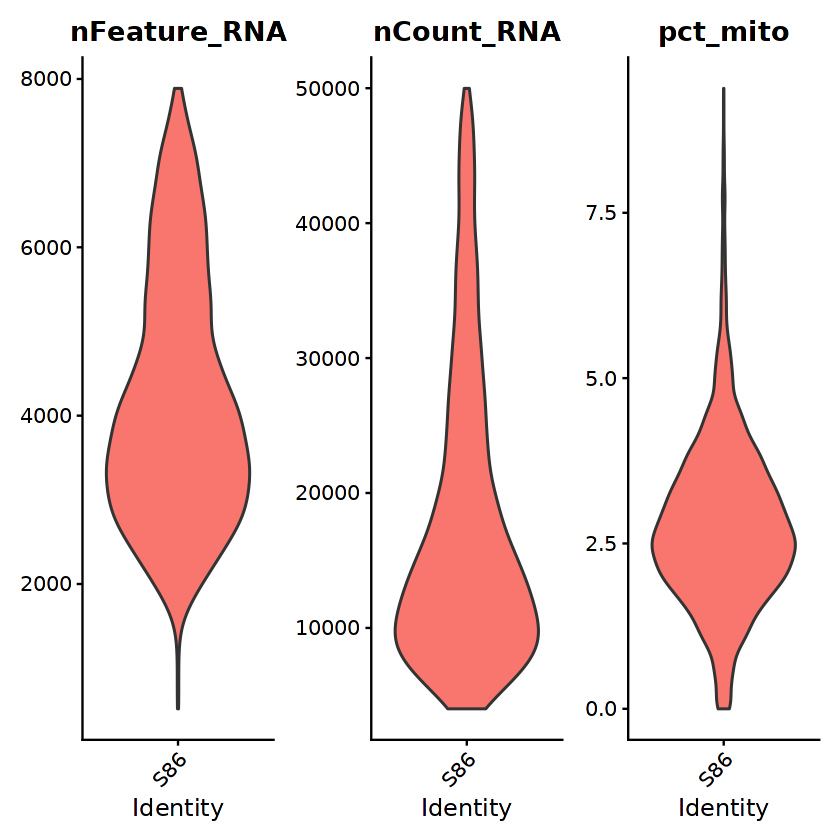

In [24]:
S86 <- subset(pcw7_11, idents = 'S86')

#Add metadata
S86 = RenameCells(S86, add.cell.id = 'S86')
S86$modality = 'expression' 
S86$dataset = 'ma_S86'
S86$pcw = '8'
S86$cellsource = 'fetal'
S86$gender = 'female'

#QC filtering
S86[['pct_mito']] = PercentageFeatureSet(S86, pattern = '^MT-')
VlnPlot(S86, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

S86 <- subset(S86, subset = nFeature_RNA > 200 & nFeature_RNA < 8000 & pct_mito < 10)
VlnPlot(S86, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(S86)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
S86 = subset(S86, features = anti_mt_genes)

S86

#Save Checkpoint
saveRDS(S86, file='checkpoints/Fetal/RNA_datasets/ma_S86.rds')
rm(S86)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


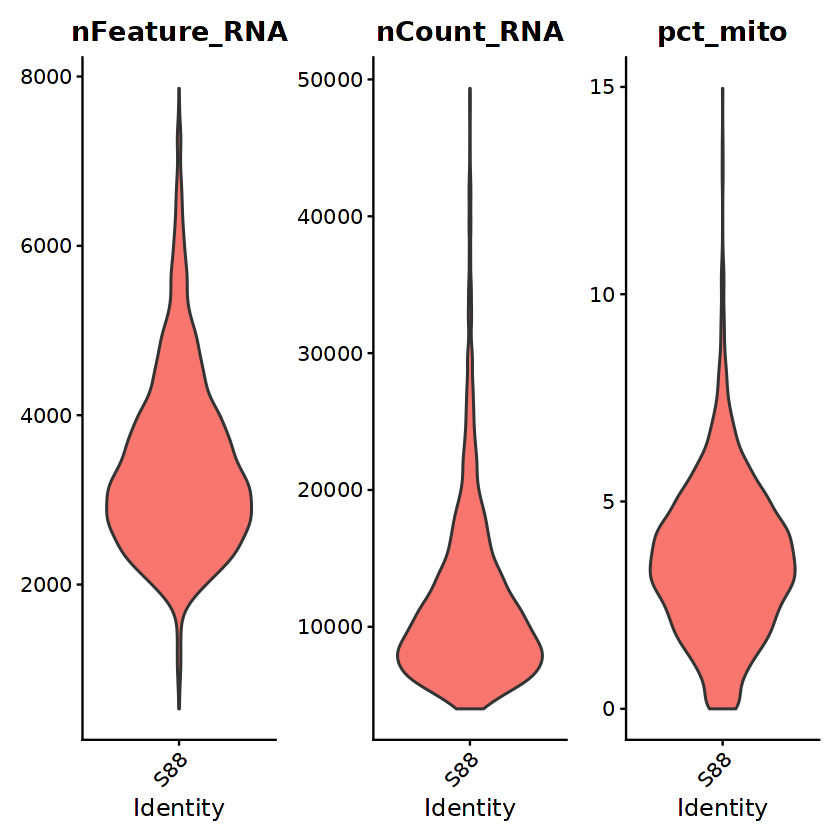

An object of class Seurat 
23080 features across 4791 samples within 1 assay 
Active assay: RNA (23080 features, 0 variable features)
 1 layer present: counts

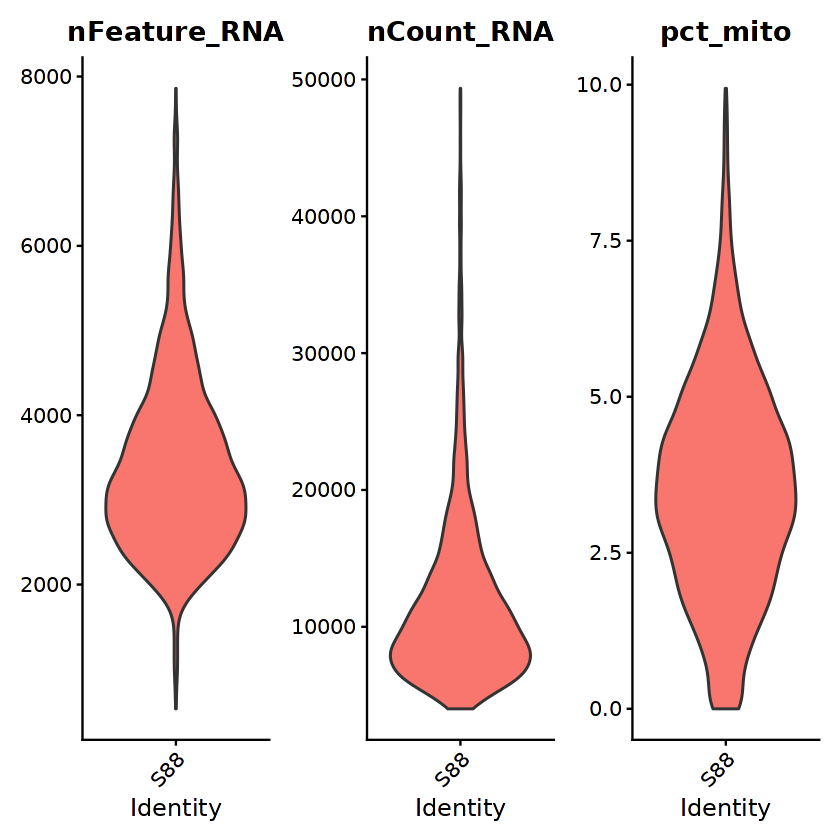

In [25]:
S88 <- subset(pcw4_6, idents = 'S88')

#Add metadata
S88 = RenameCells(S88, add.cell.id = 'S88')
S88$modality = 'expression' 
S88$dataset = 'ma_S88'
S88$pcw = '6'
S88$cellsource = 'fetal'
S88$gender = 'female'

#QC filtering
S88[['pct_mito']] = PercentageFeatureSet(S88, pattern = '^MT-')
VlnPlot(S88, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

S88 <- subset(S88, subset = nFeature_RNA > 200 & nFeature_RNA < 8000 & pct_mito < 10)
VlnPlot(S88, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(S88)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
S88 = subset(S88, features = anti_mt_genes)

S88

#Save Checkpoint
saveRDS(S88, file='checkpoints/Fetal/RNA_datasets/ma_S88.rds')
rm(S88)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


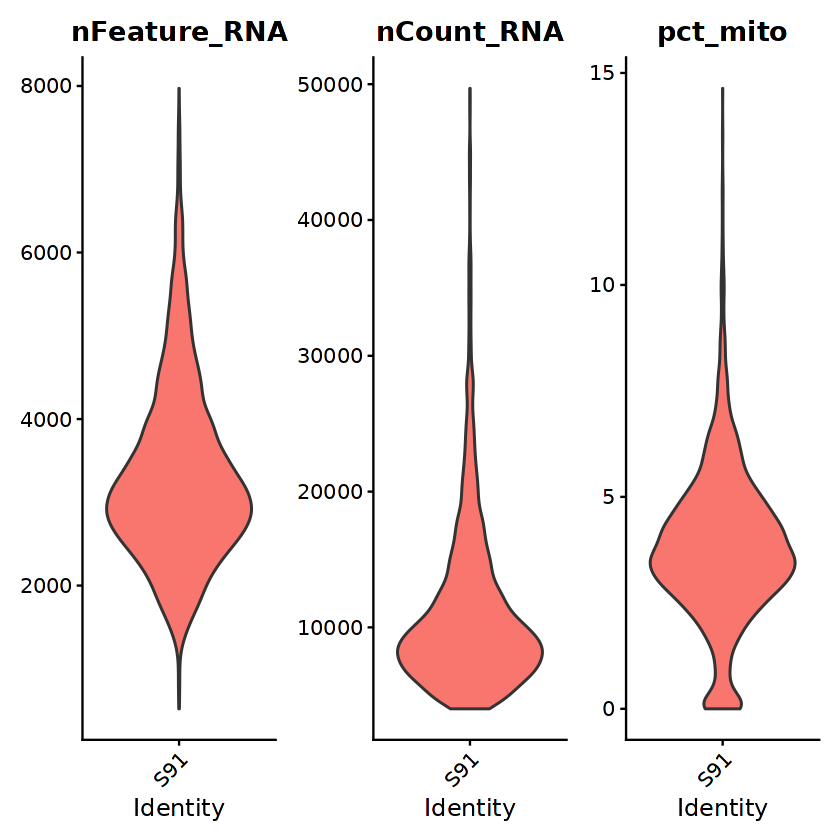

An object of class Seurat 
23080 features across 3420 samples within 1 assay 
Active assay: RNA (23080 features, 0 variable features)
 1 layer present: counts

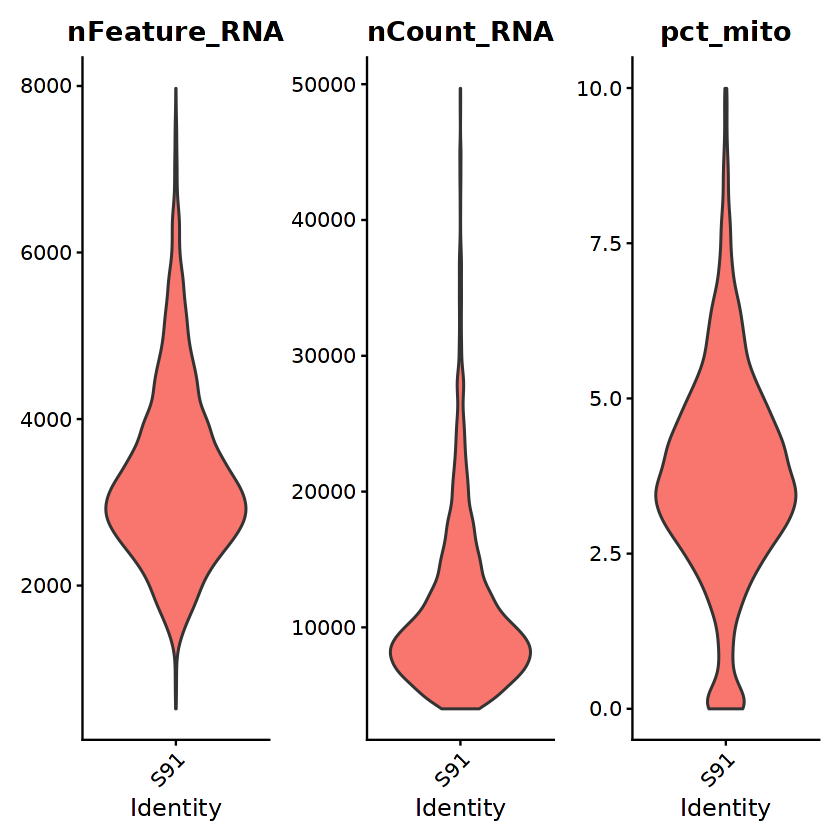

In [26]:
S91 <- subset(pcw4_6, idents = 'S91')

#Add metadata
S91 = RenameCells(S91, add.cell.id = 'S91')
S91$modality = 'expression' 
S91$dataset = 'ma_S91'
S91$pcw = '6'
S91$cellsource = 'fetal'
S91$gender = 'male'

#QC filtering
S91[['pct_mito']] = PercentageFeatureSet(S91, pattern = '^MT-')
VlnPlot(S91, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

S91 <- subset(S91, subset = nFeature_RNA > 200 & nFeature_RNA < 8000 & pct_mito < 10)
VlnPlot(S91, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(S91)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
S91 = subset(S91, features = anti_mt_genes)

S91

#Save Checkpoint
saveRDS(S91, file='checkpoints/Fetal/RNA_datasets/ma_S91.rds')
rm(S91)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


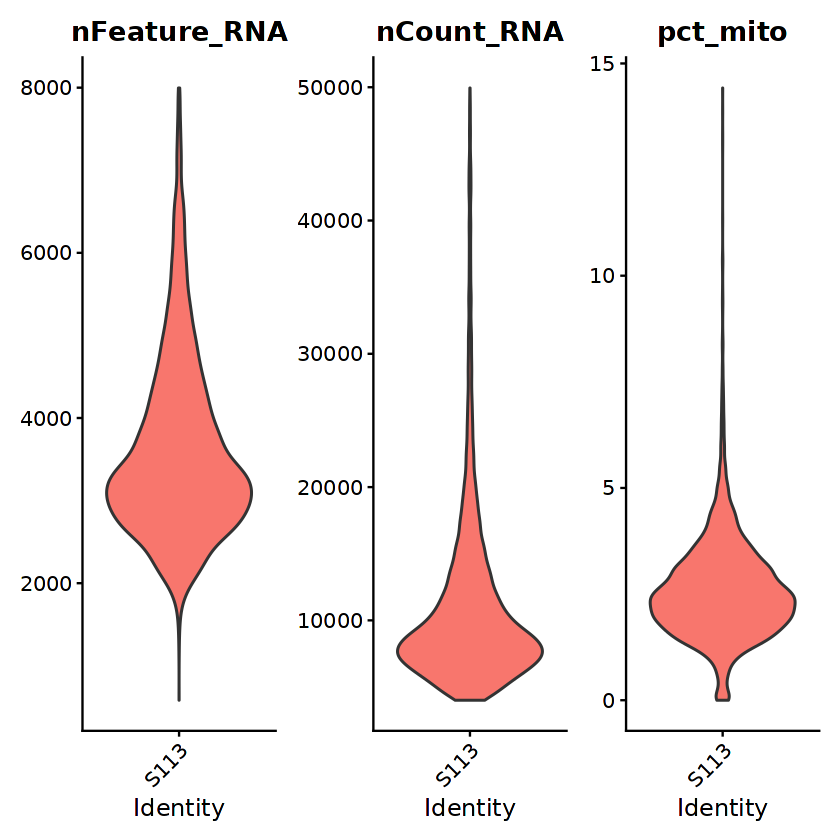

An object of class Seurat 
23080 features across 7574 samples within 1 assay 
Active assay: RNA (23080 features, 0 variable features)
 1 layer present: counts

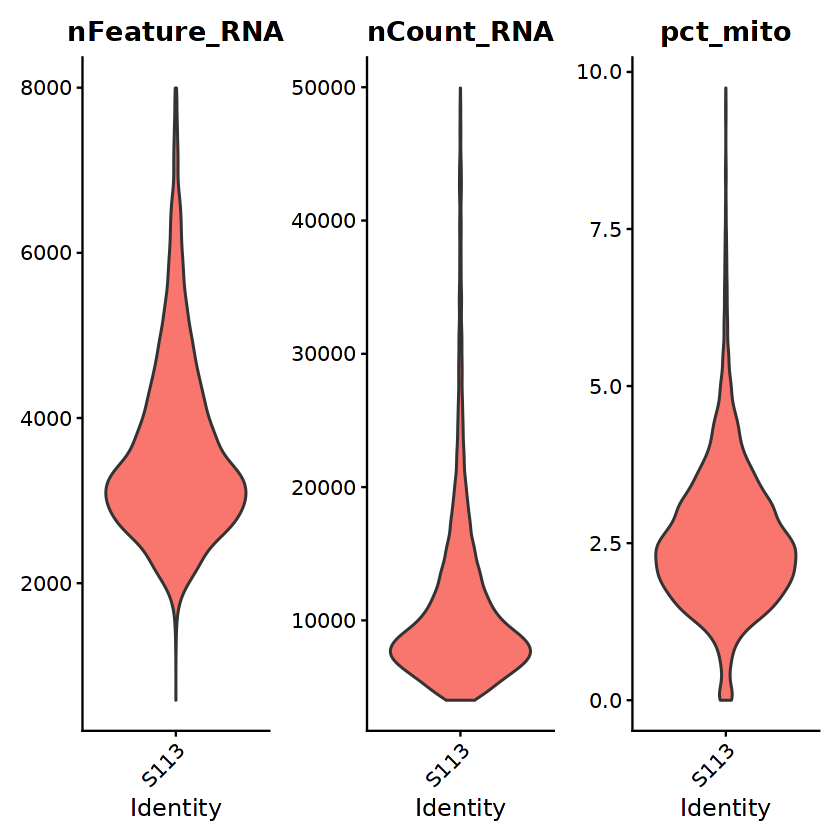

In [27]:
S113 <- subset(pcw4_6, idents = 'S113')

#Add metadata
S113 = RenameCells(S113, add.cell.id = 'S113')
S113$modality = 'expression' 
S113$dataset = 'ma_S113'
S113$pcw = '4'
S113$cellsource = 'fetal'
S113$gender = 'female'

#QC filtering
S113[['pct_mito']] = PercentageFeatureSet(S113, pattern = '^MT-')
VlnPlot(S113, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

S113 <- subset(S113, subset = nFeature_RNA > 200 & nFeature_RNA < 8000 & pct_mito < 10)
VlnPlot(S113, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(S113)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
S113 = subset(S113, features = anti_mt_genes)

S113

#Save Checkpoint
saveRDS(S113, file='checkpoints/Fetal/RNA_datasets/ma_S113.rds')
rm(S113)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


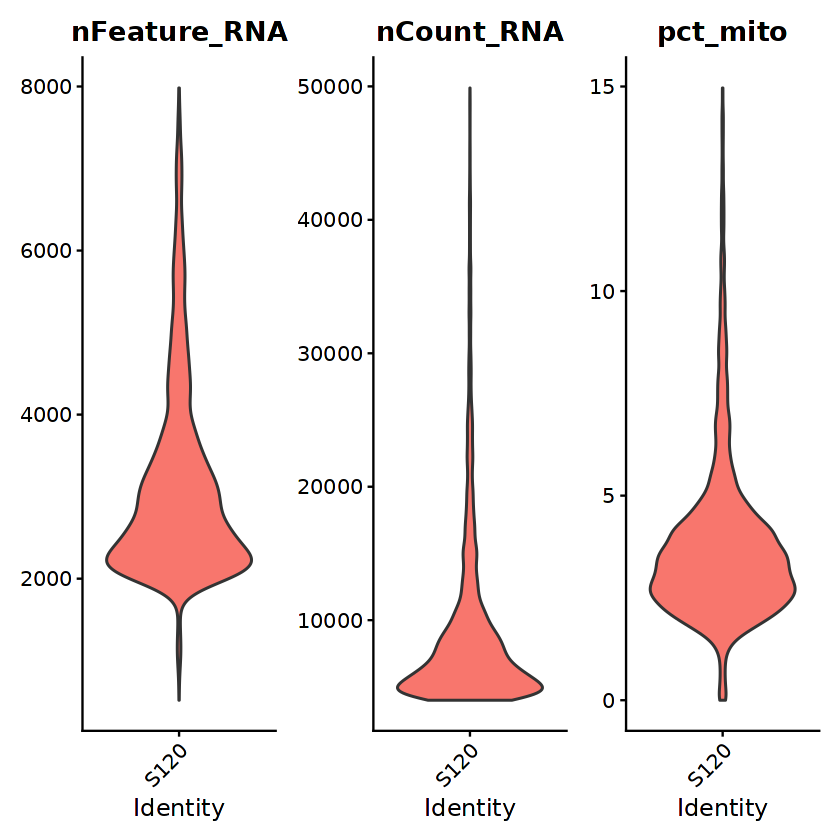

An object of class Seurat 
23650 features across 7196 samples within 1 assay 
Active assay: RNA (23650 features, 0 variable features)
 1 layer present: counts

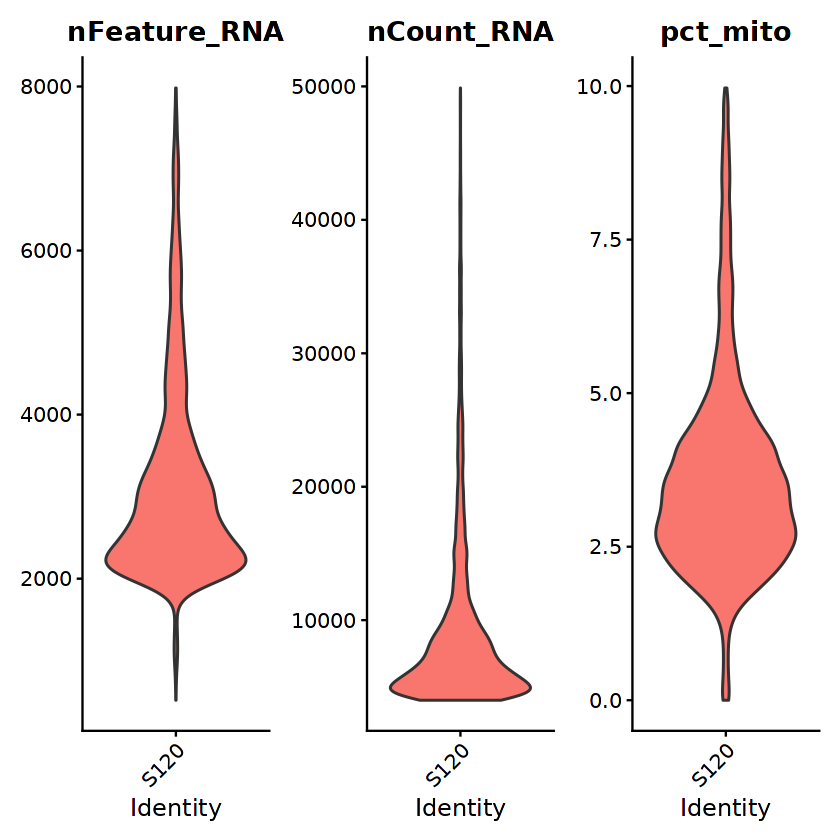

In [28]:
S120 <- subset(pcw7_11, idents = 'S120')

#Add metadata
S120 = RenameCells(S120, add.cell.id = 'S120')
S120$modality = 'expression' 
S120$dataset = 'ma_S120'
S120$pcw = '7'
S120$cellsource = 'fetal'
S120$gender = 'male'

#QC filtering
S120[['pct_mito']] = PercentageFeatureSet(S120, pattern = '^MT-')
VlnPlot(S120, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

S120 <- subset(S120, subset = nFeature_RNA > 200 & nFeature_RNA < 8000 & pct_mito < 10)
VlnPlot(S120, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(S120)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
S120 = subset(S120, features = anti_mt_genes)

S120

#Save Checkpoint
saveRDS(S120, file='checkpoints/Fetal/RNA_datasets/ma_S120.rds')
rm(S120)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


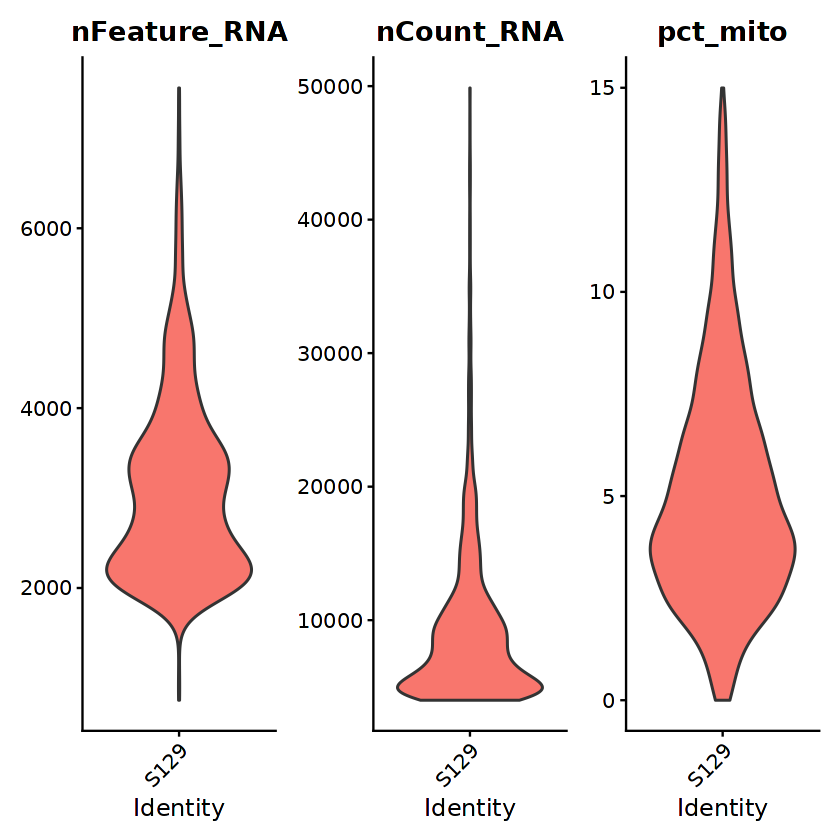

An object of class Seurat 
23650 features across 2648 samples within 1 assay 
Active assay: RNA (23650 features, 0 variable features)
 1 layer present: counts

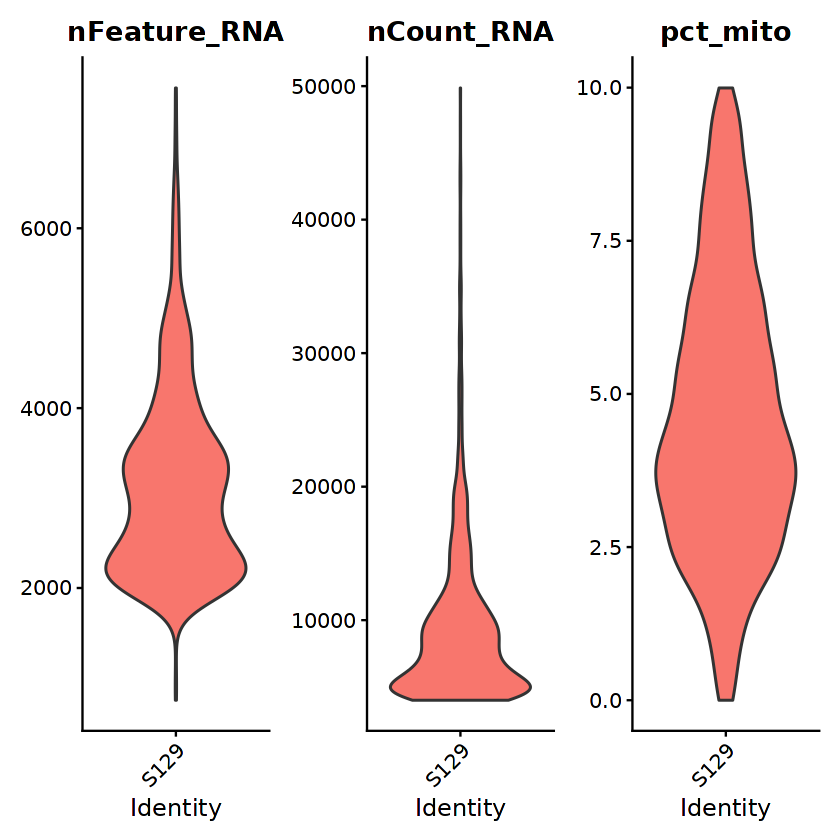

In [29]:
S129 <- subset(pcw7_11, idents = 'S129')

#Add metadata
S129 = RenameCells(S129, add.cell.id = 'S129')
S129$modality = 'expression' 
S129$dataset = 'ma_S129'
S129$pcw = '7'
S129$cellsource = 'fetal'
S129$gender = 'female'

#QC filtering
S129[['pct_mito']] = PercentageFeatureSet(S129, pattern = '^MT-')
VlnPlot(S129, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

S129 <- subset(S129, subset = nFeature_RNA > 200 & nFeature_RNA < 8000 & pct_mito < 10)
VlnPlot(S129, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(S129)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
S129 = subset(S129, features = anti_mt_genes)

S129

#Save Checkpoint
saveRDS(S129, file='checkpoints/Fetal/RNA_datasets/ma_S129.rds')
rm(S129)

In [30]:
rm(pcw4_6,pcw7_11)

## Xu et al

In [31]:
#Load raw data
cells <- fread('rawdata/RNA/fetal/Xu_fetal/cell_annotate.txt')
cells$barcode <- make.unique(cells$barcode)
cells <- data.frame(cells, row.names=cells$barcode)
cells <- cells[,!names(cells) == 'barcode']

genes <- as.data.frame(fread('rawdata/RNA/fetal/Xu_fetal/gene_annotate.txt'))

counts <- Matrix::readMM('rawdata/RNA/fetal/Xu_fetal/raw_counts.mtx')
rownames(counts) <- make.unique(genes$gene_short_name)
colnames(counts) <- rownames(cells)

#note: total number of embryo samples = 7

#Create Seurat object
xu.rna <- CreateSeuratObject(counts = counts, assay = 'RNA', meta.data = cells, min.cells = 10, min.features = 200)
Idents(xu.rna) <- 'embryo'

#Remove non-endoderm lineages (from Xu dataset)
Idents(xu.rna) <- 'developmental.system'
to.remove <- levels(xu.rna)[!(levels(xu.rna) %in% 'endoderm')]
xu.rna <- subset(x = xu.rna, idents = to.remove, invert = TRUE)

#Remove embryo 6 because low cell number
Idents(xu.rna) <- 'embryo'
xu.rna <- subset(x = xu.rna, idents = 'emb6', invert = TRUE)

saveRDS(xu.rna, file='checkpoints/Fetal/Xu_RNA.rds')
rm(cells,genes,counts)

Warning message:
“Data is of class dgTMatrix. Coercing to dgCMatrix.”


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


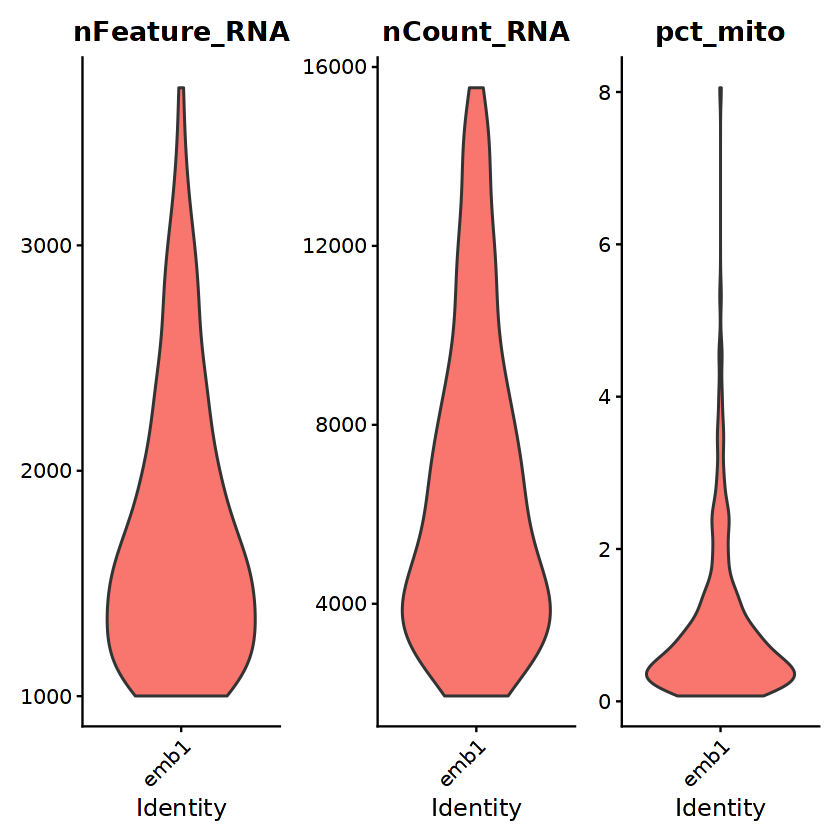

An object of class Seurat 
24713 features across 236 samples within 1 assay 
Active assay: RNA (24713 features, 0 variable features)
 1 layer present: counts

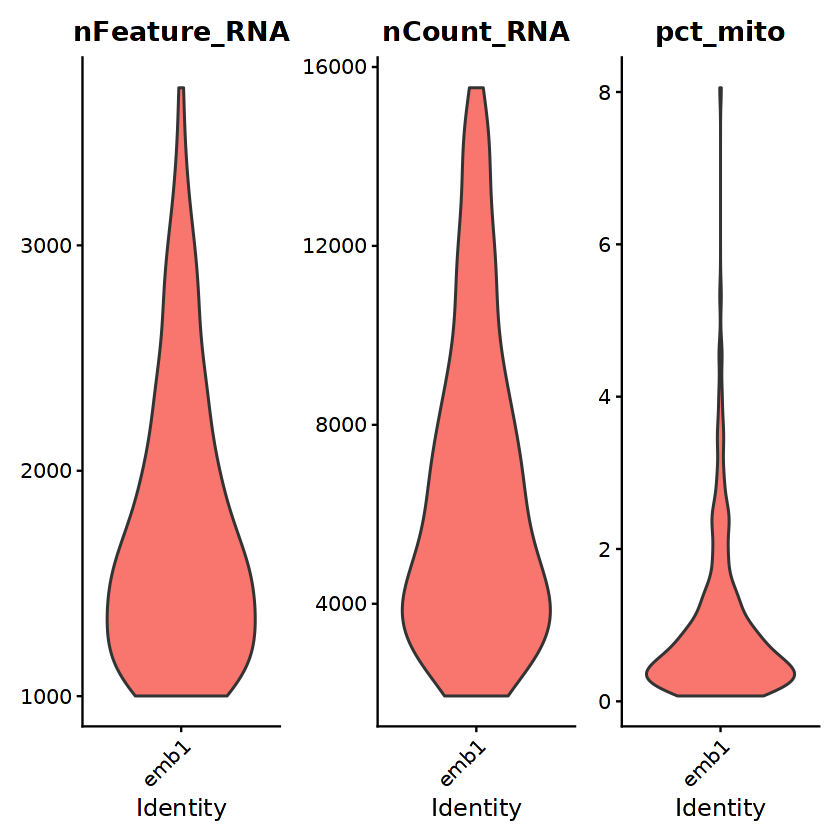

In [32]:
emb1 <- subset(xu.rna, idents = 'emb1')

#Add metadata
emb1 = RenameCells(emb1, add.cell.id = 'emb1')
emb1$modality = 'expression' 
emb1$dataset = 'xu_emb1'
emb1$pcw = '4'
emb1$cellsource = 'fetal'
emb1$gender = 'und'

#QC filtering
emb1[['pct_mito']] = PercentageFeatureSet(emb1, pattern = '^MT-')
VlnPlot(emb1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

emb1 <- subset(emb1, subset = nFeature_RNA > 200 & nFeature_RNA < 4000 & pct_mito < 10)
VlnPlot(emb1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(emb1)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
emb1 = subset(emb1, features = anti_mt_genes)

emb1

#Save Checkpoint
saveRDS(emb1, file='checkpoints/Fetal/RNA_datasets/xu_emb1.rds')
rm(emb1)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


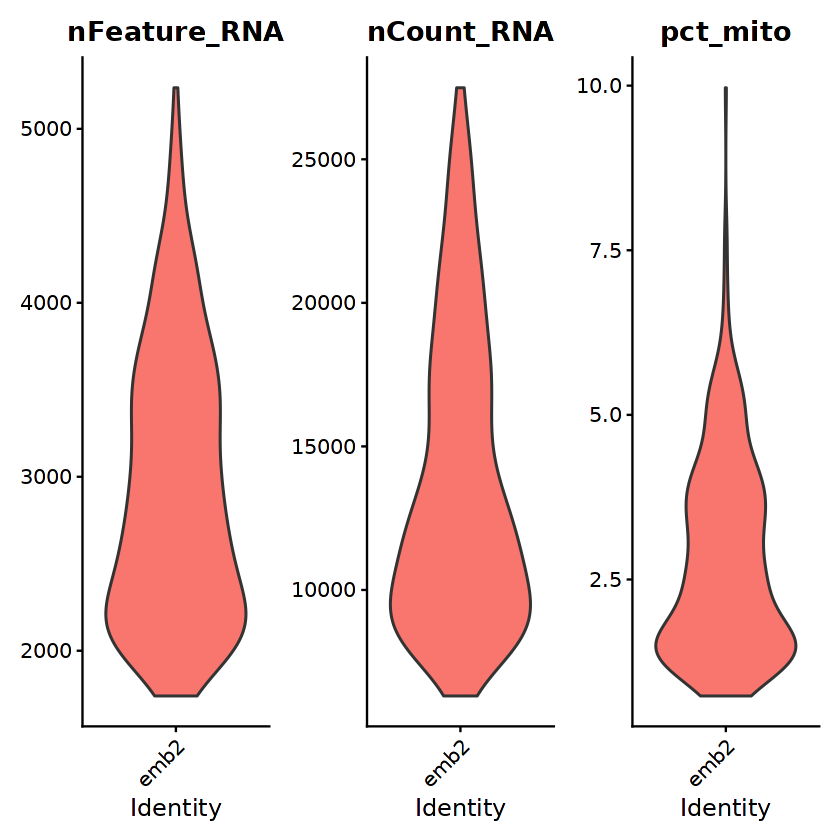

An object of class Seurat 
24713 features across 389 samples within 1 assay 
Active assay: RNA (24713 features, 0 variable features)
 1 layer present: counts

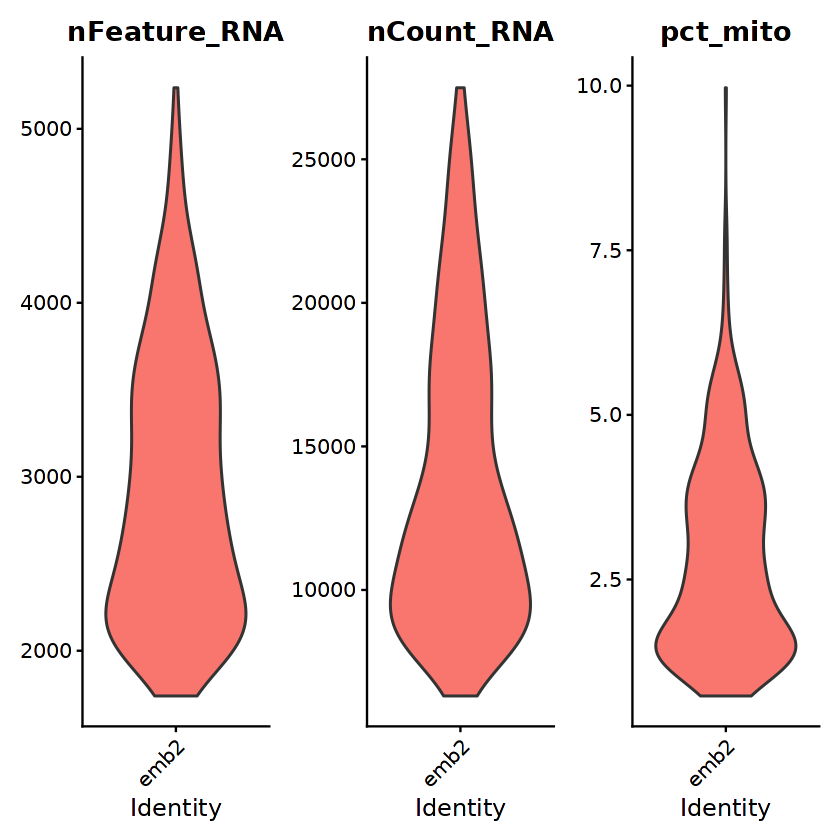

In [33]:
emb2 <- subset(xu.rna, idents = 'emb2')

#Add metadata
emb2 = RenameCells(emb2, add.cell.id = 'emb2')
emb2$modality = 'expression' 
emb2$dataset = 'xu_emb2'
emb2$pcw = '5'
emb2$cellsource = 'fetal'
emb2$gender = 'und'

#QC filtering
emb2[['pct_mito']] = PercentageFeatureSet(emb2, pattern = '^MT-')
VlnPlot(emb2, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

emb2 <- subset(emb2, subset = nFeature_RNA > 200 & nFeature_RNA < 6000 & pct_mito < 10)
VlnPlot(emb2, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(emb2)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
emb2 = subset(emb2, features = anti_mt_genes)

emb2

#Save Checkpoint
saveRDS(emb2, file='checkpoints/Fetal/RNA_datasets/xu_emb2.rds')
rm(emb2)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


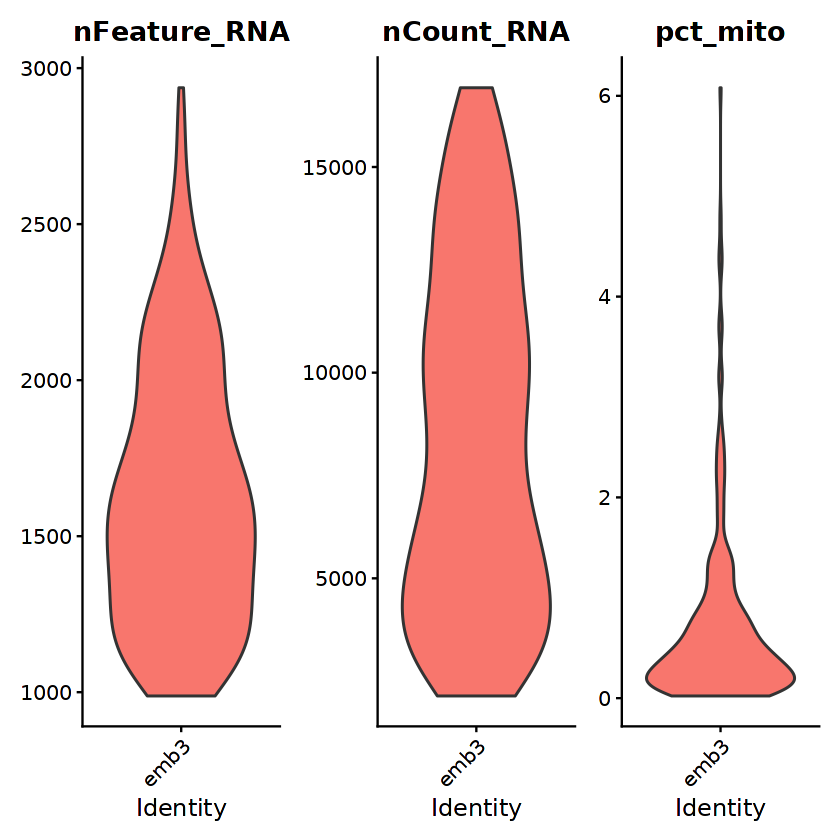

An object of class Seurat 
24713 features across 319 samples within 1 assay 
Active assay: RNA (24713 features, 0 variable features)
 1 layer present: counts

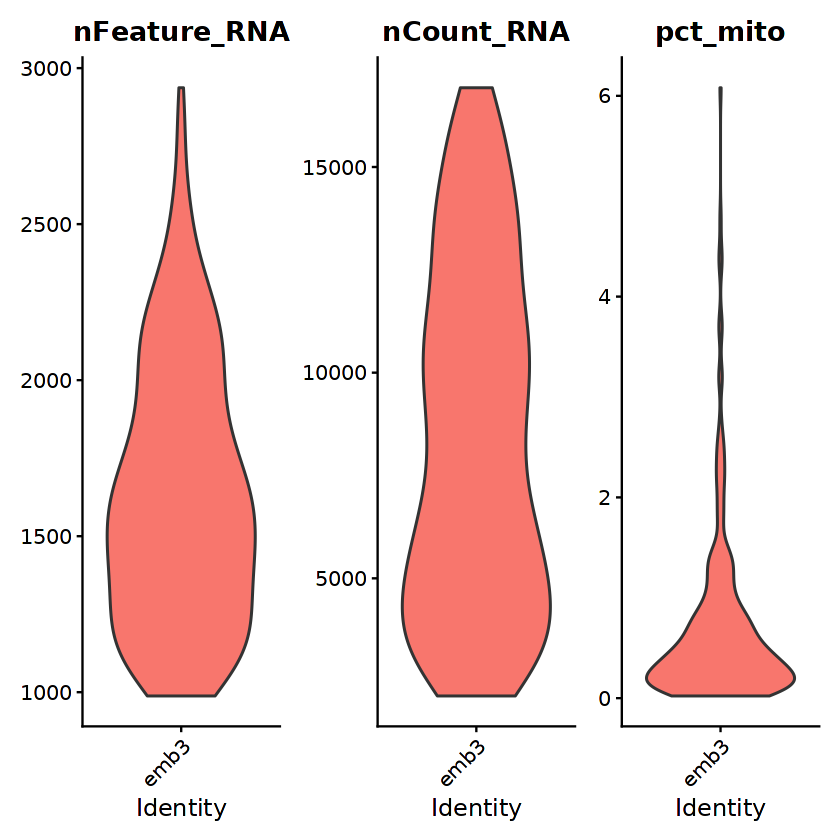

In [34]:
emb3 <- subset(xu.rna, idents = 'emb3')

#Add metadata
emb3 = RenameCells(emb3, add.cell.id = 'emb3')
emb3$modality = 'expression' 
emb3$dataset = 'xu_emb3'
emb3$pcw = '5'
emb3$cellsource = 'fetal'
emb3$gender = 'und'

#QC filtering
emb3[['pct_mito']] = PercentageFeatureSet(emb3, pattern = '^MT-')
VlnPlot(emb3, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

emb3 <- subset(emb3, subset = nFeature_RNA > 200 & nFeature_RNA < 3000 & pct_mito < 10)
VlnPlot(emb3, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(emb3)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
emb3 = subset(emb3, features = anti_mt_genes)

emb3

#Save Checkpoint
saveRDS(emb3, file='checkpoints/Fetal/RNA_datasets/xu_emb3.rds')
rm(emb3)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


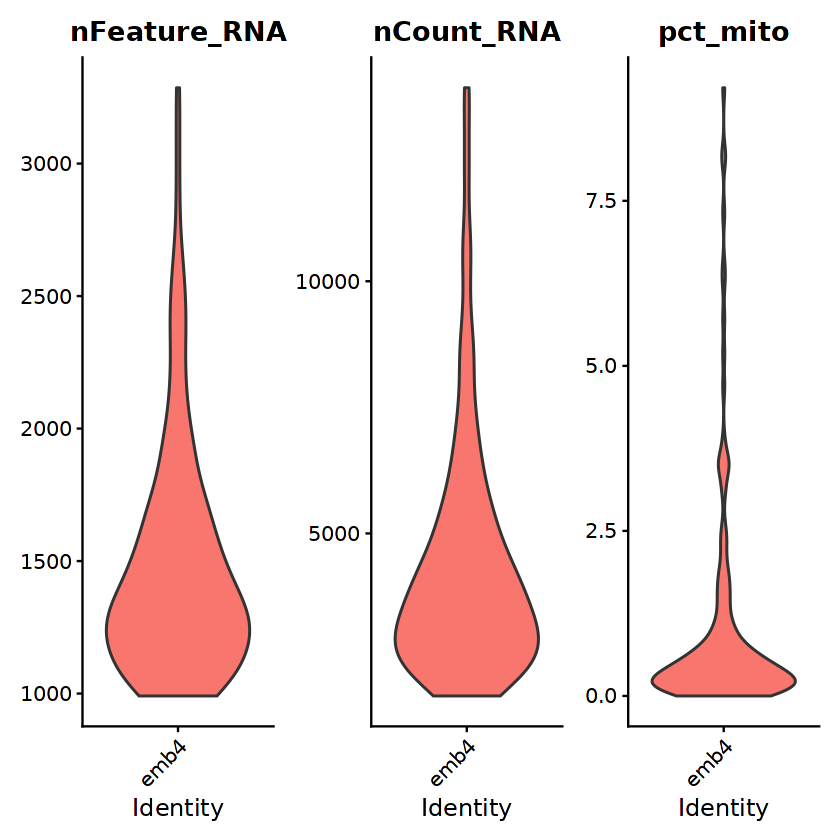

An object of class Seurat 
24713 features across 155 samples within 1 assay 
Active assay: RNA (24713 features, 0 variable features)
 1 layer present: counts

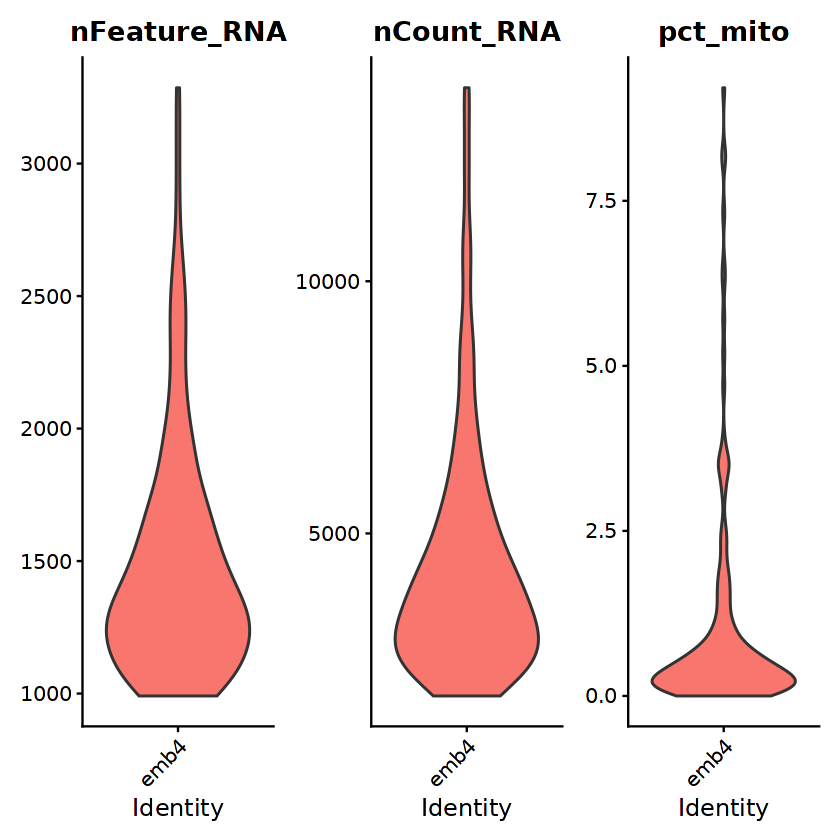

In [35]:
emb4 <- subset(xu.rna, idents = 'emb4')

#Add metadata
emb4 = RenameCells(emb4, add.cell.id = 'emb4')
emb4$modality = 'expression' 
emb4$dataset = 'xu_emb4'
emb4$pcw = '5'
emb4$cellsource = 'fetal'
emb4$gender = 'und'

#QC filtering
emb4[['pct_mito']] = PercentageFeatureSet(emb4, pattern = '^MT-')
VlnPlot(emb4, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

emb4 <- subset(emb4, subset = nFeature_RNA > 200 & nFeature_RNA < 4000 & pct_mito < 10)
VlnPlot(emb4, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(emb4)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
emb4 = subset(emb4, features = anti_mt_genes)

emb4

#Save Checkpoint
saveRDS(emb4, file='checkpoints/Fetal/RNA_datasets/xu_emb4.rds')
rm(emb4)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


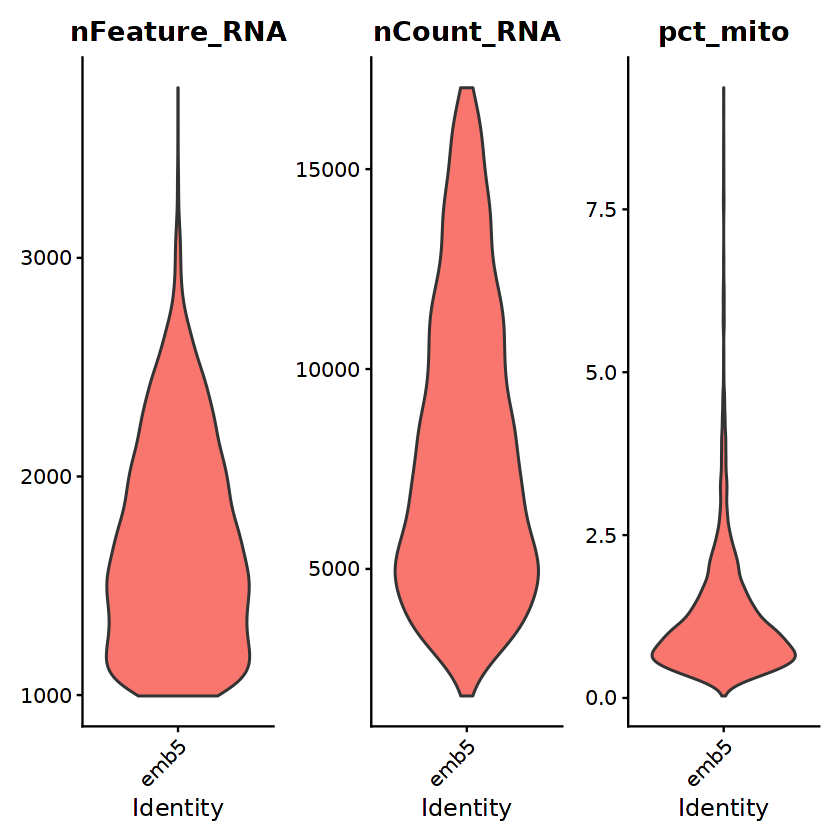

An object of class Seurat 
24713 features across 2964 samples within 1 assay 
Active assay: RNA (24713 features, 0 variable features)
 1 layer present: counts

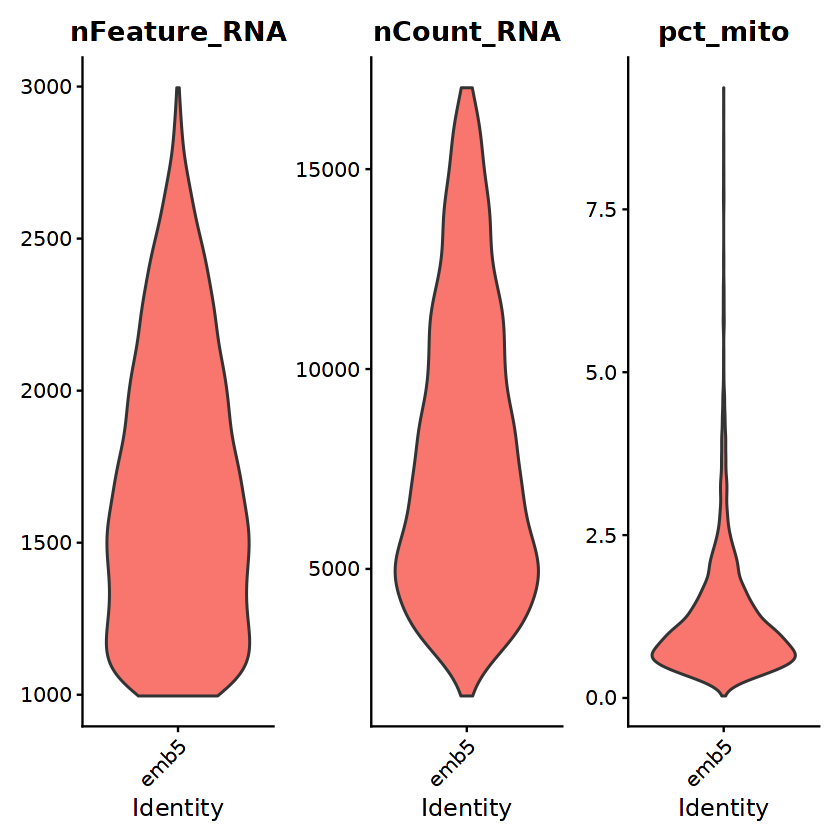

In [36]:
emb5 <- subset(xu.rna, idents = 'emb5')

#Add metadata
emb5 = RenameCells(emb5, add.cell.id = 'emb5')
emb5$modality = 'expression' 
emb5$dataset = 'xu_emb5'
emb5$pcw = '6'
emb5$cellsource = 'fetal'
emb5$gender = 'und'

#QC filtering
emb5[['pct_mito']] = PercentageFeatureSet(emb5, pattern = '^MT-')
VlnPlot(emb5, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

emb5 <- subset(emb5, subset = nFeature_RNA > 200 & nFeature_RNA < 3000 & pct_mito < 10)
VlnPlot(emb5, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(emb5)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
emb5 = subset(emb5, features = anti_mt_genes)

emb5

#Save Checkpoint
saveRDS(emb5, file='checkpoints/Fetal/RNA_datasets/xu_emb5.rds')
rm(emb5)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


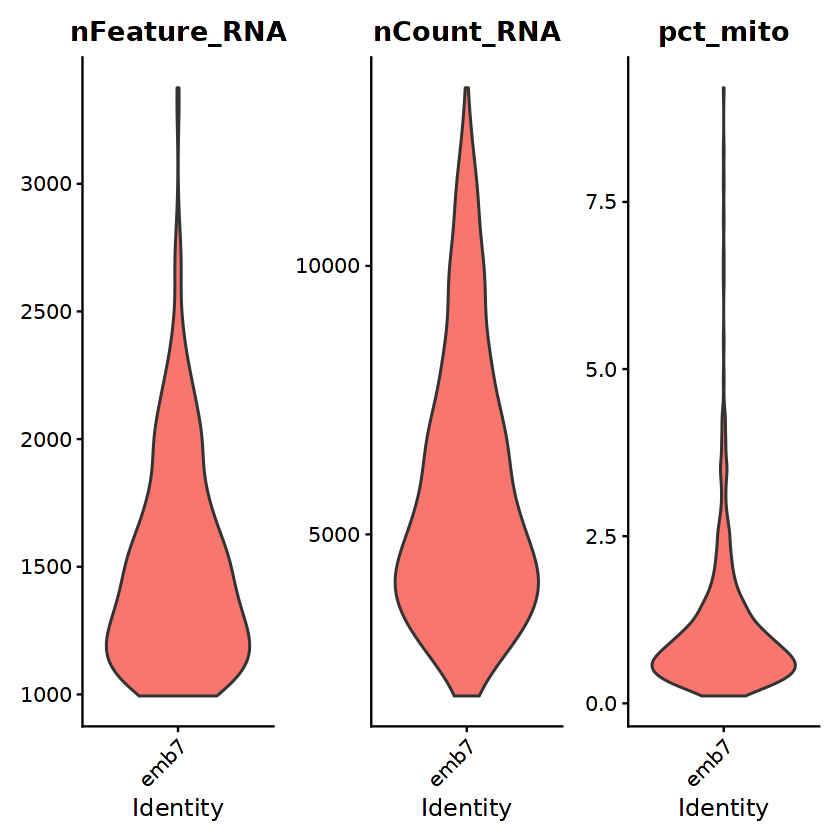

An object of class Seurat 
24713 features across 589 samples within 1 assay 
Active assay: RNA (24713 features, 0 variable features)
 1 layer present: counts

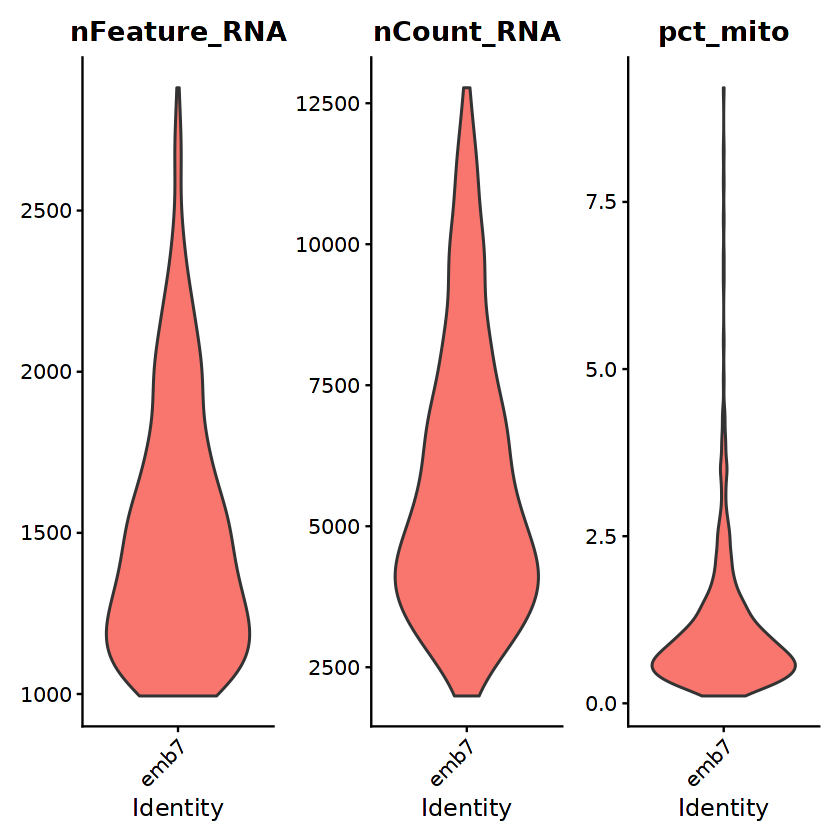

In [37]:
emb7 <- subset(xu.rna, idents = 'emb7')

#Add metadata
emb7 = RenameCells(emb7, add.cell.id = 'emb7')
emb7$modality = 'expression' 
emb7$dataset = 'xu_emb7'
emb7$pcw = '6'
emb7$cellsource = 'fetal'
emb7$gender = 'und'

#QC filtering
emb7[['pct_mito']] = PercentageFeatureSet(emb7, pattern = '^MT-')
VlnPlot(emb7, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

emb7 <- subset(emb7, subset = nFeature_RNA > 200 & nFeature_RNA < 3000 & pct_mito < 10)
VlnPlot(emb7, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(emb7)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
emb7 = subset(emb7, features = anti_mt_genes)

emb7

#Save Checkpoint
saveRDS(emb7, file='checkpoints/Fetal/RNA_datasets/xu_emb7.rds')
rm(emb7)

In [38]:
rm(xu.rna)

## Yu et al

In [39]:
#Load raw counts
counts.10x <- as.matrix(fread('rawdata/RNA/fetal/Yu_fetal/Human_10x_UMI.txt'), rownames=1)

counts.mstr <- as.matrix(fread('rawdata/RNA/fetal/Yu_fetal/Human_mSTRTSeq_UMI.txt'), rownames=2)
counts.mstr<-counts.mstr[,-1]
rownames(counts.mstr) <- make.unique(rownames(counts.mstr))

#note: total number of embryo samples = 30

#Create Seurat object
yu.10x <- CreateSeuratObject(counts = counts.10x, min.cells = 10, min.features = 500)
yu.mstr <- CreateSeuratObject(counts = counts.mstr)

saveRDS(yu.10x, file='checkpoints/Fetal/Yu_RNA_10x.rds')
saveRDS(yu.mstr, file='checkpoints/Fetal/Yu_RNA_mstr.rds')
rm(counts.10x, counts.mstr)

Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


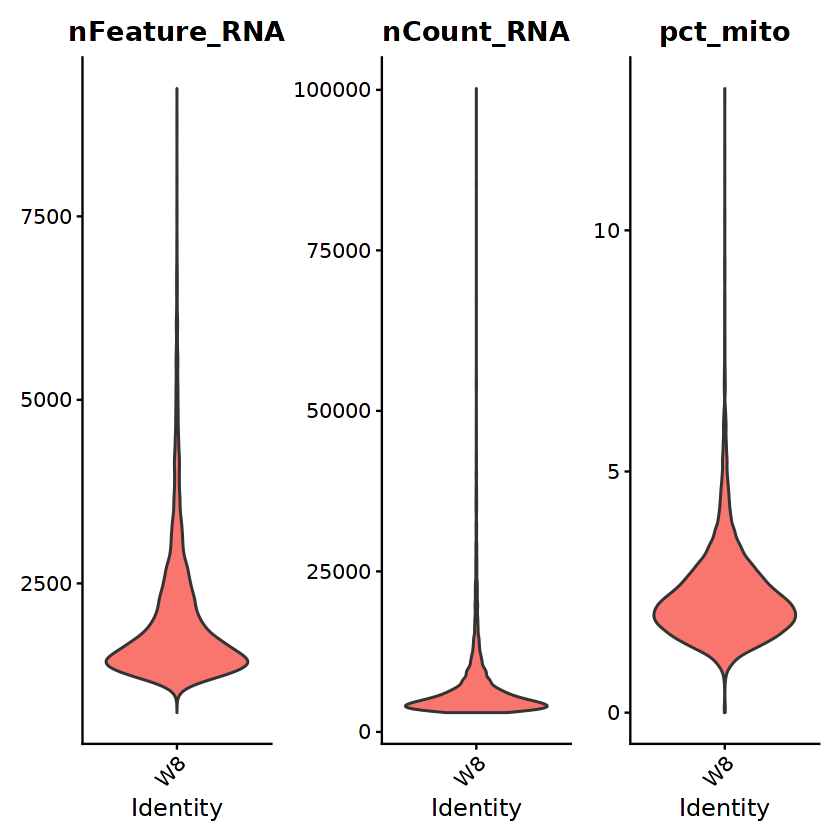

An object of class Seurat 
21932 features across 8110 samples within 1 assay 
Active assay: RNA (21932 features, 0 variable features)
 1 layer present: counts

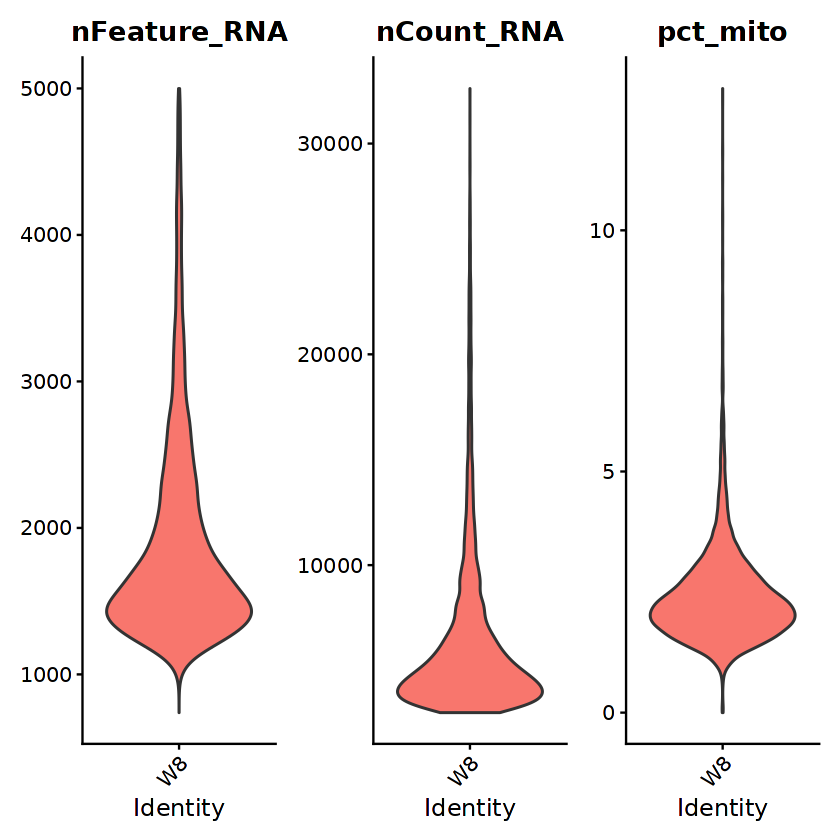

In [40]:
W8 <- subset(yu.10x, idents = 'W8')

#Add metadata
W8 = RenameCells(W8, add.cell.id = 'W8')
W8$modality = 'expression' 
W8$dataset = 'yu_W8'
W8$pcw = '8'
W8$cellsource = 'fetal'
W8$gender = 'male'

#QC filtering
W8[['pct_mito']] = PercentageFeatureSet(W8, pattern = '^MT-')
VlnPlot(W8, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

W8 <- subset(W8, subset = nFeature_RNA > 500 & nFeature_RNA < 5000 & pct_mito < 20 & nCount_RNA > 3000)
VlnPlot(W8, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(W8)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
W8 = subset(W8, features = anti_mt_genes)

W8

#Save Checkpoint
saveRDS(W8, file='checkpoints/Fetal/RNA_datasets/yu_W8.rds')
rm(W8)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


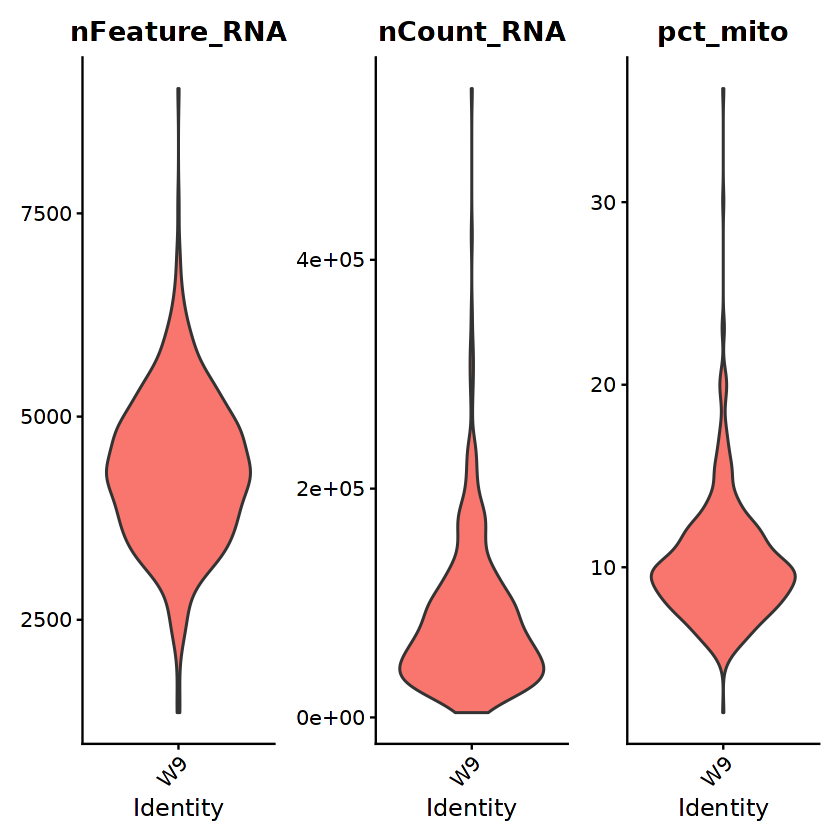

An object of class Seurat 
63217 features across 442 samples within 1 assay 
Active assay: RNA (63217 features, 0 variable features)
 1 layer present: counts

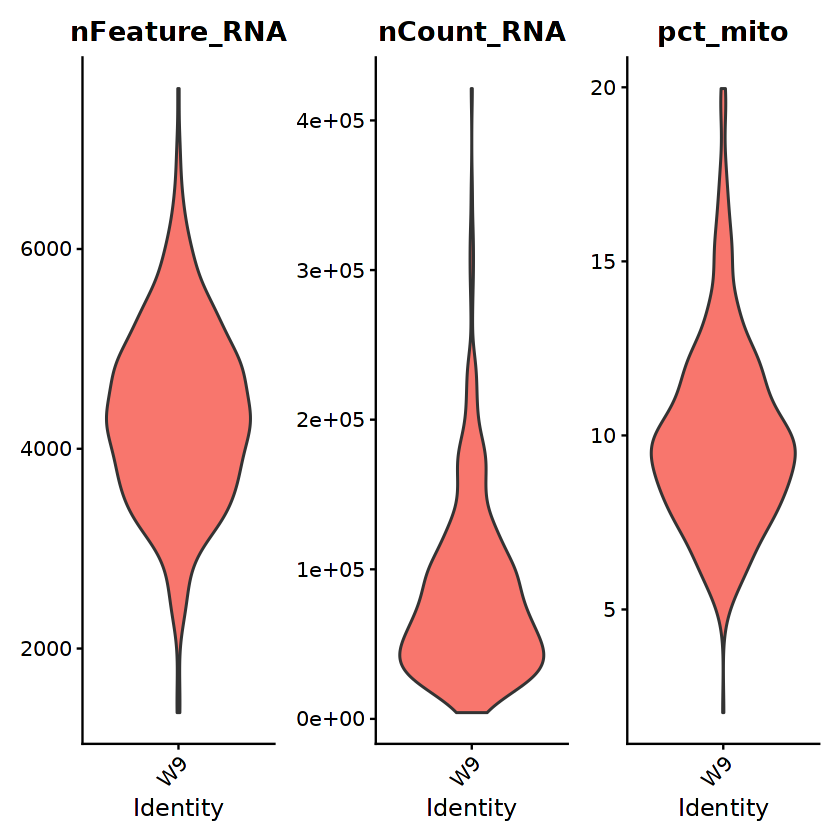

In [41]:
W9 <- subset(yu.mstr, idents = 'W9')

#Add metadata
W9 = RenameCells(W9, add.cell.id = 'W9')
W9$modality = 'expression' 
W9$dataset = 'yu_W9'
W9$pcw = '9'
W9$cellsource = 'fetal'
W9$gender = 'und'

#QC filtering
W9[['pct_mito']] = PercentageFeatureSet(W9, pattern = '^MT-')
VlnPlot(W9, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

W9 <- subset(W9, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20 & nCount_RNA > 3000)
VlnPlot(W9, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(W9)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
W9 = subset(W9, features = anti_mt_genes)

W9

#Save Checkpoint
saveRDS(W9, file='checkpoints/Fetal/RNA_datasets/yu_W9.rds')
rm(W9)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


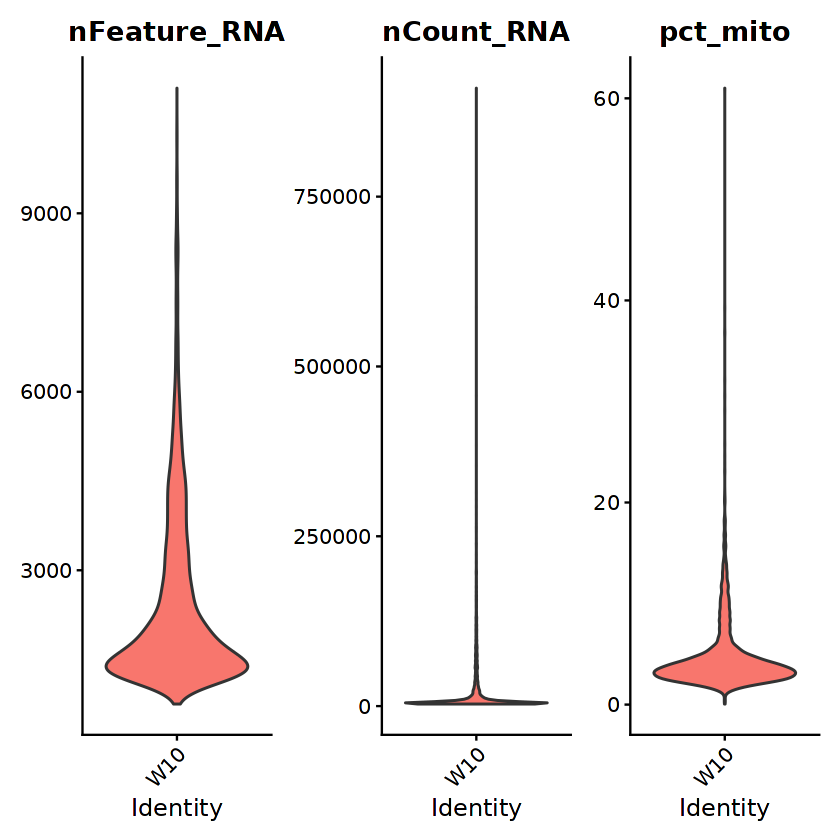

An object of class Seurat 
63373 features across 5905 samples within 1 assay 
Active assay: RNA (63373 features, 0 variable features)
 2 layers present: counts.1, counts.2

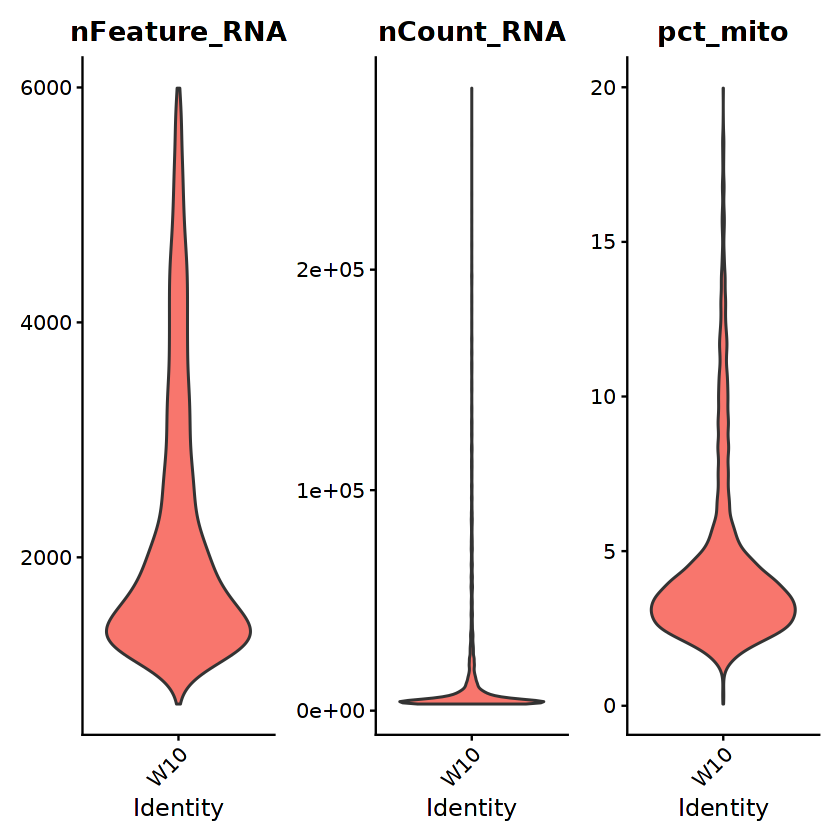

In [42]:
W10_10x <- subset(yu.10x, idents = 'W10')
W10_10x$gender = 'female'

W10_mstr <- subset(yu.mstr, idents = 'W10')
W10_mstr$gender = 'und'

W10 <- merge(W10_10x, W10_mstr)

#Add metadata
W10 = RenameCells(W10, add.cell.id = 'W10')
W10$modality = 'expression' 
W10$dataset = 'yu_W10'
W10$pcw = '10'
W10$cellsource = 'fetal'
W10$gender = 'und'

#QC filtering
W10[['pct_mito']] = PercentageFeatureSet(W10, pattern = '^MT-')
VlnPlot(W10, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

W10 <- subset(W10, subset = nFeature_RNA > 500 & nFeature_RNA < 6000 & pct_mito < 20 & nCount_RNA > 3000)
VlnPlot(W10, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(W10)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
W10 = subset(W10, features = anti_mt_genes)

W10

#Save Checkpoint
W10[["RNA"]] <- JoinLayers(W10[["RNA"]])
saveRDS(W10, file='checkpoints/Fetal/RNA_datasets/yu_W10.rds')
rm(W10, W10_10x, W10_mstr)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


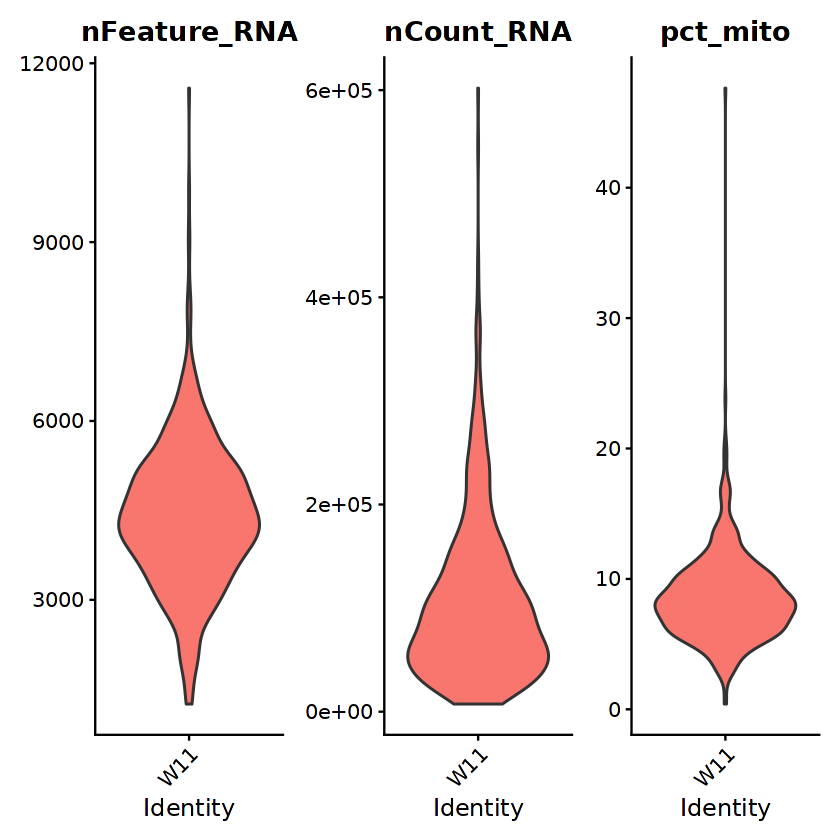

An object of class Seurat 
63217 features across 638 samples within 1 assay 
Active assay: RNA (63217 features, 0 variable features)
 1 layer present: counts

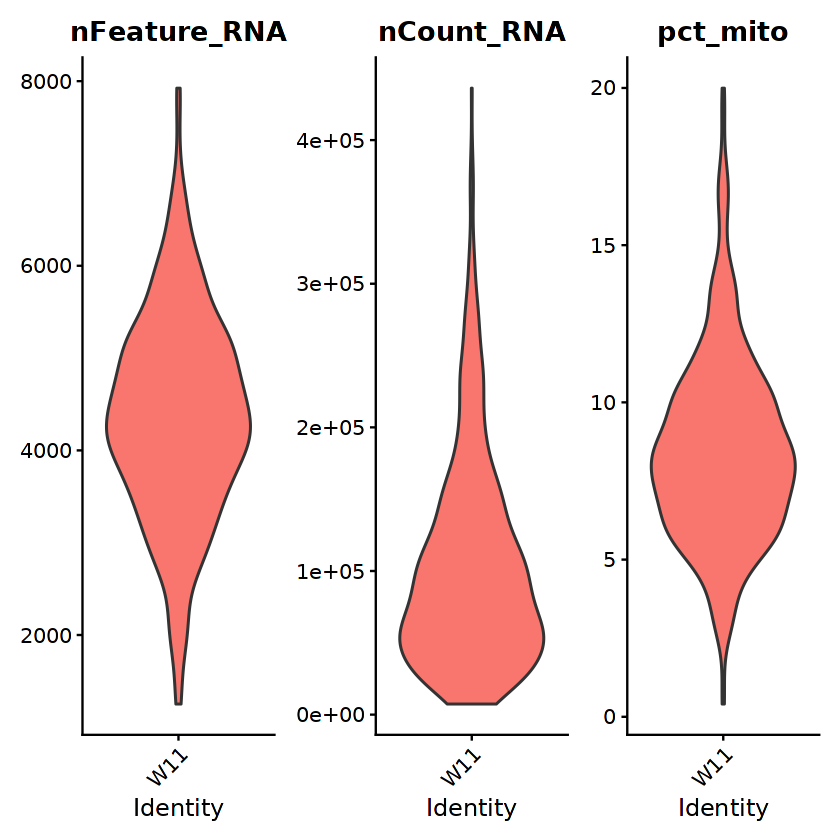

In [43]:
W11 <- subset(yu.mstr, idents = 'W11')

#Add metadata
W11 = RenameCells(W11, add.cell.id = 'W11')
W11$modality = 'expression' 
W11$dataset = 'yu_W11'
W11$pcw = '11'
W11$cellsource = 'fetal'
W11$gender = 'und'

#QC filtering
W11[['pct_mito']] = PercentageFeatureSet(W11, pattern = '^MT-')
VlnPlot(W11, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

W11 <- subset(W11, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20 & nCount_RNA > 3000)
VlnPlot(W11, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(W11)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
W11 = subset(W11, features = anti_mt_genes)

W11

#Save Checkpoint
saveRDS(W11, file='checkpoints/Fetal/RNA_datasets/yu_W11.rds')
rm(W11)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


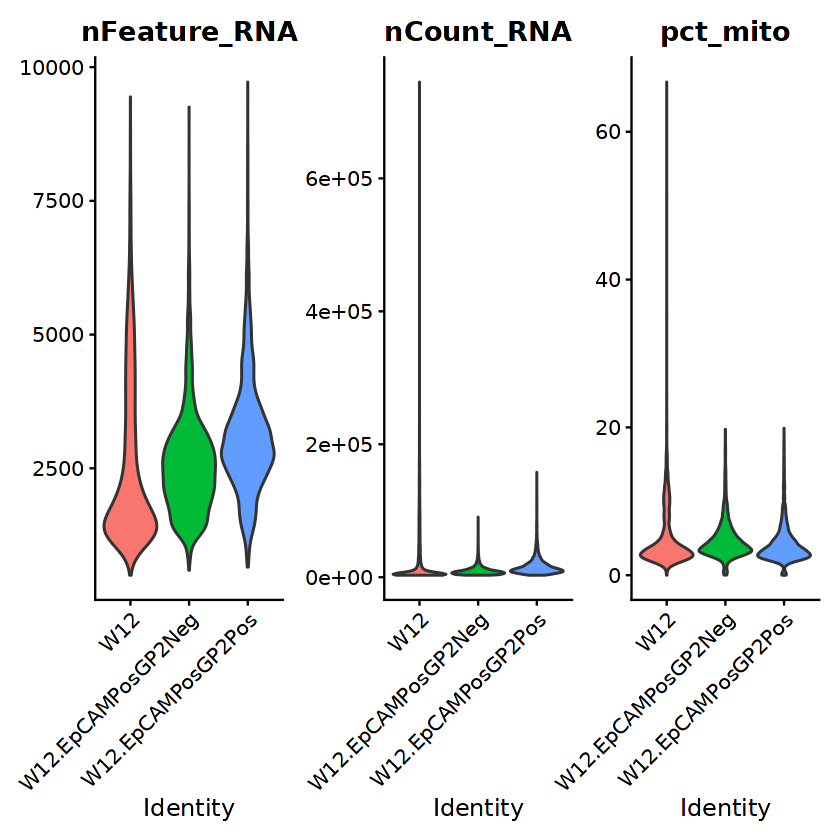

An object of class Seurat 
63373 features across 13618 samples within 1 assay 
Active assay: RNA (63373 features, 0 variable features)
 2 layers present: counts.1, counts.2

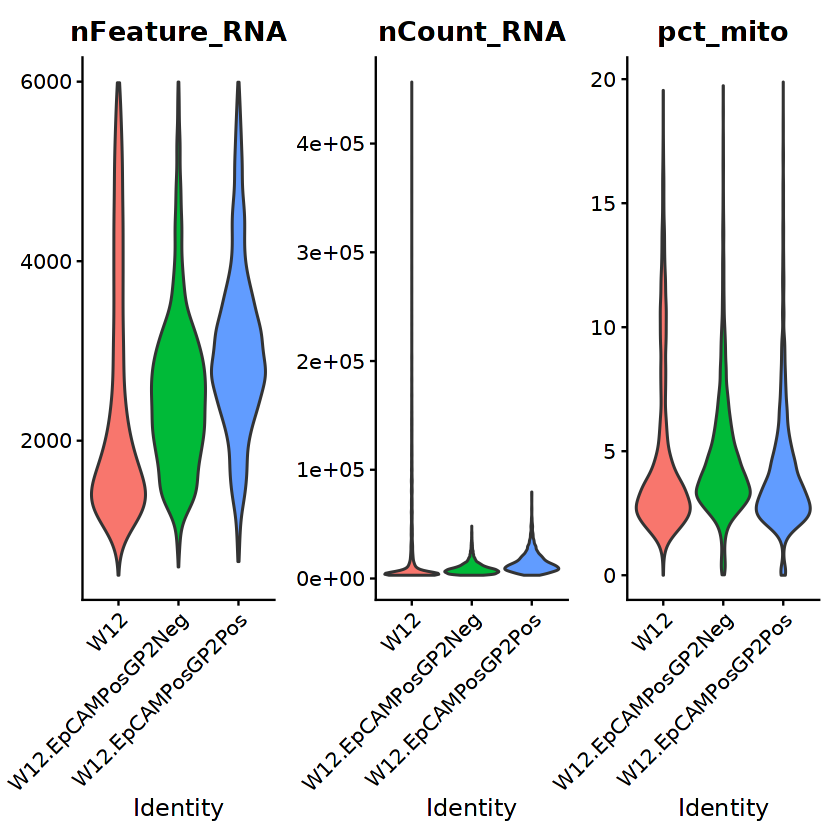

In [44]:
W12_10x <- subset(yu.10x, idents = c('W12','W12.EpCAMPosGP2Neg','W12.EpCAMPosGP2Pos'))
W12_mstr <- subset(yu.mstr, idents = 'W12')

W12 <- merge(W12_10x, W12_mstr)

#Add metadata
W12 = RenameCells(W12, add.cell.id = 'W12')
W12$modality = 'expression' 
W12$dataset = 'yu_W12'
W12$pcw = '12'
W12$cellsource = 'fetal'
W12$gender = 'und'

#QC filtering
W12[['pct_mito']] = PercentageFeatureSet(W12, pattern = '^MT-')
VlnPlot(W12, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

W12 <- subset(W12, subset = nFeature_RNA > 500 & nFeature_RNA < 6000 & pct_mito < 20 & nCount_RNA > 3000)
VlnPlot(W12, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(W12)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
W12 = subset(W12, features = anti_mt_genes)

W12

#Save Checkpoint
W12[["RNA"]] <- JoinLayers(W12[["RNA"]])
saveRDS(W12, file='checkpoints/Fetal/RNA_datasets/yu_W12.rds')
rm(W12,W12_10x,W12_mstr)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


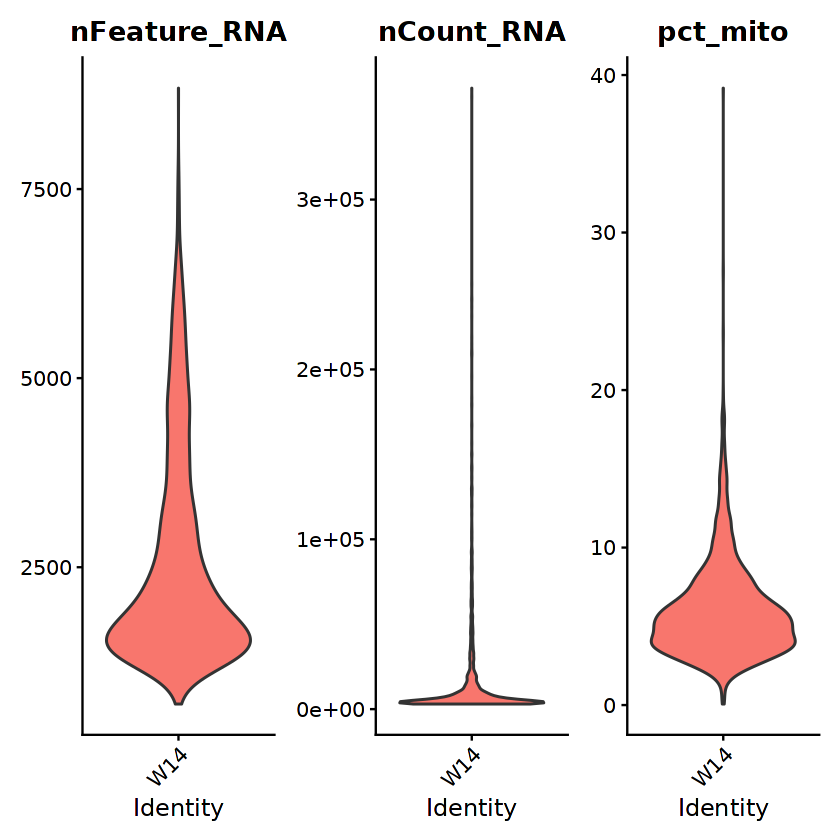

An object of class Seurat 
63373 features across 2912 samples within 1 assay 
Active assay: RNA (63373 features, 0 variable features)
 2 layers present: counts.1, counts.2

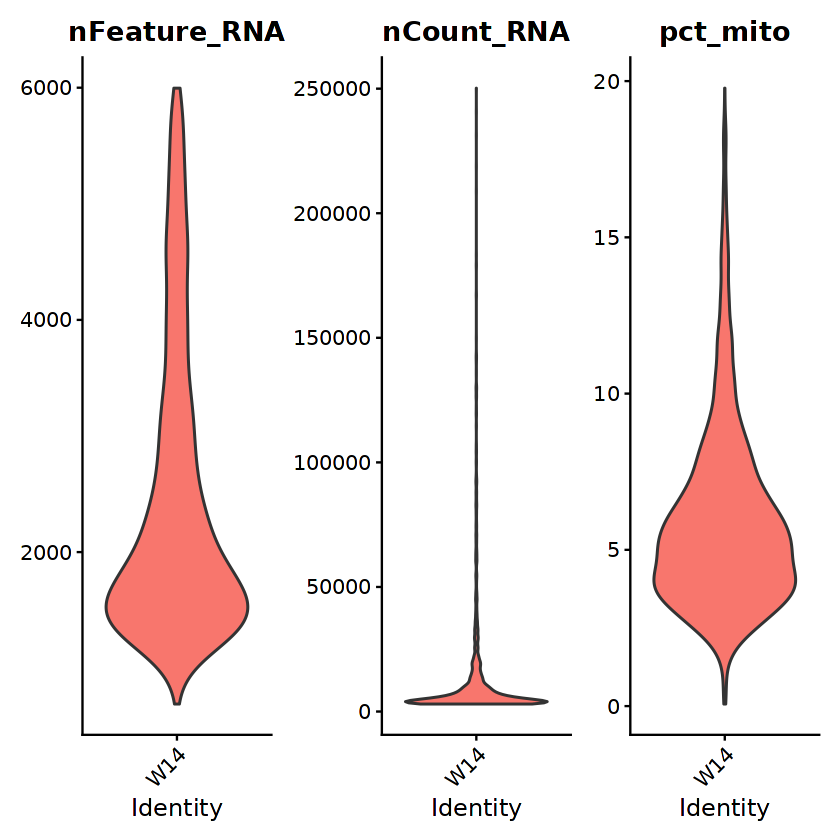

In [45]:
W14_10x <- subset(yu.10x, idents = 'W14')
W14_10x$gender = 'male'

W14_mstr <- subset(yu.mstr, idents = 'W14')
W14_mstr$gender = 'female'

W14 <- merge(W14_10x, W14_mstr)

#Add metadata
W14 = RenameCells(W14, add.cell.id = 'W14')
W14$modality = 'expression' 
W14$dataset = 'yu_W14'
W14$pcw = '14'
W14$cellsource = 'fetal'
W14$gender = 'und'

#QC filtering
W14[['pct_mito']] = PercentageFeatureSet(W14, pattern = '^MT-')
VlnPlot(W14, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

W14 <- subset(W14, subset = nFeature_RNA > 500 & nFeature_RNA < 6000 & pct_mito < 20 & nCount_RNA > 3000)
VlnPlot(W14, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(W14)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
W14 = subset(W14, features = anti_mt_genes)

W14

#Save Checkpoint
W14[["RNA"]] <- JoinLayers(W14[["RNA"]])
saveRDS(W14, file='checkpoints/Fetal/RNA_datasets/yu_W14.rds')
rm(W14,W14_10x,W14_mstr)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


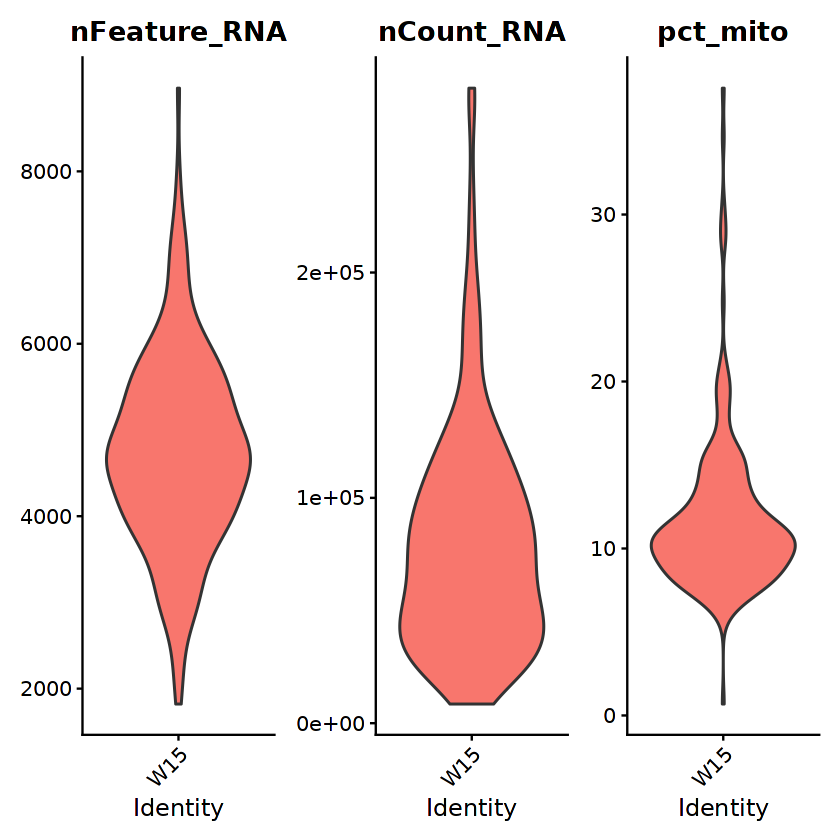

An object of class Seurat 
63217 features across 213 samples within 1 assay 
Active assay: RNA (63217 features, 0 variable features)
 1 layer present: counts

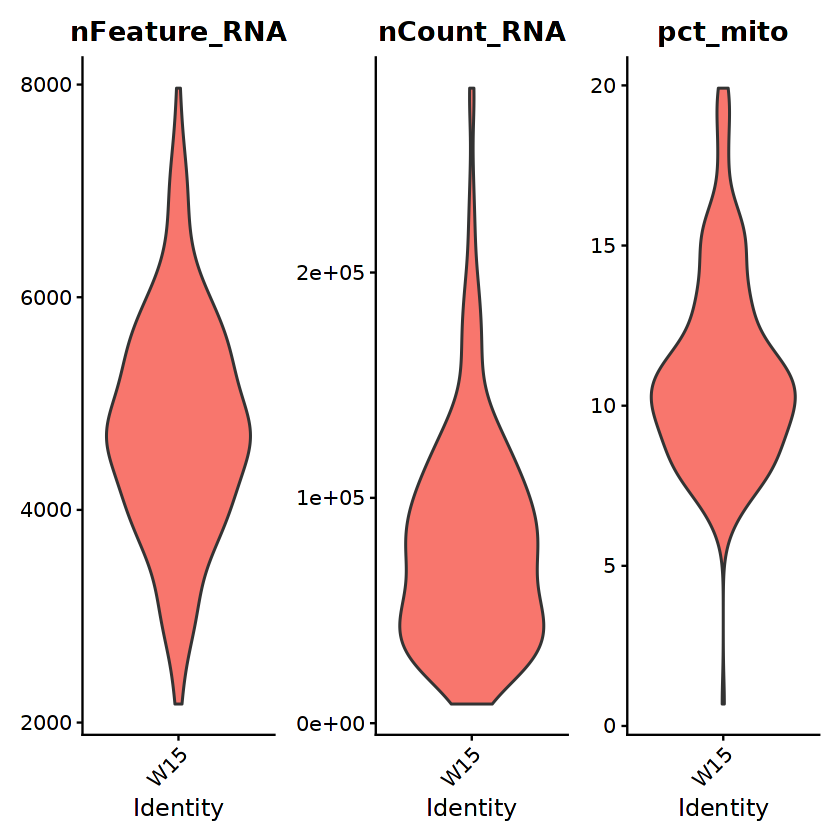

In [46]:
W15 <- subset(yu.mstr, idents = 'W15')

#Add metadata
W15 = RenameCells(W15, add.cell.id = 'W15')
W15$modality = 'expression' 
W15$dataset = 'yu_W15'
W15$pcw = '15'
W15$cellsource = 'fetal'
W15$gender = 'male'

#QC filtering
W15[['pct_mito']] = PercentageFeatureSet(W15, pattern = '^MT-')
VlnPlot(W15, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

W15 <- subset(W15, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20 & nCount_RNA > 3000)
VlnPlot(W15, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(W15)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
W15 = subset(W15, features = anti_mt_genes)

W15

#Save Checkpoint
saveRDS(W15, file='checkpoints/Fetal/RNA_datasets/yu_W15.rds')
rm(W15)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


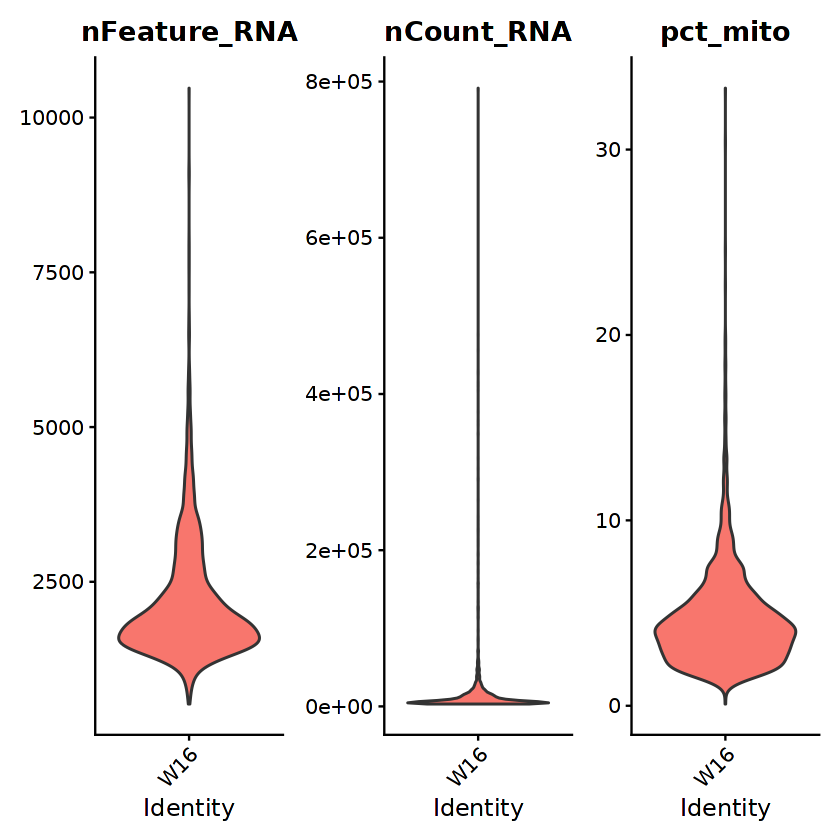

An object of class Seurat 
63373 features across 3636 samples within 1 assay 
Active assay: RNA (63373 features, 0 variable features)
 2 layers present: counts.1, counts.2

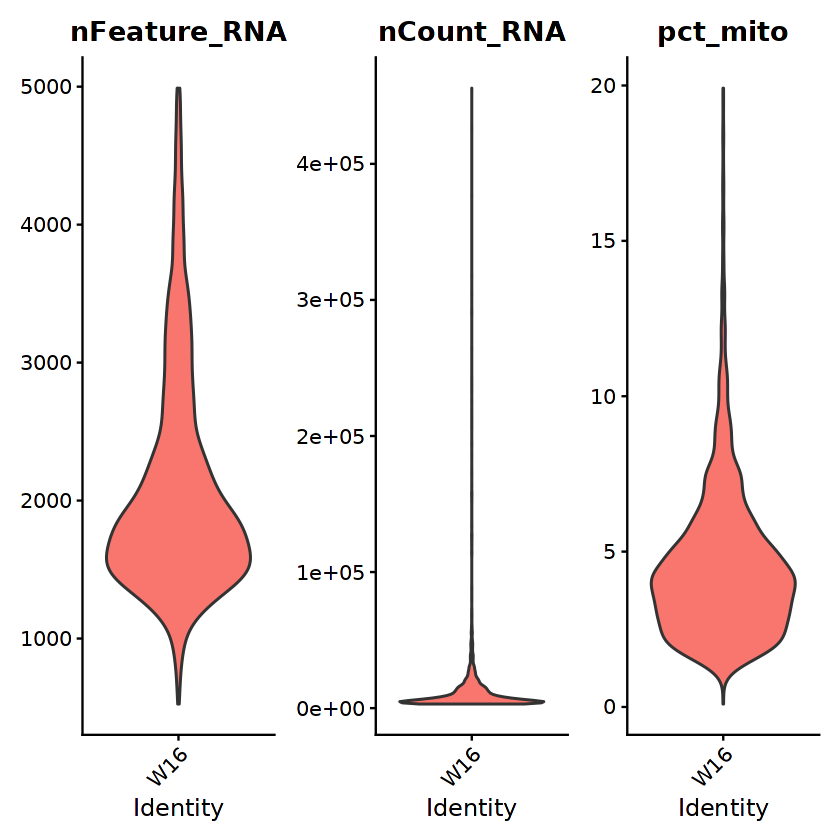

In [47]:
W16_10x <- subset(yu.10x, idents = 'W16')
W16_mstr <- subset(yu.mstr, idents = 'W16')

W16 <- merge(W16_10x, W16_mstr)

#Add metadata
W16 = RenameCells(W16, add.cell.id = 'W16')
W16$modality = 'expression' 
W16$dataset = 'yu_W16'
W16$pcw = '16'
W16$cellsource = 'fetal'
W16$gender = 'male'

#QC filtering
W16[['pct_mito']] = PercentageFeatureSet(W16, pattern = '^MT-')
VlnPlot(W16, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

W16 <- subset(W16, subset = nFeature_RNA > 500 & nFeature_RNA < 5000 & pct_mito < 20 & nCount_RNA > 3000)
VlnPlot(W16, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(W16)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
W16 = subset(W16, features = anti_mt_genes)

W16

#Save Checkpoint
W16[["RNA"]] <- JoinLayers(W16[["RNA"]])
saveRDS(W16, file='checkpoints/Fetal/RNA_datasets/yu_W16.rds')
rm(W16,W16_10x,W16_mstr)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


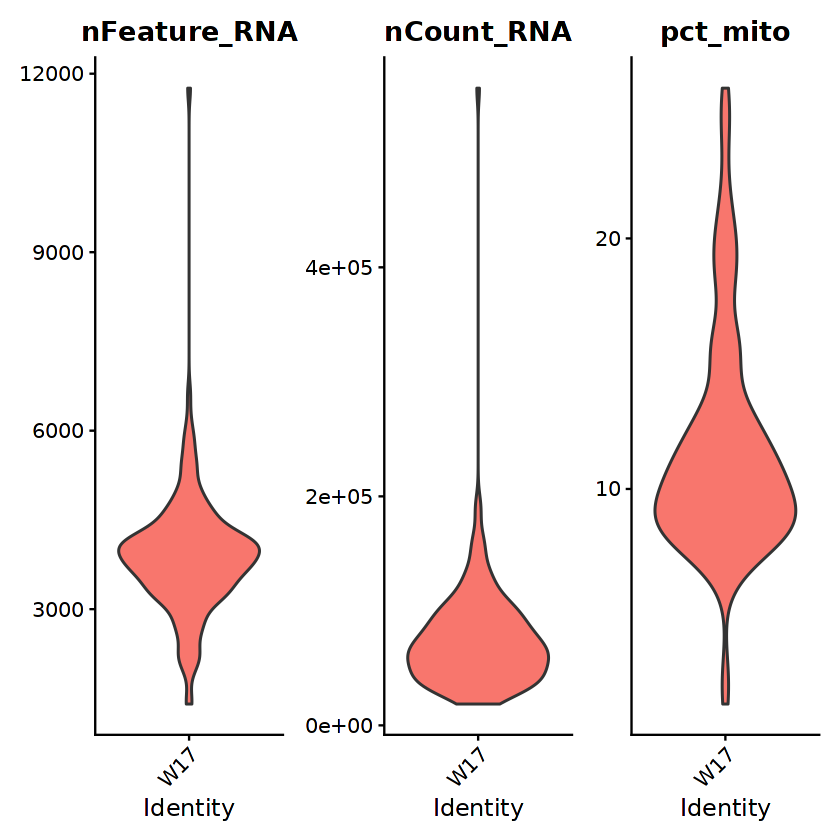

An object of class Seurat 
63217 features across 145 samples within 1 assay 
Active assay: RNA (63217 features, 0 variable features)
 1 layer present: counts

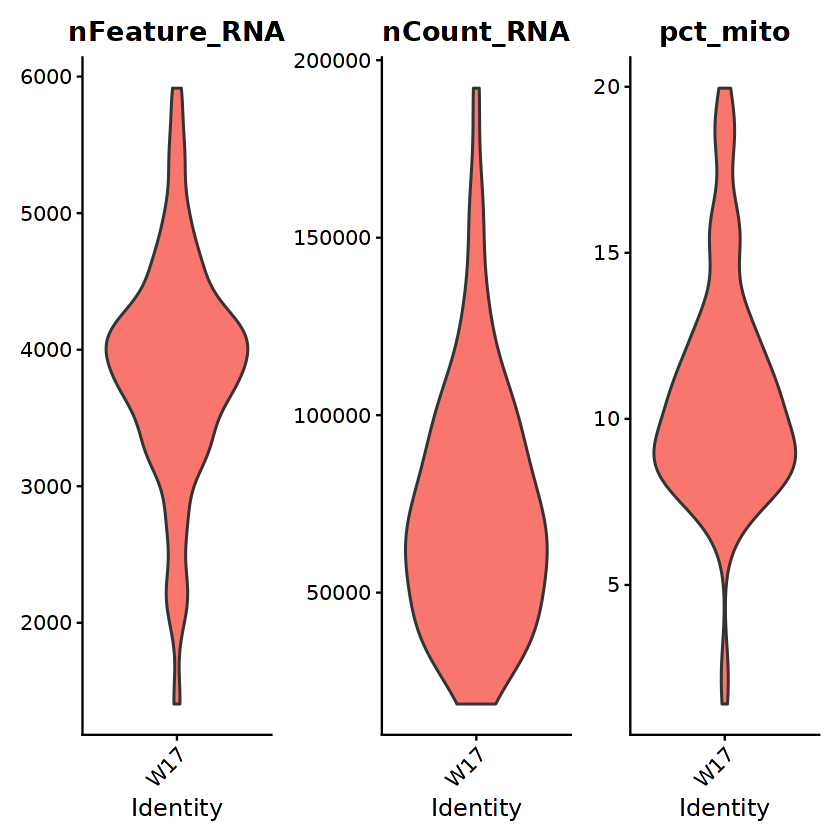

In [48]:
W17 <- subset(yu.mstr, idents = 'W17')

#Add metadata
W17 = RenameCells(W17, add.cell.id = 'W17')
W17$modality = 'expression' 
W17$dataset = 'yu_W17'
W17$pcw = '17'
W17$cellsource = 'fetal'
W17$gender = 'male'

#QC filtering
W17[['pct_mito']] = PercentageFeatureSet(W17, pattern = '^MT-')
VlnPlot(W17, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

W17 <- subset(W17, subset = nFeature_RNA > 200 & nFeature_RNA < 6000 & pct_mito < 20 & nCount_RNA > 3000)
VlnPlot(W17, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(W17)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
W17 = subset(W17, features = anti_mt_genes)

W17

#Save Checkpoint
saveRDS(W17, file='checkpoints/Fetal/RNA_datasets/yu_W17.rds')
rm(W17)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


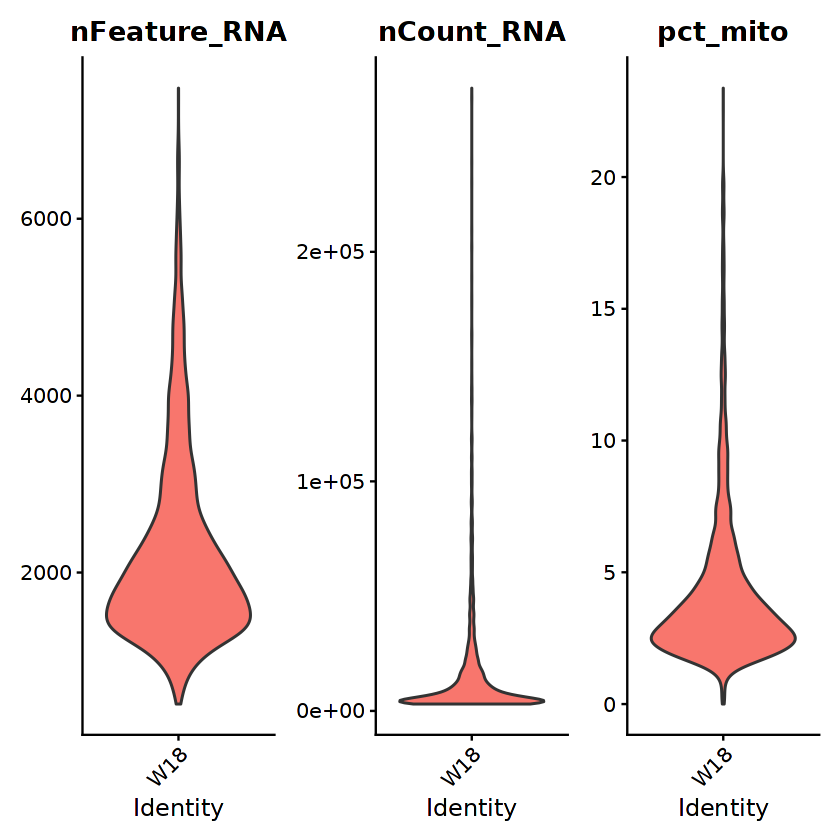

An object of class Seurat 
63373 features across 4449 samples within 1 assay 
Active assay: RNA (63373 features, 0 variable features)
 2 layers present: counts.1, counts.2

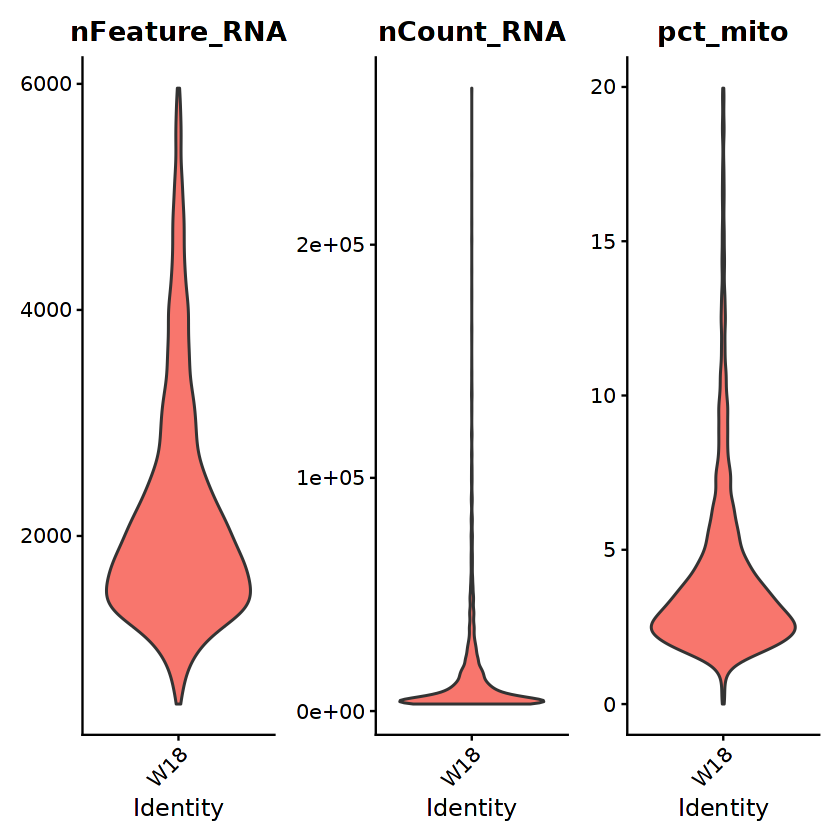

In [49]:
W18_10x <- subset(yu.10x, idents = 'W18')
W18_mstr <- subset(yu.mstr, idents = 'W18')

W18 <- merge(W18_10x, W18_mstr)

#Add metadata
W18 = RenameCells(W18, add.cell.id = 'W18')
W18$modality = 'expression' 
W18$dataset = 'yu_W18'
W18$pcw = '18'
W18$cellsource = 'fetal'
W18$gender = 'female'

#QC filtering
W18[['pct_mito']] = PercentageFeatureSet(W18, pattern = '^MT-')
VlnPlot(W18, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

W18 <- subset(W18, subset = nFeature_RNA > 200 & nFeature_RNA < 6000 & pct_mito < 20 & nCount_RNA > 3000)
VlnPlot(W18, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(W18)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
W18 = subset(W18, features = anti_mt_genes)

W18

#Save Checkpoint
W18[["RNA"]] <- JoinLayers(W18[["RNA"]])
saveRDS(W18, file='checkpoints/Fetal/RNA_datasets/yu_W18.rds')
rm(W18,W18_10x,W18_mstr)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


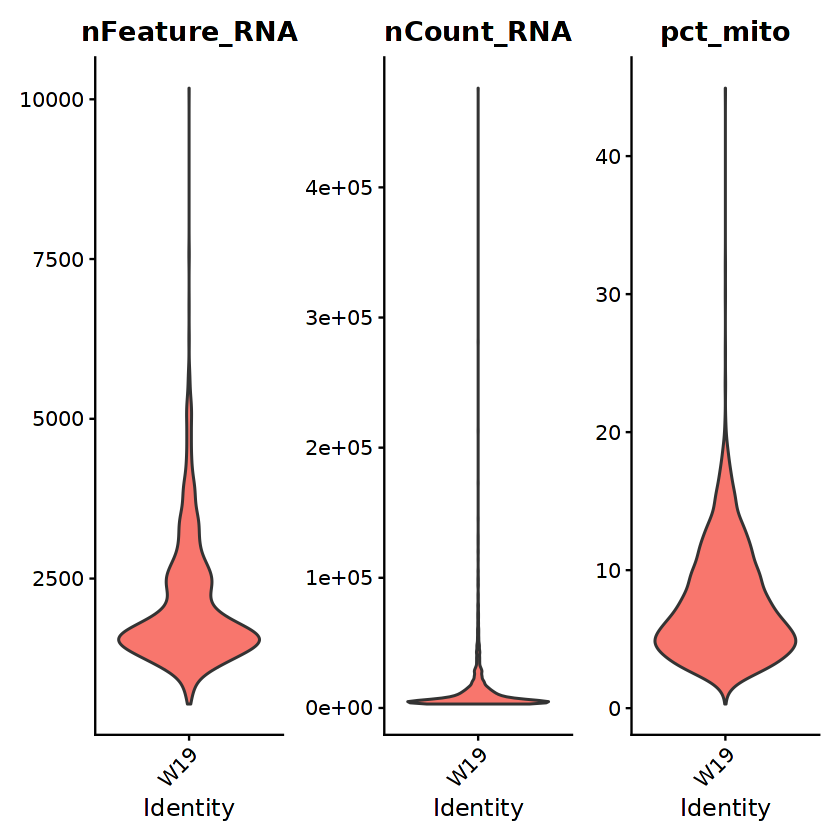

An object of class Seurat 
63373 features across 2364 samples within 1 assay 
Active assay: RNA (63373 features, 0 variable features)
 2 layers present: counts.1, counts.2

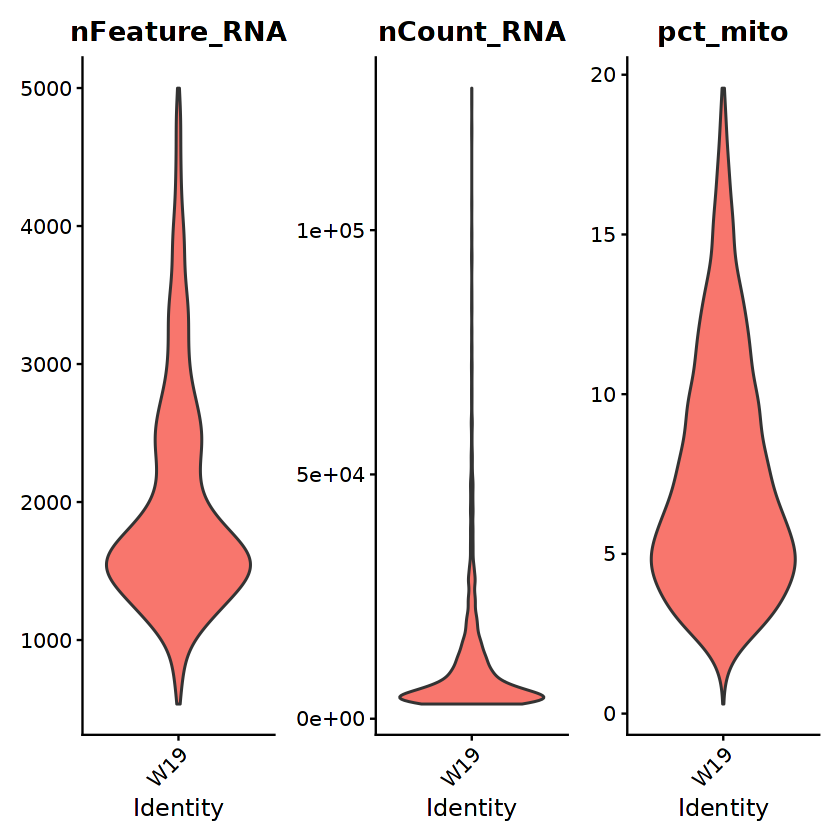

In [50]:
W19_10x <- subset(yu.10x, idents = 'W19')
W19_mstr <- subset(yu.mstr, idents = 'W19')

W19 <- merge(W19_10x, W19_mstr)

#Add metadata
W19 = RenameCells(W19, add.cell.id = 'W19')
W19$modality = 'expression' 
W19$dataset = 'yu_W19'
W19$pcw = '19'
W19$cellsource = 'fetal'
W19$gender = 'male'

#QC filtering
W19[['pct_mito']] = PercentageFeatureSet(W19, pattern = '^MT-')
VlnPlot(W19, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

W19 <- subset(W19, subset = nFeature_RNA > 200 & nFeature_RNA < 5000 & pct_mito < 20 & nCount_RNA > 3000)
VlnPlot(W19, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(W19)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
W19 = subset(W19, features = anti_mt_genes)

W19

#Save Checkpoint
W19[["RNA"]] <- JoinLayers(W19[["RNA"]])
saveRDS(W19, file='checkpoints/Fetal/RNA_datasets/yu_W19.rds')
rm(W19,W19_10x,W19_mstr)

## Migliorini et al

In [51]:
# official CellRanger human reference genome GRCh38 3.0.0, with INS-IGF2 removed from the human GTF file to unmask the INS transcripts.

In [52]:
cell.meta <- read.table(file = 'rawdata/RNA/fetal/Migliorini_fetal/meta.tsv', sep = '\t', row.names = 1, header = TRUE)

### Sample 1 - HFP35

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


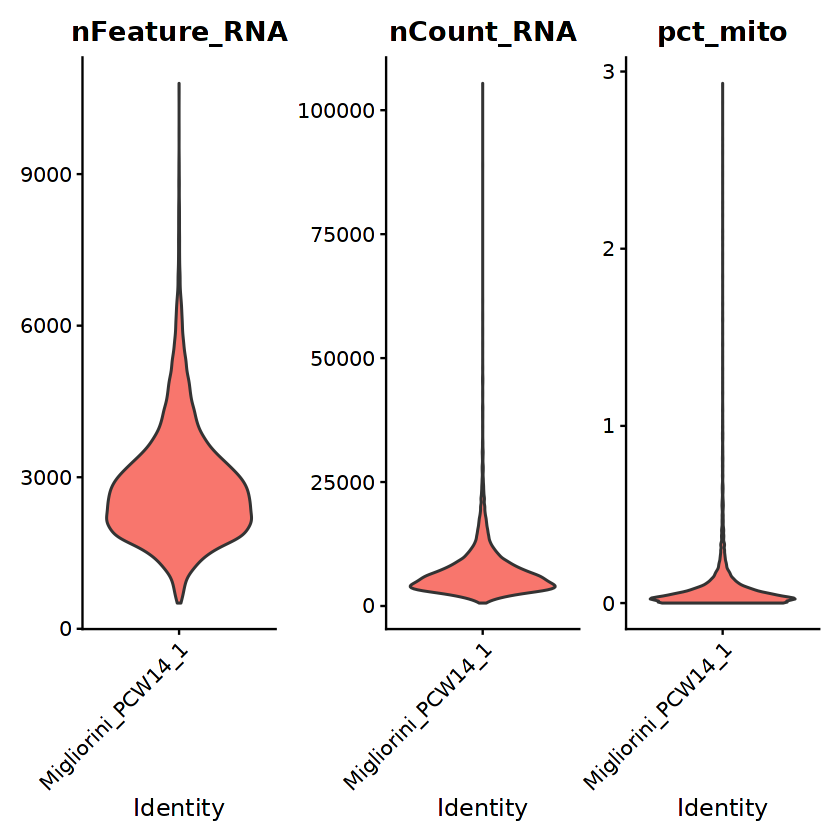

An object of class Seurat 
23925 features across 13493 samples within 1 assay 
Active assay: RNA (23925 features, 0 variable features)
 1 layer present: counts

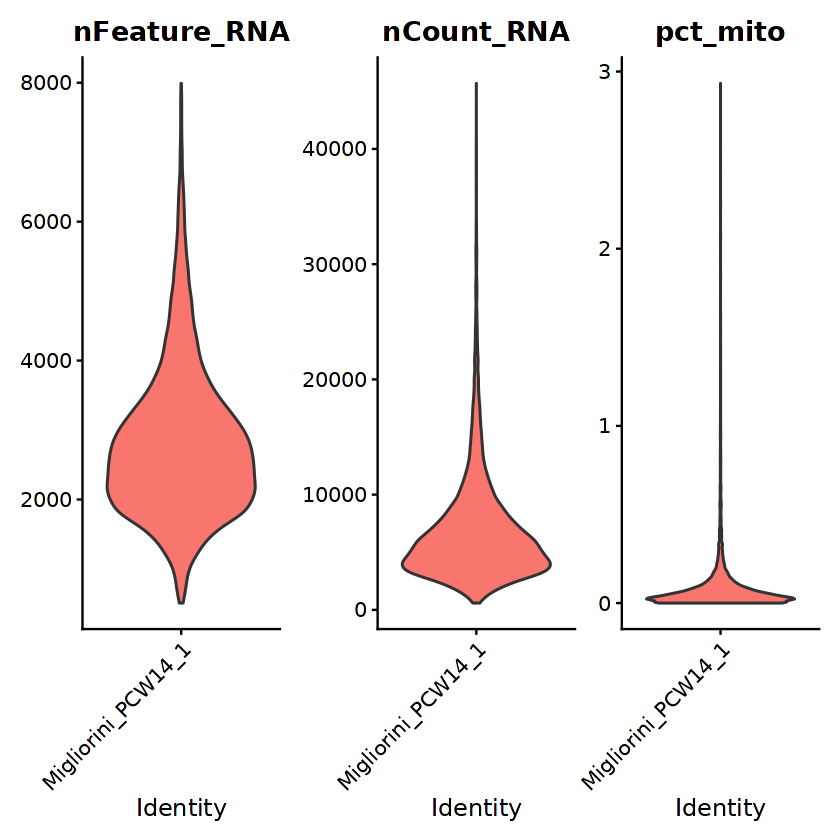

In [53]:
#Load raw counts
migliorini.s1.raw <- Read10X(data.dir = 'rawdata/RNA/fetal/Migliorini_fetal/Sample1_14PCW/')
s1.meta <- cell.meta[grep("HFP35", x=rownames(cell.meta)),]

#Create Seurat object
migliorini.s1 <- CreateSeuratObject(counts = migliorini.s1.raw, project = 'Migliorini_PCW14_1', assay = 'RNA', min.cells = 10, min.features = 500)
migliorini.s1 = RenameCells(migliorini.s1, add.cell.id = 'HFP35')
rm('migliorini.s1.raw')

#Add metadata
migliorini.s1[["CellName"]] <- colnames(migliorini.s1)
migliorini.s1 <- subset(migliorini.s1, subset = CellName %in% rownames(s1.meta))
migliorini.s1 <- AddMetaData(object = migliorini.s1, metadata = s1.meta)
rm('s1.meta')

migliorini.s1$CellName = NULL
migliorini.s1$modality = 'expression'
migliorini.s1$Sample <- paste("migliorini_", migliorini.s1$Sample, sep="")
migliorini.s1$dataset = migliorini.s1$Sample
migliorini.s1$Sample = NULL
migliorini.s1$pcw = as.character(migliorini.s1$PCW)
migliorini.s1$PCW = NULL
migliorini.s1$cellsource = 'fetal'
migliorini.s1$gender = migliorini.s1$Sex
migliorini.s1$Sex = NULL

#QC filtering
migliorini.s1[['pct_mito']] = PercentageFeatureSet(migliorini.s1, pattern = '^MT-')
VlnPlot(migliorini.s1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

migliorini.s1 <- subset(migliorini.s1, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(migliorini.s1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

migliorini.s1

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(migliorini.s1)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
migliorini.s1 = subset(migliorini.s1, features = anti_mt_genes)

#Save Checkpoint
saveRDS(migliorini.s1, file='checkpoints/Fetal/RNA_datasets/migliorini_s1.rds')
rm(migliorini.s1)

### Sample 2 - HFP29

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


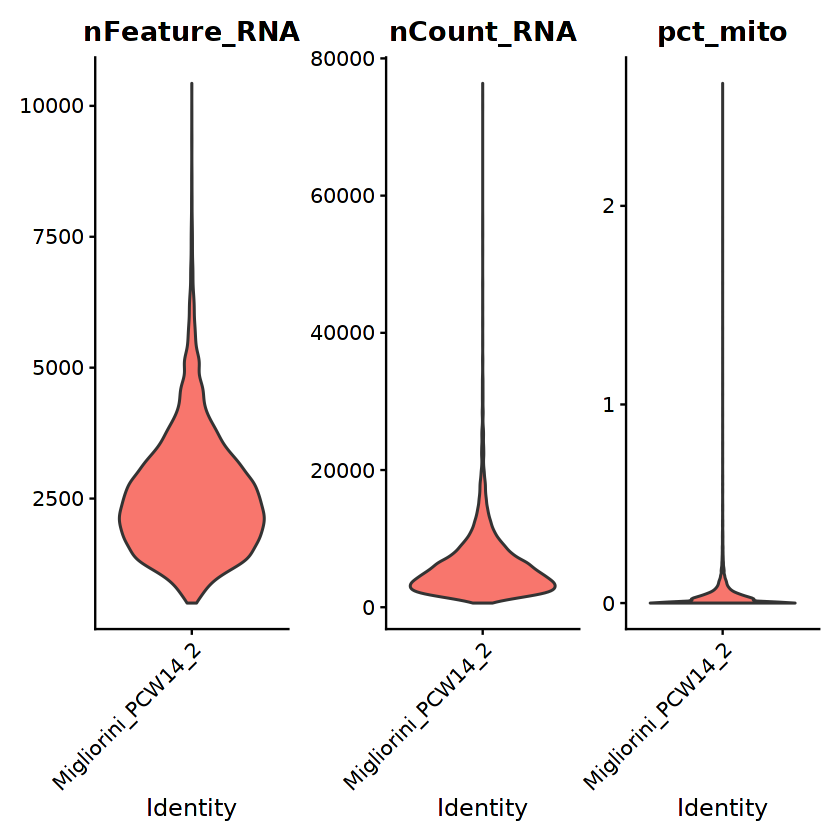

An object of class Seurat 
23387 features across 11769 samples within 1 assay 
Active assay: RNA (23387 features, 0 variable features)
 1 layer present: counts

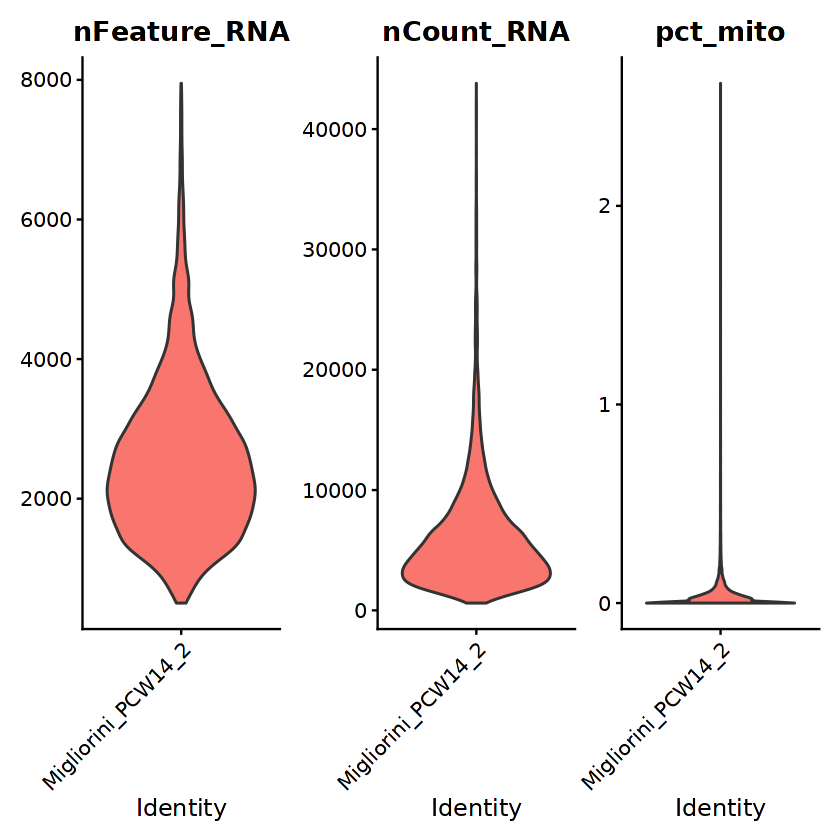

In [54]:
#Load raw counts
migliorini.s2.raw <- Read10X(data.dir = 'rawdata/RNA/fetal/Migliorini_fetal/Sample2_14PCW/')
s2.meta <- cell.meta[grep("HFP29", x=rownames(cell.meta)),]

#Create Seurat object
migliorini.s2 <- CreateSeuratObject(counts = migliorini.s2.raw, project = 'Migliorini_PCW14_2', assay = 'RNA', min.cells = 10, min.features = 500)
migliorini.s2 = RenameCells(migliorini.s2, add.cell.id = 'HFP29')
rm('migliorini.s2.raw')

#Add metadata
migliorini.s2[["CellName"]] <- colnames(migliorini.s2)
migliorini.s2 <- subset(migliorini.s2, subset = CellName %in% rownames(s2.meta))
migliorini.s2 <- AddMetaData(object = migliorini.s2, metadata = s2.meta)
rm('s2.meta')

migliorini.s2$CellName = NULL
migliorini.s2$modality = 'expression'
migliorini.s2$Sample <- paste("migliorini_", migliorini.s2$Sample, sep="")
migliorini.s2$dataset = migliorini.s2$Sample
migliorini.s2$Sample = NULL
migliorini.s2$pcw = as.character(migliorini.s2$PCW)
migliorini.s2$PCW = NULL
migliorini.s2$cellsource = 'fetal'
migliorini.s2$gender = migliorini.s2$Sex
migliorini.s2$Sex = NULL

#QC filtering
migliorini.s2[['pct_mito']] = PercentageFeatureSet(migliorini.s2, pattern = '^MT-')
VlnPlot(migliorini.s2, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

migliorini.s2 <- subset(migliorini.s2, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(migliorini.s2, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

migliorini.s2

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(migliorini.s2)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
migliorini.s2 = subset(migliorini.s2, features = anti_mt_genes)

#Save Checkpoint
saveRDS(migliorini.s2, file='checkpoints/Fetal/RNA_datasets/migliorini_s2.rds')
rm(migliorini.s2)

### Sample 3 - HFP22

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


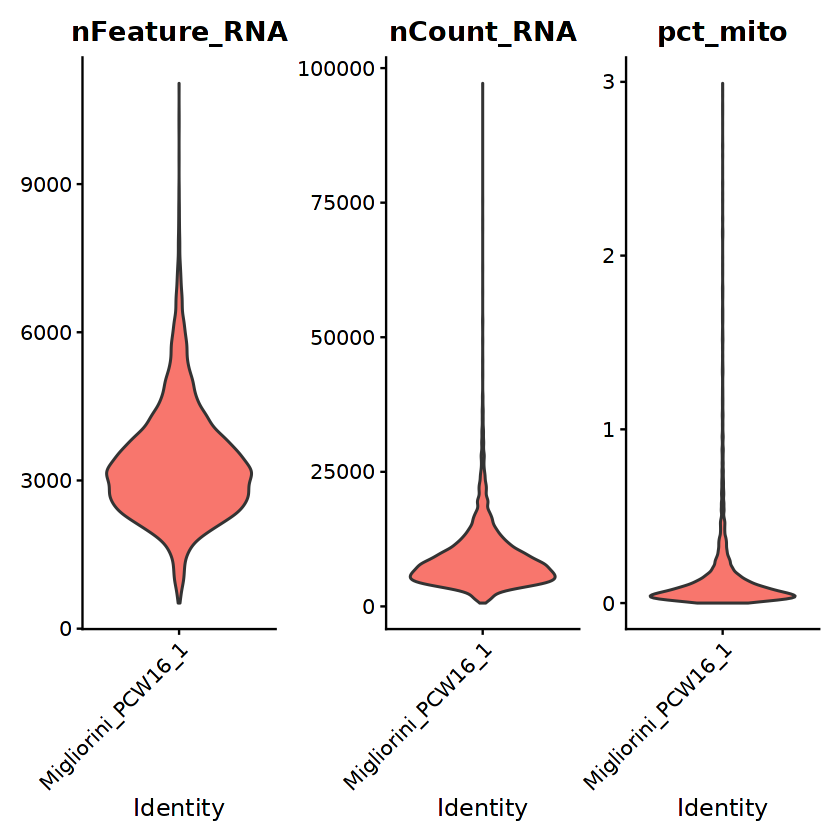

An object of class Seurat 
23964 features across 10220 samples within 1 assay 
Active assay: RNA (23964 features, 0 variable features)
 1 layer present: counts

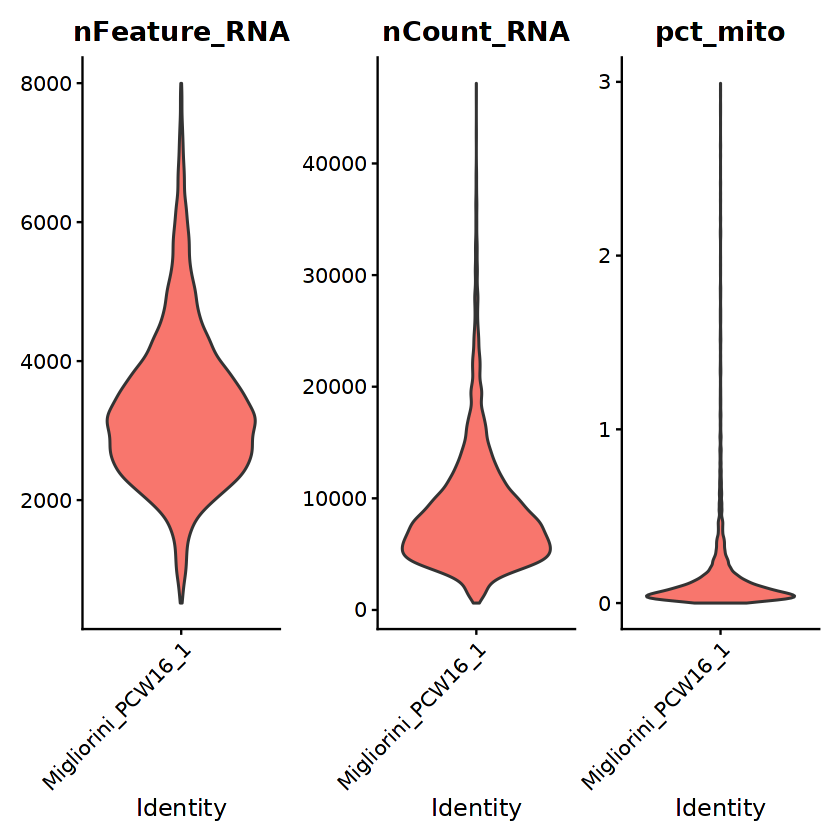

In [55]:
#Load raw counts
migliorini.s3.raw <- Read10X(data.dir = 'rawdata/RNA/fetal/Migliorini_fetal/Sample3_16PCW/')
s3.meta <- cell.meta[grep("HFP22", x=rownames(cell.meta)),]

#Create Seurat object
migliorini.s3 <- CreateSeuratObject(counts = migliorini.s3.raw, project = 'Migliorini_PCW16_1', assay = 'RNA', min.cells = 10, min.features = 500)
migliorini.s3 = RenameCells(migliorini.s3, add.cell.id = 'HFP22')
rm('migliorini.s3.raw')

#Add metadata
migliorini.s3[["CellName"]] <- colnames(migliorini.s3)
migliorini.s3 <- subset(migliorini.s3, subset = CellName %in% rownames(s3.meta))
migliorini.s3 <- AddMetaData(object = migliorini.s3, metadata = s3.meta)
rm('s3.meta')

migliorini.s3$CellName = NULL
migliorini.s3$modality = 'expression'
migliorini.s3$Sample <- paste("migliorini_", migliorini.s3$Sample, sep="")
migliorini.s3$dataset = migliorini.s3$Sample
migliorini.s3$Sample = NULL
migliorini.s3$pcw = as.character(migliorini.s3$PCW)
migliorini.s3$PCW = NULL
migliorini.s3$cellsource = 'fetal'
migliorini.s3$gender = migliorini.s3$Sex
migliorini.s3$Sex = NULL

#QC filtering
migliorini.s3[['pct_mito']] = PercentageFeatureSet(migliorini.s3, pattern = '^MT-')
VlnPlot(migliorini.s3, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

migliorini.s3 <- subset(migliorini.s3, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(migliorini.s3, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

migliorini.s3

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(migliorini.s3)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
migliorini.s3 = subset(migliorini.s3, features = anti_mt_genes)

#Save Checkpoint
saveRDS(migliorini.s3, file='checkpoints/Fetal/RNA_datasets/migliorini_s3.rds')
rm(migliorini.s3)

### Sample 4 - HFP19

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


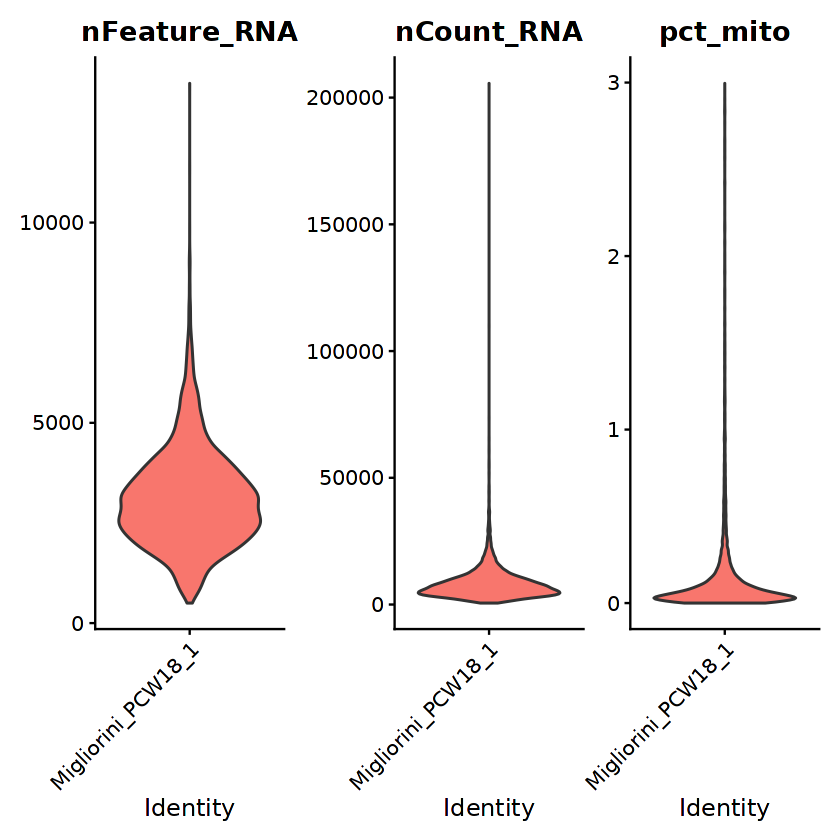

An object of class Seurat 
24577 features across 12966 samples within 1 assay 
Active assay: RNA (24577 features, 0 variable features)
 1 layer present: counts

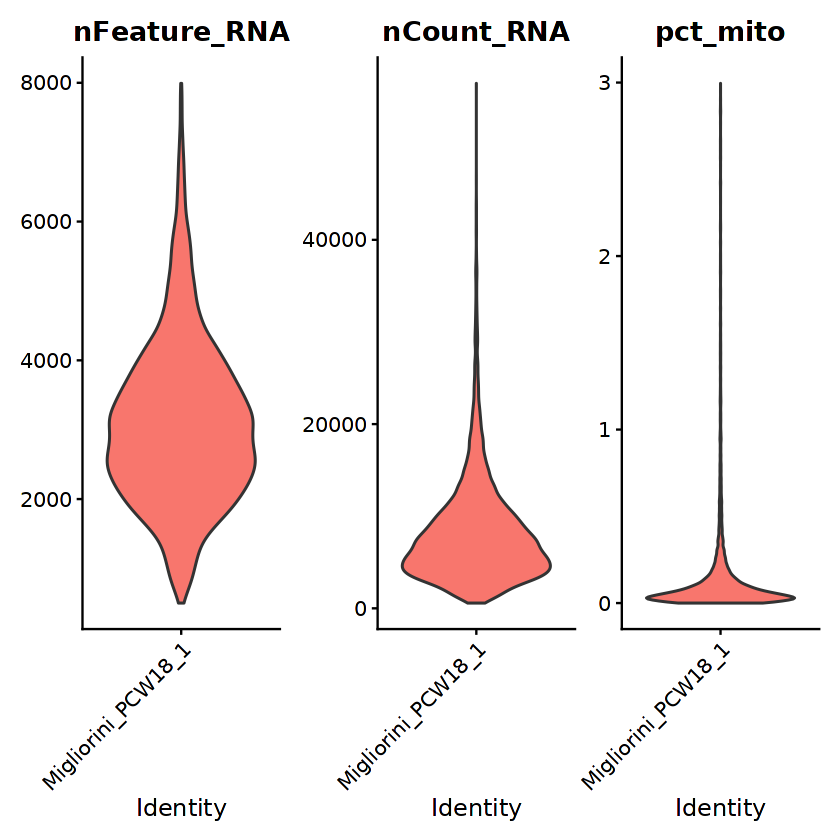

In [56]:
#Load raw counts
migliorini.s4.raw <- Read10X(data.dir = 'rawdata/RNA/fetal/Migliorini_fetal/Sample4_16PCW/')
s4.meta <- cell.meta[grep("HFP19", x=rownames(cell.meta)),]

#Create Seurat object
migliorini.s4 <- CreateSeuratObject(counts = migliorini.s4.raw, project = 'Migliorini_PCW18_1', assay = 'RNA', min.cells = 10, min.features = 500)
migliorini.s4 = RenameCells(migliorini.s4, add.cell.id = 'HFP19')
rm('migliorini.s4.raw')

#Add metadata
migliorini.s4[["CellName"]] <- colnames(migliorini.s4)
migliorini.s4 <- subset(migliorini.s4, subset = CellName %in% rownames(s4.meta))
migliorini.s4 <- AddMetaData(object = migliorini.s4, metadata = s4.meta)
rm('s4.meta')

migliorini.s4$CellName = NULL
migliorini.s4$modality = 'expression'
migliorini.s4$Sample <- paste("migliorini_", migliorini.s4$Sample, sep="")
migliorini.s4$dataset = migliorini.s4$Sample
migliorini.s4$Sample = NULL
migliorini.s4$pcw = as.character(migliorini.s4$PCW)
migliorini.s4$PCW = NULL
migliorini.s4$cellsource = 'fetal'
migliorini.s4$gender = migliorini.s4$Sex
migliorini.s4$Sex = NULL

#QC filtering
migliorini.s4[['pct_mito']] = PercentageFeatureSet(migliorini.s4, pattern = '^MT-')
VlnPlot(migliorini.s4, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

migliorini.s4 <- subset(migliorini.s4, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(migliorini.s4, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

migliorini.s4

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(migliorini.s4)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
migliorini.s4 = subset(migliorini.s4, features = anti_mt_genes)

#Save Checkpoint
saveRDS(migliorini.s4, file='checkpoints/Fetal/RNA_datasets/migliorini_s4.rds')
rm(migliorini.s4)

### Sample 5 - HFP31

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


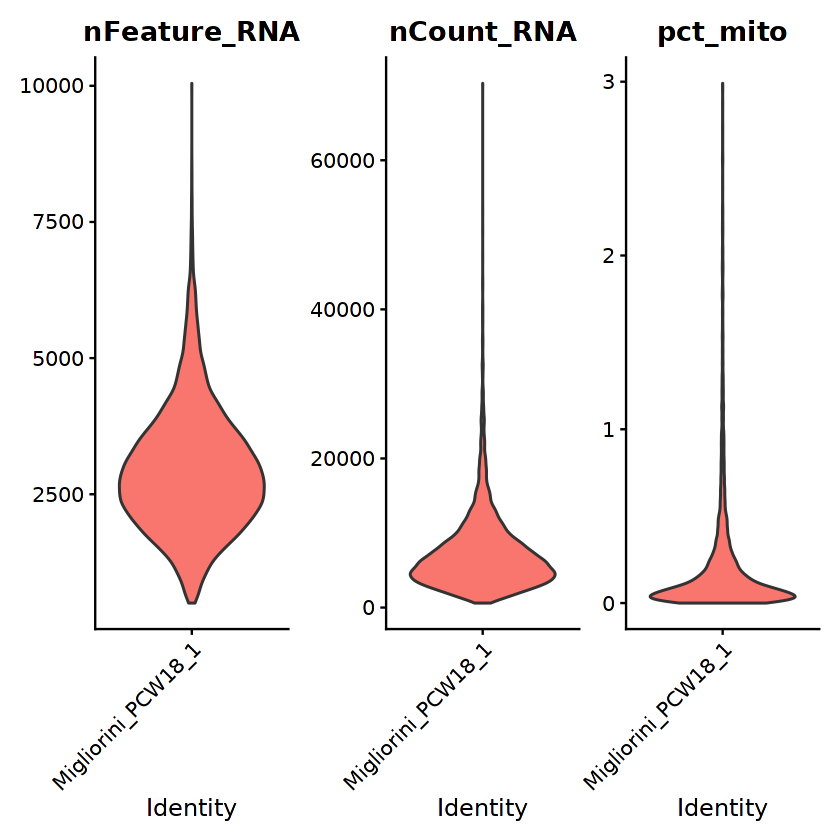

An object of class Seurat 
23714 features across 11459 samples within 1 assay 
Active assay: RNA (23714 features, 0 variable features)
 1 layer present: counts

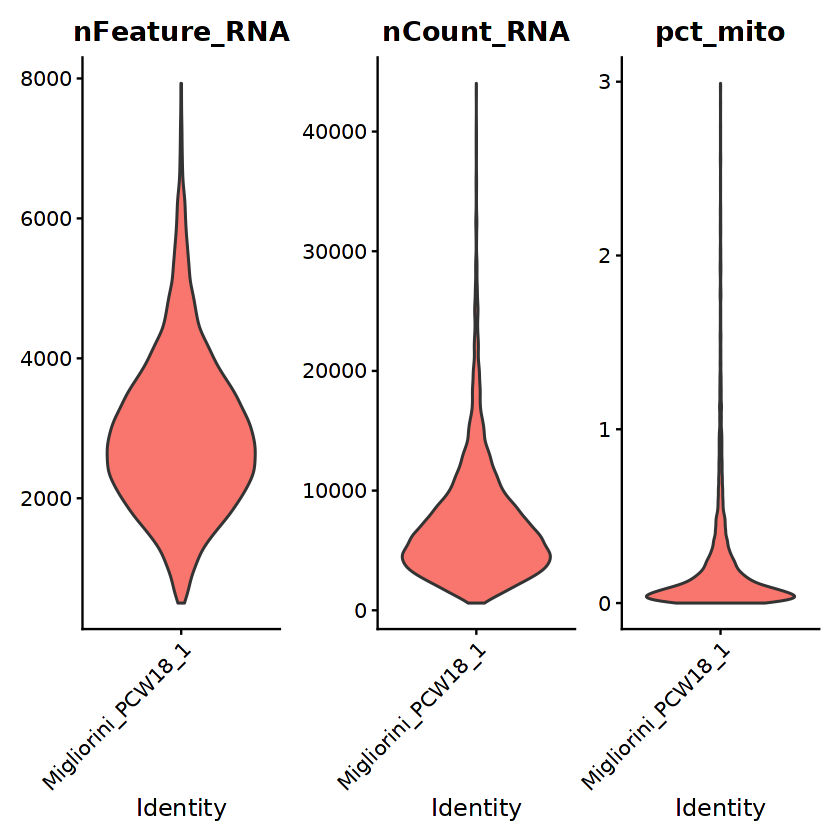

In [57]:
#Load raw counts
migliorini.s5.raw <- Read10X(data.dir = 'rawdata/RNA/fetal/Migliorini_fetal/Sample5_18PCW/')
s5.meta <- cell.meta[grep("HFP31", x=rownames(cell.meta)),]

#Create Seurat object
migliorini.s5 <- CreateSeuratObject(counts = migliorini.s5.raw, project = 'Migliorini_PCW18_1', assay = 'RNA', min.cells = 10, min.features = 500)
migliorini.s5 = RenameCells(migliorini.s5, add.cell.id = 'HFP31')
rm('migliorini.s5.raw')

#Add metadata
migliorini.s5[["CellName"]] <- colnames(migliorini.s5)
migliorini.s5 <- subset(migliorini.s5, subset = CellName %in% rownames(s5.meta))
migliorini.s5 <- AddMetaData(object = migliorini.s5, metadata = s5.meta)
rm('s5.meta')

migliorini.s5$CellName = NULL
migliorini.s5$modality = 'expression'
migliorini.s5$Sample <- paste("migliorini_", migliorini.s5$Sample, sep="")
migliorini.s5$dataset = migliorini.s5$Sample
migliorini.s5$Sample = NULL
migliorini.s5$pcw = as.character(migliorini.s5$PCW)
migliorini.s5$PCW = NULL
migliorini.s5$cellsource = 'fetal'
migliorini.s5$gender = migliorini.s5$Sex
migliorini.s5$Sex = NULL

#QC filtering
migliorini.s5[['pct_mito']] = PercentageFeatureSet(migliorini.s5, pattern = '^MT-')
VlnPlot(migliorini.s5, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

migliorini.s5 <- subset(migliorini.s5, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(migliorini.s5, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(migliorini.s5)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
migliorini.s5 = subset(migliorini.s5, features = anti_mt_genes)

migliorini.s5

#Save Checkpoint
saveRDS(migliorini.s5, file='checkpoints/Fetal/RNA_datasets/migliorini_s5.rds')
rm(migliorini.s5)

### Sample 6 - HFP32

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


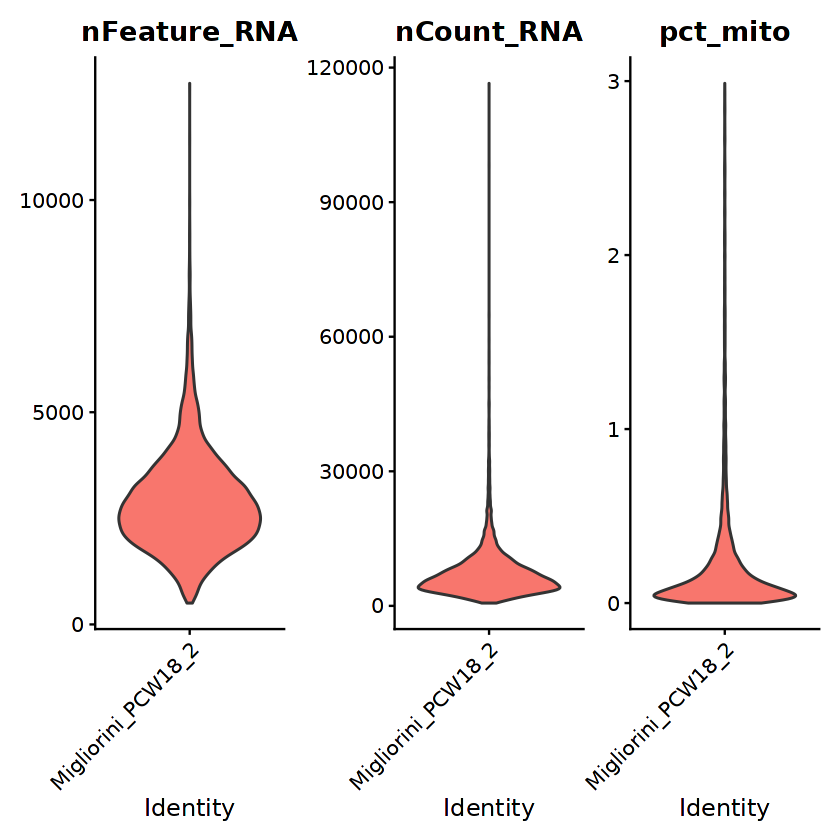

An object of class Seurat 
24230 features across 13073 samples within 1 assay 
Active assay: RNA (24230 features, 0 variable features)
 1 layer present: counts

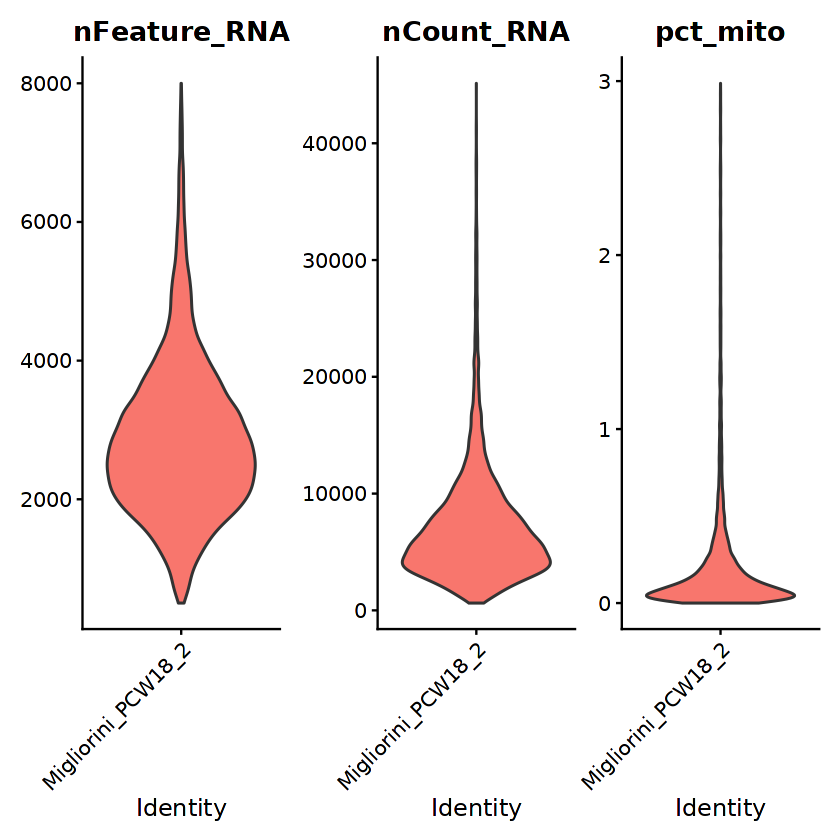

In [58]:
#Load raw counts
migliorini.s6.raw <- Read10X(data.dir = 'rawdata/RNA/fetal/Migliorini_fetal/Sample6_18PCW/')
s6.meta <- cell.meta[grep("HFP32", x=rownames(cell.meta)),]

#Create Seurat object
migliorini.s6 <- CreateSeuratObject(counts = migliorini.s6.raw, project = 'Migliorini_PCW18_2', assay = 'RNA', min.cells = 10, min.features = 500)
migliorini.s6 = RenameCells(migliorini.s6, add.cell.id = 'HFP32')
rm('migliorini.s6.raw')

#Add metadata
migliorini.s6[["CellName"]] <- colnames(migliorini.s6)
migliorini.s6 <- subset(migliorini.s6, subset = CellName %in% rownames(s6.meta))
migliorini.s6 <- AddMetaData(object = migliorini.s6, metadata = s6.meta)
rm('s6.meta')

migliorini.s6$CellName = NULL
migliorini.s6$modality = 'expression'
migliorini.s6$Sample <- paste("migliorini_", migliorini.s6$Sample, sep="")
migliorini.s6$dataset = migliorini.s6$Sample
migliorini.s6$Sample = NULL
migliorini.s6$pcw = as.character(migliorini.s6$PCW)
migliorini.s6$PCW = NULL
migliorini.s6$cellsource = 'fetal'
migliorini.s6$gender = migliorini.s6$Sex
migliorini.s6$Sex = NULL

#QC filtering
migliorini.s6[['pct_mito']] = PercentageFeatureSet(migliorini.s6, pattern = '^MT-')
VlnPlot(migliorini.s6, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

migliorini.s6 <- subset(migliorini.s6, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(migliorini.s6, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

migliorini.s6

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(migliorini.s6)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
migliorini.s6 = subset(migliorini.s6, features = anti_mt_genes)

#Save Checkpoint
saveRDS(migliorini.s6, file='checkpoints/Fetal/RNA_datasets/migliorini_s6.rds')
rm(migliorini.s6)

In [59]:
rm(cell.meta)

## Goncalves et al

In [60]:
# Load RNA Data
exprmat <- read.table(file = 'rawdata/RNA/fetal/Goncalves_fetal/exprMatrix.tsv', sep = '\t', header = TRUE)
exprmat[exprmat<0]<-0
meta <- read.table("rawdata/RNA/fetal/Goncalves_fetal/meta.tsv", header=T, sep="\t", as.is=T, row.names=1)

# Convert ensembl gene id to hgnc symbols
ensembl <- useMart("ensembl", dataset = "hsapiens_gene_ensembl")
ensembl_ids <- exprmat$gene

gene_info <- getBM(
  attributes = c("ensembl_gene_id", "hgnc_symbol"),
  filters = "ensembl_gene_id",
  values = ensembl_ids,
  mart = ensembl
)

colnames(exprmat)[colnames(exprmat) == 'gene'] <- 'ensembl_gene_id'
exprmat <- merge(exprmat, gene_info, by = "ensembl_gene_id")

exprmat$hgnc_symbol <- make.unique(exprmat$hgnc_symbol)
exprmat = data.frame(exprmat[,-1], row.names=exprmat$hgnc_symbol)
exprmat$hgnc_symbol <- NULL  # Remove the redundant column

empty_rows <- rownames(exprmat) == ""
cleaned_data <- exprmat[!empty_rows, ]

#Create Seurat object
goncalves.rna <- CreateSeuratObject(counts = cleaned_data, project = "Goncalves.rna", meta.data = meta, min.cells = 10, min.features = 200)
Idents(goncalves.rna) <- 'age'

#Save
saveRDS(goncalves.rna, file='checkpoints/Fetal/RNA_datasets/Goncalves_RNA.rds')
rm(exprmat,meta,ensembl,ensembl_ids,gene_info,empty_rows,cleaned_data)

Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


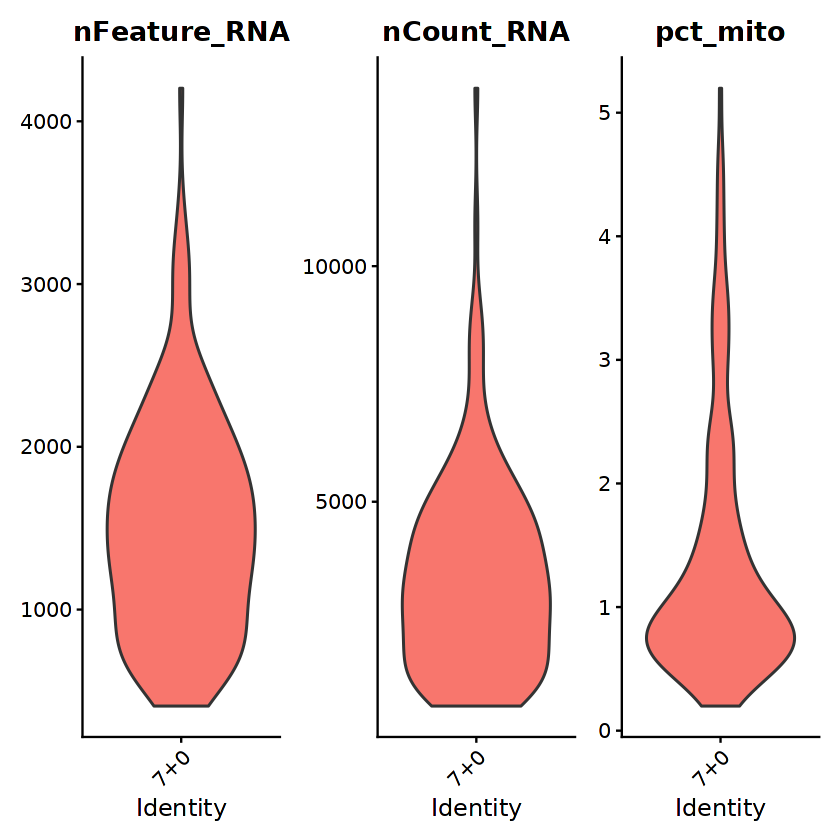

An object of class Seurat 
21041 features across 154 samples within 1 assay 
Active assay: RNA (21041 features, 0 variable features)
 1 layer present: counts

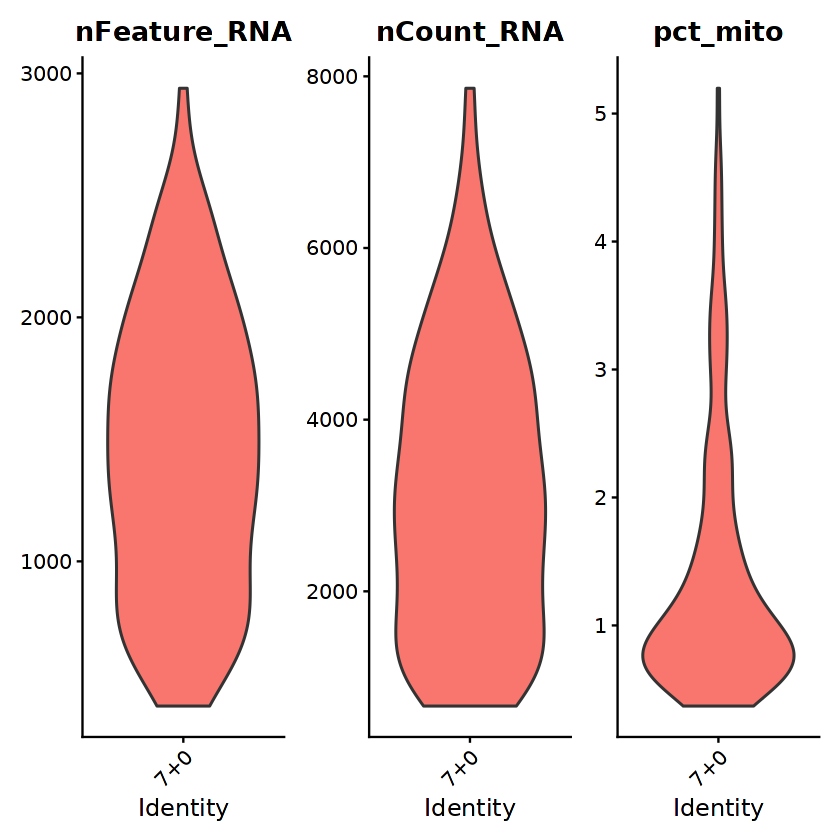

In [61]:
pcw7_0 <- subset(goncalves.rna, idents = '7+0')

#Add metadata
pcw7_0 = RenameCells(pcw7_0, add.cell.id = 'pcw70')
pcw7_0$modality = 'expression' 
pcw7_0$dataset = 'goncalves_7+0'
pcw7_0$pcw = '7'
pcw7_0$cellsource = 'fetal'
pcw7_0$gender = 'und'

#QC filtering
pcw7_0[['pct_mito']] = PercentageFeatureSet(pcw7_0, pattern = '^MT-')
VlnPlot(pcw7_0, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

pcw7_0 <- subset(pcw7_0, subset = nFeature_RNA > 200 & nFeature_RNA < 3000 & pct_mito < 20)
VlnPlot(pcw7_0, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(pcw7_0)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
pcw7_0 = subset(pcw7_0, features = anti_mt_genes)

pcw7_0

#Save Checkpoint
saveRDS(pcw7_0, file='checkpoints/Fetal/RNA_datasets/goncalves_pcw70.rds')
rm(pcw7_0)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


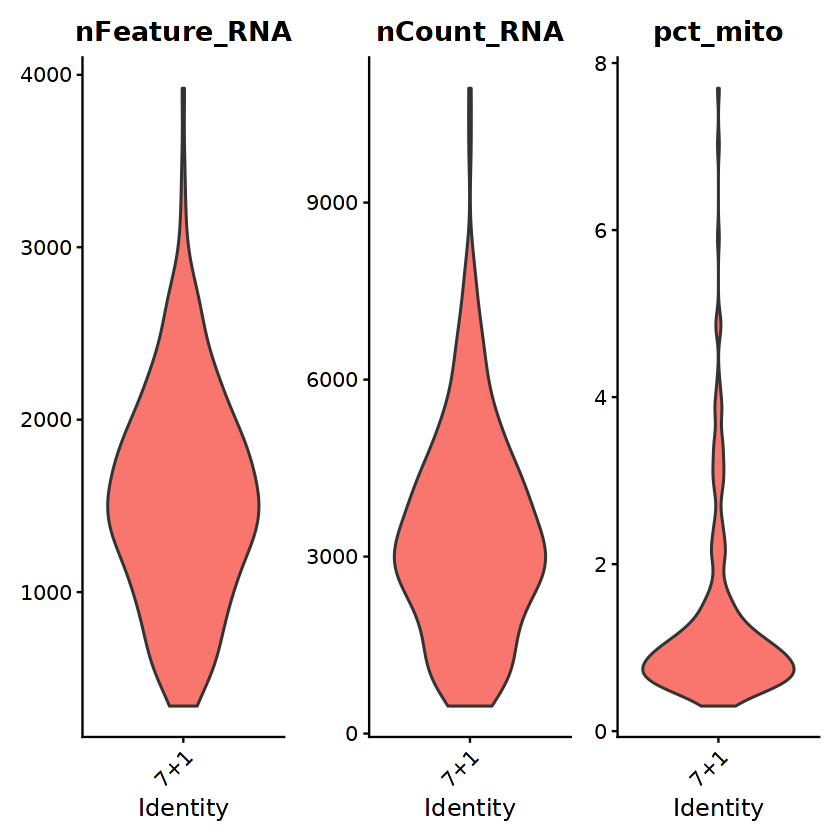

An object of class Seurat 
21041 features across 231 samples within 1 assay 
Active assay: RNA (21041 features, 0 variable features)
 1 layer present: counts

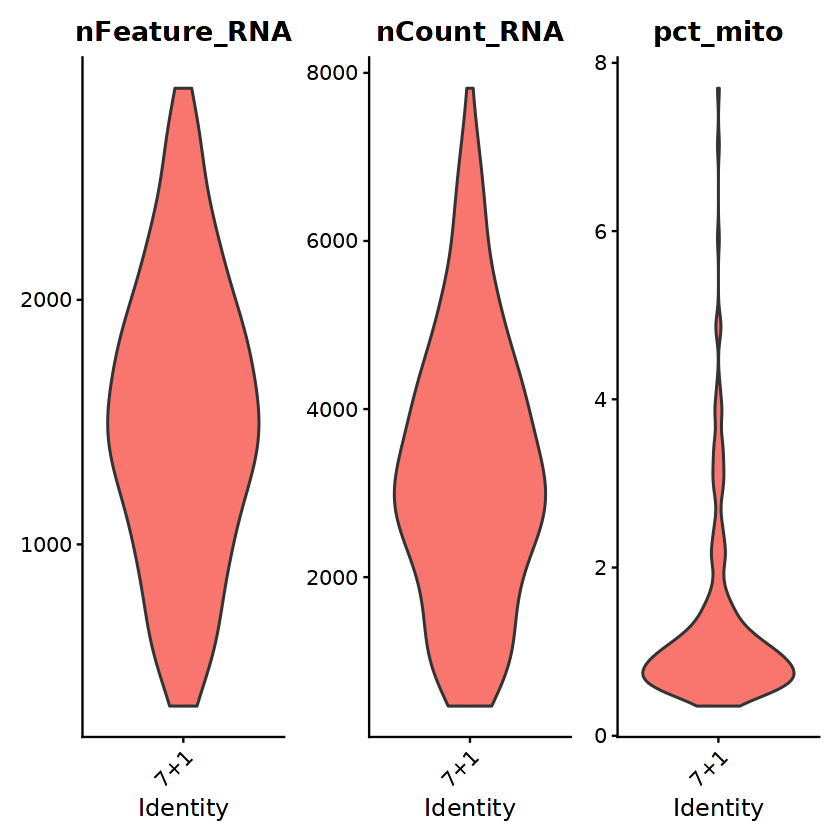

In [62]:
pcw7_1 <- subset(goncalves.rna, idents = '7+1')

#Add metadata
pcw7_1 = RenameCells(pcw7_1, add.cell.id = 'pcw71')
pcw7_1$modality = 'expression' 
pcw7_1$dataset = 'goncalves_7+1'
pcw7_1$pcw = '7'
pcw7_1$cellsource = 'fetal'
pcw7_1$gender = 'und'

#QC filtering
pcw7_1[['pct_mito']] = PercentageFeatureSet(pcw7_1, pattern = '^MT-')
VlnPlot(pcw7_1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

pcw7_1 <- subset(pcw7_1, subset = nFeature_RNA > 200 & nFeature_RNA < 3000 & pct_mito < 20)
VlnPlot(pcw7_1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(pcw7_1)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
pcw7_1 = subset(pcw7_1, features = anti_mt_genes)

pcw7_1

#Save Checkpoint
saveRDS(pcw7_1, file='checkpoints/Fetal/RNA_datasets/goncalves_pcw71.rds')
rm(pcw7_1)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


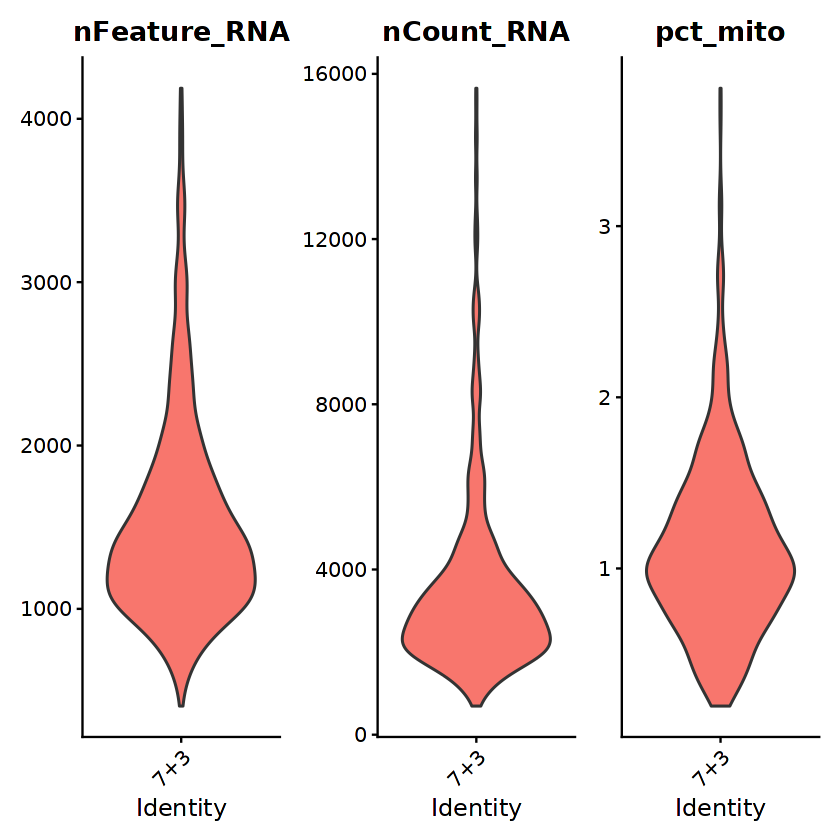

An object of class Seurat 
21041 features across 625 samples within 1 assay 
Active assay: RNA (21041 features, 0 variable features)
 1 layer present: counts

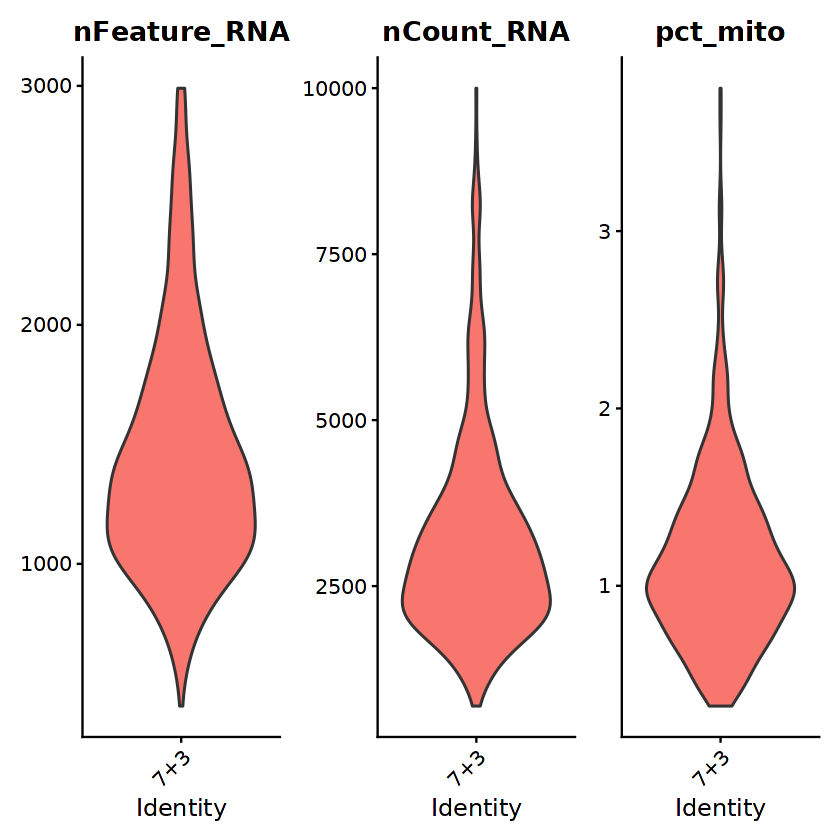

In [63]:
pcw7_3 <- subset(goncalves.rna, idents = '7+3')

#Add metadata
pcw7_3 = RenameCells(pcw7_3, add.cell.id = 'pcw73')
pcw7_3$modality = 'expression' 
pcw7_3$dataset = 'goncalves_7+3'
pcw7_3$pcw = '7'
pcw7_3$cellsource = 'fetal'
pcw7_3$gender = 'und'

#QC filtering
pcw7_3[['pct_mito']] = PercentageFeatureSet(pcw7_3, pattern = '^MT-')
VlnPlot(pcw7_3, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

pcw7_3 <- subset(pcw7_3, subset = nFeature_RNA > 200 & nFeature_RNA < 3000 & pct_mito < 20)
VlnPlot(pcw7_3, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(pcw7_3)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
pcw7_3 = subset(pcw7_3, features = anti_mt_genes)

pcw7_3

#Save Checkpoint
saveRDS(pcw7_3, file='checkpoints/Fetal/RNA_datasets/goncalves_pcw73.rds')
rm(pcw7_3)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


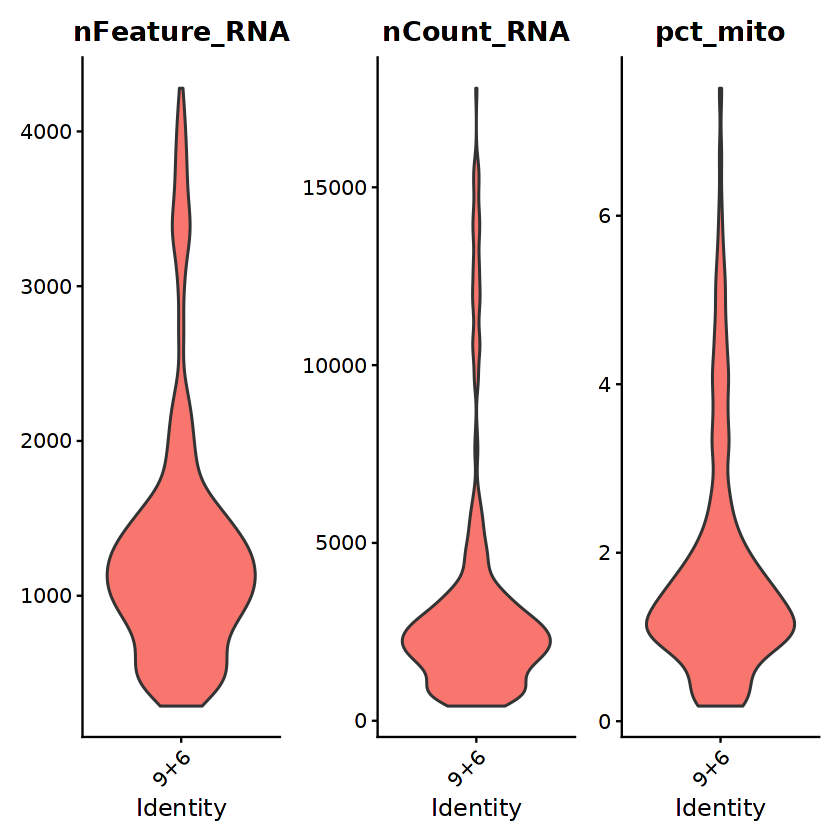

An object of class Seurat 
21041 features across 386 samples within 1 assay 
Active assay: RNA (21041 features, 0 variable features)
 1 layer present: counts

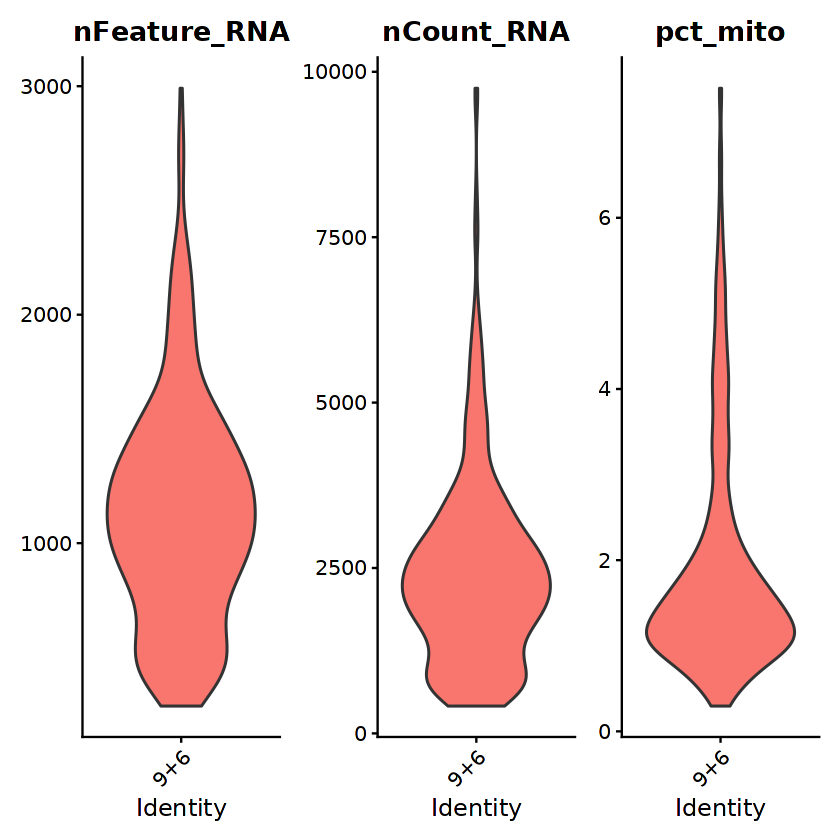

In [64]:
pcw9_6 <- subset(goncalves.rna, idents = '9+6')

#Add metadata
pcw9_6 = RenameCells(pcw9_6, add.cell.id = 'pcw96')
pcw9_6$modality = 'expression' 
pcw9_6$dataset = 'goncalves_9+6'
pcw9_6$pcw = '9'
pcw9_6$cellsource = 'fetal'
pcw9_6$gender = 'und'

#QC filtering
pcw9_6[['pct_mito']] = PercentageFeatureSet(pcw9_6, pattern = '^MT-')
VlnPlot(pcw9_6, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

pcw9_6 <- subset(pcw9_6, subset = nFeature_RNA > 200 & nFeature_RNA < 3000 & pct_mito < 20)
VlnPlot(pcw9_6, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(pcw9_6)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
pcw9_6 = subset(pcw9_6, features = anti_mt_genes)

pcw9_6

#Save Checkpoint
saveRDS(pcw9_6, file='checkpoints/Fetal/RNA_datasets/goncalves_pcw96.rds')
rm(pcw9_6)

# Merge Data

## Reload Datasets

In [65]:
data.list <- list()
meta <- data.frame()

files <- list.files(path = 'checkpoints/Fetal/RNA_datasets/', pattern="*.rds", full.names=FALSE)

for (i in seq_along(files)) {
    data <- readRDS(file = paste('checkpoints/Fetal/RNA_datasets/', files[i], sep=""))  
    data.list <- append(data.list,data)
    
    meta<- bind_rows(meta,data.list[[i]][[]])
}

counts.list <- lapply(X = data.list, FUN = function(x) {
    x <- na.omit(x[["RNA"]]$counts)
})

obj <- CreateSeuratObject(counts = counts.list, names.field = 1, names.delim = "_", meta.data = meta, min.cells = 10, min.features = 200)
rm(list = c('data.list','data','counts.list','meta'))

## Preprocess

In [66]:
obj <- JoinLayers(obj)
obj[["RNA"]] <- split(obj[["RNA"]], f = obj$dataset)

In [67]:
suppressWarnings({
obj <- NormalizeData(obj, verbose = FALSE)
obj <- FindVariableFeatures(obj, verbose = FALSE)
obj <- ScaleData(obj, verbose = FALSE)
obj <- RunPCA(obj, verbose = FALSE)
obj <- RunUMAP(obj, reduction = "pca", dims = 1:30, reduction.name = "umap.merged.rna")
})

21:25:44 UMAP embedding parameters a = 0.9922 b = 1.112

21:25:44 Read 258731 rows and found 30 numeric columns

21:25:44 Using Annoy for neighbor search, n_neighbors = 30

21:25:44 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

21:26:24 Writing NN index file to temp file /tmp/410464.tmpdir/Rtmp4KbweO/file604f44006f

21:26:24 Searching Annoy index using 1 thread, search_k = 3000

21:28:15 Annoy recall = 100%

21:28:17 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

21:28:26 Initializing from normalized Laplacian + noise (using RSpectra)

21:29:25 Commencing optimization for 200 epochs, with 11580078 positive edges

21:29:25 Using rng type: pcg

21:31:38 Optimization finished



## Save Merged Data

In [68]:
saveRDS(obj, file="checkpoints/Fetal/FetalIsletAtlas_RNAmerged.rds")

In [69]:
sessionInfo()

R version 4.5.1 (2025-06-13)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/atlas/libblas.so.3.10.3 
LAPACK: /usr/lib/x86_64-linux-gnu/atlas/liblapack.so.3.10.3;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] future_1.68.0        Matrix_1.7-4         patchwork_1.3.2     
 [4] ggplot2_4.0.1        dplyr_1.1.4          data.table_1.18.0   
 [7] biomaRt_2.64.0       glmGamPoi_1.20.0     SeuratWrappers_0.4.0
[10] Seurat_5.4.0.9000    SeuratObject_5.0.2   sp_2.2-